# Reproducing AGNfitter-rX's physics with tengri

AGNfitter-rX (Martínez-Ramírez et al. 2024, A&A 688, A46) models the
radio-to-X-ray SEDs of active galaxies. Where CIGALE and Prospector are
galaxy-centric, AGNfitter-rX is built to characterize the AGN itself — its
accretion disk, hot dusty torus, relativistic jet / core radio, and hot
corona, alongside the host (stellar populations, cold dust, star-formation
radio). Radio and X-ray data, largely unaffected by dust, are orthogonal
tracers that break the infrared–ultraviolet degeneracies that limited the
original submm-to-UV AGNfitter.

This notebook configures tengri's public API — exclusively `SEDModel.build`'s
dict grammar, `model.predict(params)`, and the documented `tengri.agn` /
`tengri.xray` / `tengri.radio` / `tengri.dust` namespaces — to approximate
AGNfitter-rX's model choices. tengri implements the same physics
independently; residual differences are quantified in place, next to the
figure or printed number that shows them.

The headline comparisons are the two model *face-offs* that drive the
paper's conclusions: **§9a** — accretion-disk libraries R06, SN12, KD18,
THB21 (plus tengri's KD18 grid-tabulated and warm-index variants). THB21
wins (Bayes factor ≈10⁵·¹ over R06) because it alone carries the broad and
narrow emission lines producing the ≈0.7 μm Hα + [N II] peak the theory
discs miss. **§9c** — torus libraries S04, NK08, SKIRTOR, CAT3D-Wind, and
five further averaged reductions of the same families. CAT3D-Wind wins
(maximum likelihood 25/36 sources) because its polar-wind dust addresses
the 1.5–5 μm near-IR excess pure equatorial tori cannot.

## Setup

In [1]:
import os

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from reproduction.agnfitter._drivers import agnfitter_driver as A, units as U

import tengri
from tengri import DEFAULT, Fixed, SEDModel, load_ssp_data

# Force the inline backend so figures embed on (re-)render regardless of the
# ambient MPLBACKEND. A non-inline backend (e.g. Agg) drops the save_fig()
# auto-display and produces a figure-less notebook. No-op when run as a script.
try:  # noqa: SIM105
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

warnings.filterwarnings("ignore")
warnings.filterwarnings("default", module=r"tengri(\.|$)")
tengri.plot.setup_style()

# nbclient kernels don't bind ``__file__``; fall back to cwd so the Setup
# cell can locate ``_figs/`` and data instead of crashing every panel.
_HERE = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd().resolve()
figs_dir = _HERE / "_figs"
figs_dir.mkdir(exist_ok=True)
_FIG_DPI = 150


def save_fig(filename: str) -> None:
    """Save a figure to ``_figs/`` and leave it open for inline embedding."""
    plt.savefig(str(figs_dir / filename), dpi=_FIG_DPI, bbox_inches="tight")


# Unit-sanity guard. Every panel claims percent-level agreement, which rests
# on the AGNFITTER (log nu, F_nu) -> tengri (Angstrom, erg/s/Hz) bookkeeping.
# Trip the whole notebook here if that converter ever drifts.
_unit_check = U.verify_unit_conversion(rtol=1e-3)
print(
    f"unit-conversion bolometric round-trip: rel_err = "
    f"{_unit_check['rel_err']:.2e}  (target < 1e-3)"
)

# AGNFITTER-RX's template libraries are repackaged as committed HDF5 under
# data/, so this runs on a clean checkout with no AGNfitter clone;
# require_available() says what to regenerate if a grid is missing.
A.require_available()
print(
    f"AGNFITTER-RX reference grids: {len(A.list_disks())} disks, "
    f"{len(A.list_tori())} tori (4 headline + 5 averaged reductions), "
    f"{len(A.list_cold_dust())} cold-dust (committed under data/)"
)

# Live menus (CONTRACT §6a): never hand-maintain a list of model names, ask
# the installed registry.
print(f"tengri.list_agn_models(): {len(tengri.list_agn_models())} monolithic AGN models")
print(f"tengri.registry.list_agn_blocks(): {len(tengri.list_agn_blocks())} composable AGN blocks")


def norm_at(wave, L, lam_aa):
    """Scale an SED so ``L(lam_aa) = 1`` (log-interp anchor)."""
    wave = np.asarray(wave)
    L = np.asarray(L)
    order = np.argsort(wave)
    ref = float(np.interp(lam_aa, wave[order], L[order]))
    return L / ref if ref > 0 else L


def norm_peak(L):
    """Scale an SED so its maximum is 1."""
    L = np.asarray(L)
    m = float(np.max(L))
    return L / m if m > 0 else L


def resolved_params(m) -> None:
    """Print the model's full resolved parameter table (rule 5: every
    parameter that matters — and every one that does not — is visible,
    never a silent default)."""
    m.spec.summary()

unit-conversion bolometric round-trip: rel_err = 1.43e-07  (target < 1e-3)
AGNFITTER-RX reference grids: 4 disks, 9 tori (4 headline + 5 averaged reductions), 2 cold-dust (committed under data/)
tengri.list_agn_models(): 14 monolithic AGN models
tengri.registry.list_agn_blocks(): 56 composable AGN blocks


## Common stellar library

Both codes build on Bruzual & Charlot (2003) stellar populations with a
Chabrier (2003) initial mass function. AGNfitter-rX ships its own edition
— `models/GALAXY/BC03_840seds.pickle`, a 1221-wavelength grid tabulated
directly over `(tau, age)` — repackaged here as
`data/agnfitter_galaxy_reference.h5` and read through the driver's
`galaxy_template`/`galaxy_sfr` accessors (never the pickle itself at
runtime). tengri reads its own `bc03_pdva_stelib_chabrier` grid — the same
BC03 + Chabrier physics, a different (STELIB, 6900-point) spectral library
edition, downloaded on demand rather than required to pre-exist.

The two codes' cosmologies also differ slightly: AGNfitter-rX uses
`H0=67.4, Ωm=0.315`; tengri's default is `H0=67.66, Ωm=0.30966` (Planck18).
Both are Planck-era values; the luminosity-distance-squared factor that
enters any flux normalization agrees to within 0.5% at `z=1` (printed
below), so the panels compare SED shape, not an artifact of cosmology.

In [2]:
_ssp_path = tengri.download_ssp("bc03_pdva_stelib_chabrier", dest=_HERE / "_drivers" / "data")
ssp = load_ssp_data(str(_ssp_path))
print(
    f"tengri BC03 + Chabrier SSP (STELIB edition): {ssp.ssp_wave.shape[0]} wavelengths, "
    f"{ssp.ssp_lgmet.shape[0]} metallicities, {ssp.ssp_lg_age_gyr.shape[0]} ages."
)

import tengri.cosmology as cosmo

_dl_af = cosmo.luminosity_distance(1.0, h0=67.4, om0=0.315)
_dl_tengri = cosmo.luminosity_distance(1.0)  # tengri default: Planck18 (H0=67.66, Om0=0.30966)
print(
    f"D_L(z=1): AGNFITTER-RX cosmology (H0=67.4, Om=0.315) = {_dl_af:.4e} cm;  "
    f"tengri default (Planck18) = {_dl_tengri:.4e} cm;  "
    f"D_L^2 ratio = {(_dl_tengri / _dl_af) ** 2:.4f} (within 0.5%: "
    f"{abs((_dl_tengri / _dl_af) ** 2 - 1.0) < 0.005})"
)

# Fiducial host galaxy: AGNfitter-rX's own declining-exponential (tau-model)
# SFH (Martínez-Ramírez et al. 2024, p.7), tau = 1 Gyr, age = 4.8939 Gyr —
# the nearest node in AGNfitter-rX's own (tau, age) grid to 5 Gyr, matching
# tests/crossval/test_bc03_csp_vs_agnfitter.py's matched-node comparison so
# every panel that reuses SFH_FIDUCIAL ties to a validated reference point.
# Short-form keys are not yet resolved for 'declining_exp' (only the fully
# prefixed spelling; see the docstring of test_bc03_csp_vs_agnfitter.py).
TAU_GYR, AGE_GYR, LOG_MASS = 1.0, 4.8939, 10.0
SFH_FIDUCIAL = {
    "type": "declining_exp",
    "sfh_declining_exp_tau_gyr": Fixed(TAU_GYR),
    "sfh_declining_exp_age_gyr": Fixed(AGE_GYR),
    "sfh_declining_exp_log_total_mass": Fixed(LOG_MASS),
    "all_params": Fixed(DEFAULT),
}
NO_DUST = {
    "law": "power_law",
    "type": "two_component",
    "tau_bc": Fixed(0.0),
    "tau_diff": Fixed(0.0),
    "all_params": Fixed(DEFAULT),
}

SSP file already exists at _drivers/data/bc03_pdva_stelib_chabrier.h5; skipping download.
tengri BC03 + Chabrier SSP (STELIB edition): 6900 wavelengths, 6 metallicities, 221 ages.
D_L(z=1): AGNFITTER-RX cosmology (H0=67.4, Om=0.315) = 2.0990e+28 cm;  tengri default (Planck18) = 2.0975e+28 cm;  D_L^2 ratio = 0.9985 (within 0.5%: True)


## tengri AGN helpers

Every AGN face-off below builds one composable `agn={...}` block and reads
the SED straight off `model.predict(params).sed.components[...]` — the
public per-sub-block keys (`sed_agn_disc`, `sed_agn_torus`, `sed_agn`
for disc+lines+torus combined). Every build states `'norm': 'independent'`
explicitly (disc on `agn_log_lbol`, torus on its own scale — the
AGNfitter-style bookkeeping; the default `'cigale_joint'` ties disc/torus
to one CIGALE `agn_power` reference and would move the torus amplitude by
~4 dex here) and `atten={'type': 'none'}` explicitly (AGNfitter-rX's disc
templates carry no polar-dust screen — tengri's `polar_dust` atten type is
opt-in only, so leaving it unstated already means "off", but rule 5 asks
for every disposition written down). There is no monolithic
`agn={'type': <model>}` helper: that surface cannot express `atten` or the
per-sub-block decomposition this notebook depends on throughout.

In [3]:
def tengri_disc(disc_type, *, log_lbol=11.0, ebv_disc=None, **disc_params):
    """Isolated tengri accretion-disc SED. Returns (wave_aa, L_nu).

    ``ebv_disc`` sets the shared disc obscuration ``agn_ebv_disc`` (the
    AGNFITTER-RX ``EBVbbb`` analog), a disc-block key independent of
    the `atten` sub-block.
    """
    disc = {"type": disc_type, "all_params": Fixed(DEFAULT)}
    disc.update({k: Fixed(v) for k, v in disc_params.items()})
    agn = {
        "type": "composable",
        "disc": disc,
        "torus": {"type": "none"},
        "nlr": {"type": "none"},
        "blr": {"type": "none"},
        "atten": {"type": "none"},
        "agn_log_lbol": Fixed(log_lbol),
        "all_params": Fixed(DEFAULT),
        "norm": "independent",
    }
    if ebv_disc is not None:
        disc["agn_ebv_disc"] = Fixed(ebv_disc)
    m = SEDModel.build(
        ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST, agn=agn, neb={"type": "ssp"}, redshift=Fixed(0.0)
    )
    tengri_disc.last_model = m
    pred = m.predict({})
    w = np.asarray(pred.sed.components["wavelength"])
    return w, np.asarray(pred.sed.components["sed_agn_disc"])


def tengri_torus(torus_type, *, log_lbol=11.0, **torus_params):
    """Isolated tengri torus SED. Returns (wave_aa, L_nu)."""
    torus = {"type": torus_type, "all_params": Fixed(DEFAULT)}
    torus.update({k: Fixed(v) for k, v in torus_params.items()})
    m = SEDModel.build(
        ssp_data=ssp,
        sfh=SFH_FIDUCIAL,
        dust_attenuation=NO_DUST,
        agn={
            "type": "composable",
            "disc": {"type": "none"},
            "torus": torus,
            "nlr": {"type": "none"},
            "blr": {"type": "none"},
            "atten": {"type": "none"},
            "agn_log_lbol": Fixed(log_lbol),
            "all_params": Fixed(DEFAULT),
            "norm": "independent",
        },
        neb={"type": "ssp"}, redshift=Fixed(0.0),
    )
    tengri_torus.last_model = m
    pred = m.predict({})
    w = np.asarray(pred.sed.components["wavelength"])
    return w, np.asarray(pred.sed.components["sed_agn_torus"])


def tengri_qsogen_full(*, log_lbol=11.0, torus=None):
    """tengri's THB21 analog: qsogen continuum *with* its broad/narrow lines
    and FeII pseudo-continuum. qsogen's line forest expands the deprecated
    'lines' alias to nlr='none', blr='qsogen' (both empty and broad+narrow
    features live inside the qsogen blr block); THB21's defining feature is
    that forest (the 0.7 µm Hα+[N II] bump), so the disc-only continuum
    alone does not reproduce it."""
    agn = {
        "type": "composable",
        "disc": {"type": "qsogen", "all_params": Fixed(DEFAULT)},
        "torus": torus if torus is not None else {"type": "none"},
        "nlr": {"type": "none"},
        "blr": {"type": "qsogen", "all_params": Fixed(DEFAULT)},
        "feii": {"type": "qsogen_balmer", "all_params": Fixed(DEFAULT)},
        "atten": {"type": "none"},
        "agn_log_lbol": Fixed(log_lbol),
        "all_params": Fixed(DEFAULT),
        "norm": "independent",
    }
    m = SEDModel.build(
        ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST, agn=agn, neb={"type": "ssp"}, redshift=Fixed(0.0)
    )
    tengri_qsogen_full.last_model = m
    pred = m.predict({})
    w = np.asarray(pred.sed.components["wavelength"])
    return w, np.asarray(pred.sed.components["sed_agn"])

## §1 Stellar populations

tengri's library at representative ages (0.1 and 5 Gyr), and the fiducial
declining-exponential CSP (`SFH_FIDUCIAL`, tau=1 Gyr, age=4.8939 Gyr)
against AGNfitter-rX's own tabulated BC03 template at the same node,
read through the public `galaxy_template` driver accessor. Both sides
normalized to 1 at 5500 Å (shape only — the two BC03 editions' absolute
mass-formed normalization conventions are not established to be equal;
see `reproduction/agnfitter/_drivers/agnfitter_driver.py::galaxy_template`).

**Verification Status:** CROSSVAL (2 tests — thin) — CSP integral — CIC age kernel (default)

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 17 fixed
  Modules:     nebular=ssp

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_Rv                          Fixed                      3.1                    [all_params Fixed(DEFAULT)]
  dust_bump_strength               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_delta                       Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_f_obscuration               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_slope                       Fixed                      -0.7                   [all_params Fixed(DEFAULT

§1  matched CSP node (tau=1 Gyr, age=4.8939 Gyr), 0.15-2.5 um, 5500-A-normalized: median|log10 ratio| = 0.0239 (tests/crossval/test_bc03_csp_vs_agnfitter.py asserts < 0.05, < 0.03 smoothed)


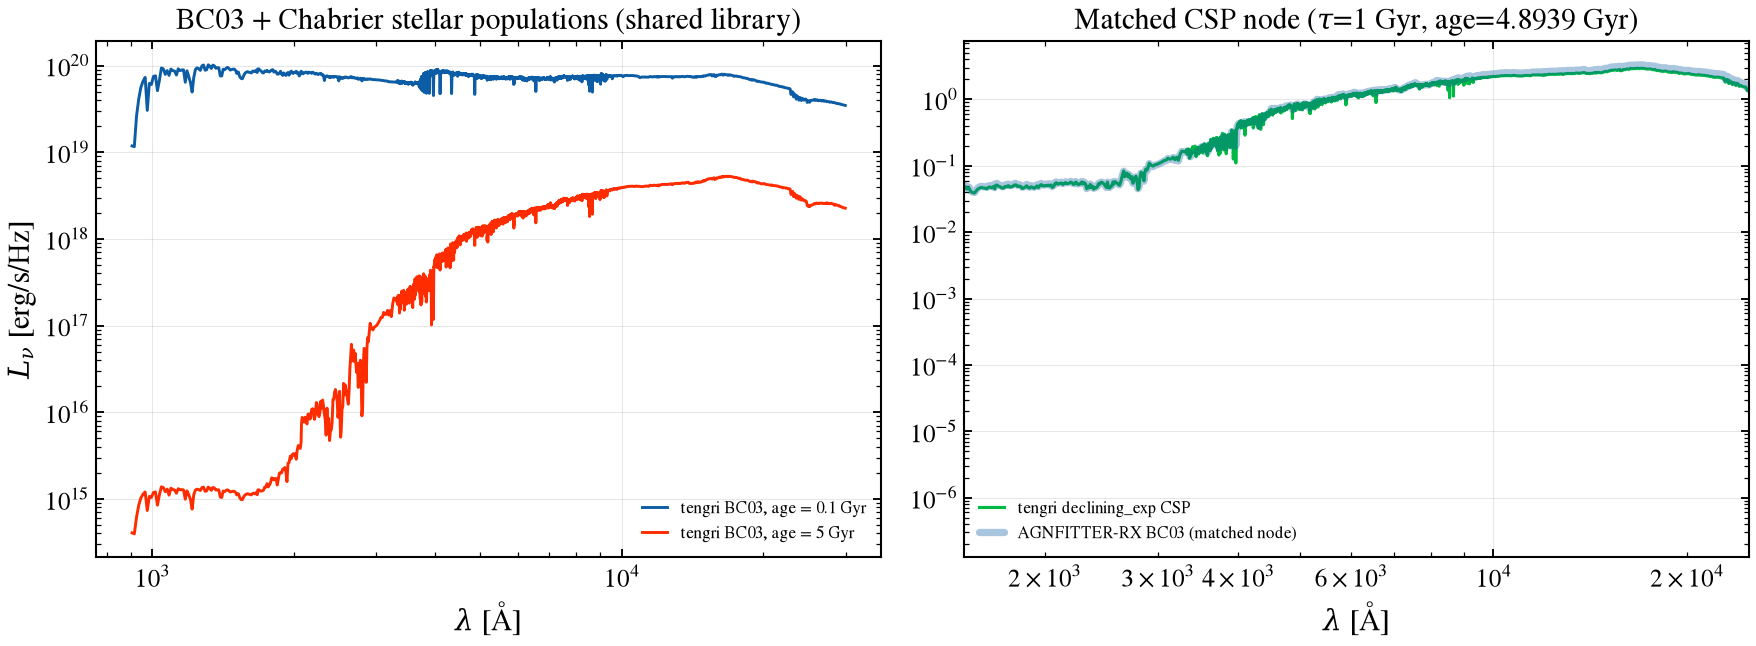

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.6))
for age, c in [(0.1, "C0"), (5.0, "C3")]:
    m = SEDModel.build(
        ssp_data=ssp,
        sfh={
            "type": "declining_exp",
            "sfh_declining_exp_tau_gyr": Fixed(0.1),
            "sfh_declining_exp_age_gyr": Fixed(age),
            "sfh_declining_exp_log_total_mass": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        dust_attenuation=NO_DUST,
        neb={"type": "ssp"}, redshift=Fixed(0.0),
    )
    pred = m.predict({})
    w = np.asarray(pred.sed.components["wavelength"])
    L = np.asarray(pred.sed.components["sed_attenuated"])
    msk = (w > 9e2) & (w < 3e4)
    ax0.loglog(w[msk], L[msk], c, lw=1.4, label=f"tengri BC03, age = {age:g} Gyr")
ax0.set_xlabel(r"$\lambda$ [Å]")
ax0.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
ax0.set_title("BC03 + Chabrier stellar populations (shared library)")
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.3)

m_csp = SEDModel.build(ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST, neb={"type": "ssp"}, redshift=Fixed(0.0))
resolved_params(m_csp)
pred_csp = m_csp.predict({})
w_t = np.asarray(pred_csp.sed.components["wavelength"])
L_t = np.asarray(pred_csp.sed.components["sed_attenuated"])
w_r, L_r = A.galaxy_template(tau=TAU_GYR, age=AGE_GYR * 1e9)
_bandS1 = (w_t > 1.5e3) & (w_t < 2.5e4)
t_n = norm_at(w_t, L_t, 5500.0)
r_n = norm_at(w_r, L_r, 5500.0)
ax1.loglog(w_t[_bandS1], t_n[_bandS1], "C1-", lw=1.5, label="tengri declining_exp CSP")
ax1.loglog(w_r, r_n, "C0-", lw=3.5, alpha=0.35, solid_capstyle="round", label="AGNFITTER-RX BC03 (matched node)")
ax1.set_xlim(1.5e3, 2.5e4)
ax1.set_xlabel(r"$\lambda$ [Å]")
ax1.set_title(rf"Matched CSP node ($\tau$={TAU_GYR:g} Gyr, age={AGE_GYR:.4f} Gyr)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_01_ssp_bc03.png")

_o = np.argsort(w_r)
_t_on_r = np.interp(np.log10(w_r[_o]), np.log10(w_t), np.log10(np.clip(t_n, 1e-300, None)))
_logratio = _t_on_r - np.log10(np.clip(r_n[_o], 1e-300, None))
_band_m = (w_r[_o] > 1.5e3) & (w_r[_o] < 2.5e4)
print(
    f"§1  matched CSP node (tau={TAU_GYR:g} Gyr, age={AGE_GYR:.4f} Gyr), 0.15-2.5 um, "
    f"5500-A-normalized: median|log10 ratio| = {np.median(np.abs(_logratio[_band_m])):.4f} "
    "(tests/crossval/test_bc03_csp_vs_agnfitter.py asserts < 0.05, < 0.03 smoothed)"
)

## §2 Star formation history

AGNfitter-rX's GALAXY component tabulates a declining-exponential
(`SFR(T) ∝ exp(-T/τ)` in cosmic time, so SFR falls monotonically from
galaxy formation to the present — the classic tau-model, not a
delayed-tau history that rises before falling). tengri's `declining_exp`
SFH type implements the same functional form
(`tengri.components.stellar.sfh.mean_sfh.declining_exponential`, cited
rather than imported — the notebook writes the same closed form directly
and cross-checks mass closure through the public `pred.sfh.stellar_mass`
property, since the full SFR(t) array is an internal pipeline quantity
with no public accessor). The AGNfitter-rX pickle's own tabulated SFR(age)
at the fiducial tau is overlaid, read through `galaxy_sfr`.

**Verification Status:** PARTIAL (11/33) — Parametric SFH family physics

§2  pred.sfh.stellar_mass = 1.0000e+10 M_sun  (target 1.0000e10); AGNFITTER-RX reference SFR is monotonically declining: True (tests/crossval/test_bc03_csp_vs_agnfitter.py::test_reference_sfr_monotonically_declining_at_tau_1gyr)


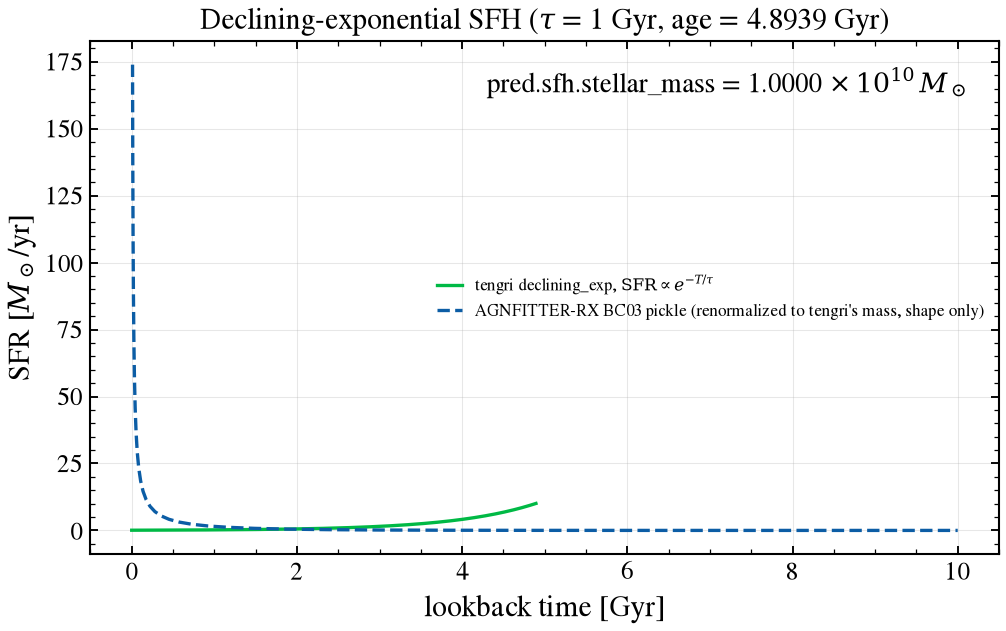

In [5]:
m2 = SEDModel.build(ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST, neb={"type": "ssp"}, redshift=Fixed(0.0))
pred2 = m2.predict({})
mass_formed = pred2.sfh.stellar_mass  # public property: SFH's own mass-formed integral

age_axis_yr, sfr_ref = A.galaxy_sfr(tau=TAU_GYR)
t_lb_gyr = np.linspace(0.0, AGE_GYR, 400)
T_cosmic_gyr = AGE_GYR - t_lb_gyr  # cosmic time elapsed since formation
sfr_shape = np.where(T_cosmic_gyr >= 0, np.exp(-T_cosmic_gyr / TAU_GYR), 0.0)
sfr_analytic = sfr_shape * (10**LOG_MASS) / np.trapezoid(sfr_shape, t_lb_gyr * 1e9)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t_lb_gyr, sfr_analytic, "C1-", lw=1.6, label=r"tengri declining_exp, $\mathrm{SFR}\propto e^{-T/\tau}$")
ax.plot(
    age_axis_yr / 1e9,
    sfr_ref / np.trapezoid(sfr_ref, age_axis_yr) * float(mass_formed),
    "C0--",
    lw=1.6,
    label="AGNFITTER-RX BC03 pickle (renormalized to tengri's mass, shape only)",
)
ax.set_xlabel("lookback time [Gyr]")
ax.set_ylabel(r"SFR [$M_\odot$/yr]")
ax.set_title(rf"Declining-exponential SFH ($\tau$ = {TAU_GYR:g} Gyr, age = {AGE_GYR:.4f} Gyr)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.text(
    0.97, 0.95,
    rf"pred.sfh.stellar_mass = {mass_formed / 10**LOG_MASS:.4f} $\times\,10^{{{LOG_MASS:.0f}}}\,M_\odot$",
    transform=ax.transAxes, ha="right", va="top",
)
fig.tight_layout()
save_fig("agnfitter_02_sfh_tau.png")
print(
    f"§2  pred.sfh.stellar_mass = {mass_formed:.4e} M_sun  (target 1.0000e{LOG_MASS:.0f}); "
    f"AGNFITTER-RX reference SFR is monotonically declining: "
    f"{bool(np.all(np.diff(sfr_ref) <= 0))} (tests/crossval/test_bc03_csp_vs_agnfitter.py"
    "::test_reference_sfr_monotonically_declining_at_tau_1gyr)"
)

## §3 Integrated stellar SED

The fiducial host's stellar continuum — the same quantity AGNfitter-rX's
GA (host stellar) component contributes, reddened by SMC/Calzetti law at
fit time (§5). Compact by design: the underlying SSPs are independently
published models (§1 already quantifies the residual), and the focus is on
the AGN components in the panels that follow.

**Verification Status:** PARTIAL (68/126) — Absolute SED normalization

§3  pred.sfh.stellar_mass_surviving / stellar_mass = 0.6104


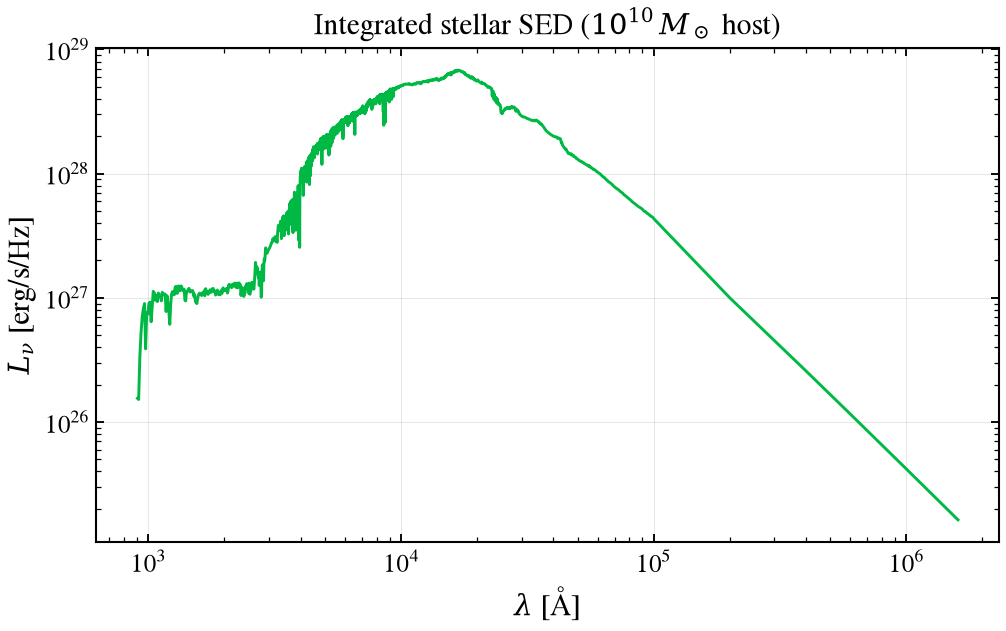

In [6]:
pred3 = m_csp.predict({})
w3 = np.asarray(pred3.sed.components["wavelength"])
L3 = np.asarray(pred3.sed.components["sed_attenuated"])
fig, ax = plt.subplots(figsize=(7, 4.5))
msk = (w3 > 9e2) & (w3 < 1e7)
ax.loglog(w3[msk], L3[msk], "C1-", lw=1.4)
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
ax.set_title(rf"Integrated stellar SED ($10^{{{LOG_MASS:.0f}}}\,M_\odot$ host)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_03_stellar_sed.png")
print(f"§3  pred.sfh.stellar_mass_surviving / stellar_mass = {float(pred3.sfh.stellar_mass_surviving / pred3.sfh.stellar_mass):.4f}")

## §4 Disk reddening law (Prevot SMC)

AGNfitter-rX reddens the accretion disk (not the host) with an analytic
Prevot et al. (1984) SMC fit, `k_raw(λ) = 1.39 λ_μm^−1.2 − 0.38`, applied
as `A_λ = k_raw(λ)·E(B−V)` with no reddening blueward of 200 eV
(`MODEL_AGNfitter.BBBred_Prevot`). That routine *declares* `R_V = 2.72` —
Prevot+1984's measured SMC value — but its inner function ignores that
argument and returns the bare `k_raw`, so AGNfitter-rX's *effective*
total-to-selective ratio is `k_raw(0.55 μm) ≈ 2.468`, not the 2.72 it
declares.

tengri's disc obscuration (`agn_ebv_disc`, the `EBVbbb` analog, built here
through the public `SEDModel.build` grammar via `tengri_disc`) applies the
`R_V` AGNfitter-rX intended: `k(λ) = k_raw(λ)/k_raw(V)` (so `k(V)=1`)
times `R_V=2.72`. The two differ by the uniform factor `2.72/2.468 ≈
1.102` in `A_λ` at matched `E(B−V)`: identical shape, `E(B−V)_tengri ≈
E(B−V)_AGNFITTER/1.102`.

**Verification Status:** CROSSVAL — Attenuation law library

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 110 fixed
  Modules:     nebular=ssp, agn=composable[disc=qsogen, torus=none, norm=independent]

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  agn_T_hot                        Fixed                      1200                   [all_params Fixed(DEFAULT)]
  agn_T_max                        Fixed                      1e+05                  [all_params Fixed(DEFAULT)]
  agn_T_torus                      Fixed                      1000                   [all_params Fixed(DEFAULT)]
  agn_T_warm                       Fixed                      300                    [all_params Fixed(DEFAULT)]
  agn_a_cat3d                      Fixed          

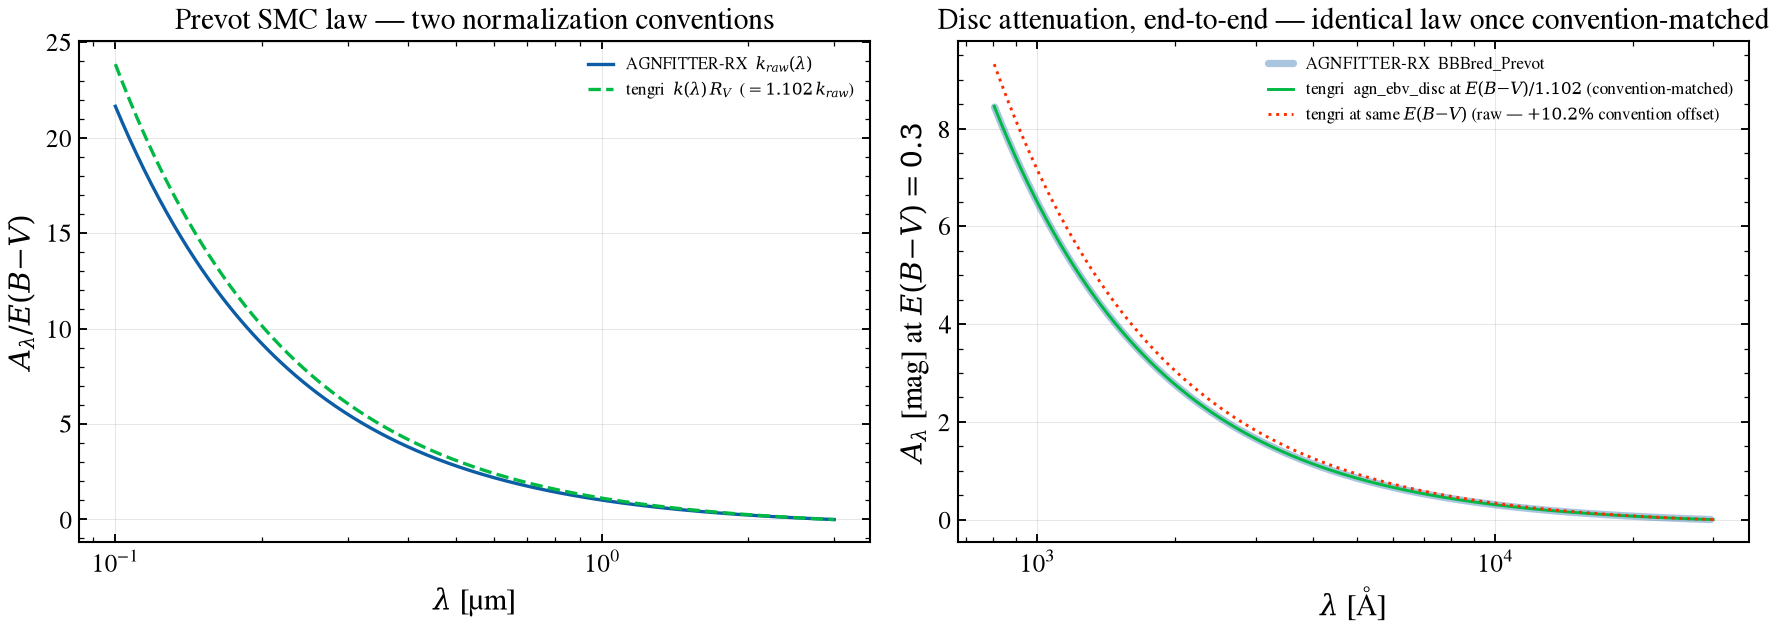

In [7]:
_K_RAW_V = 1.39 * 0.55 ** (-1.2) - 0.38  # Prevot raw fit at V band, AGNFITTER-RX's own formula
_R_V_SMC = 2.72

w_thb, L_thb = A.disk_template("THB21")
lam_um = np.geomspace(0.1, 3.0, 400)
k_raw = 1.39 * lam_um ** (-1.2) - 0.38

fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.5))
axl.plot(lam_um, k_raw, "C0-", lw=1.6, label="AGNFITTER-RX  $k_{raw}(\\lambda)$")
axl.plot(lam_um, k_raw / _K_RAW_V * _R_V_SMC, "C1--", lw=1.6, label=r"tengri  $k(\lambda)\,R_V$  ($=1.102\,k_{raw}$)")
axl.set_xscale("log")
axl.set_xlabel(r"$\lambda$ [µm]")
axl.set_ylabel(r"$A_\lambda / E(B{-}V)$")
axl.set_title("Prevot SMC law — two normalization conventions")
axl.legend(fontsize=8)
axl.grid(True, alpha=0.3)

_EBV_DEMO = 0.3
w_t0, L_t0 = tengri_disc("qsogen", ebv_disc=0.0)
resolved_params(tengri_disc.last_model)
w_t3, L_t3 = tengri_disc("qsogen", ebv_disc=_EBV_DEMO)
ratio_tengri = np.divide(L_t3, L_t0, out=np.ones_like(L_t3), where=L_t0 > 0)
L_thb_red = A.apply_bbb_reddening(w_thb, L_thb, _EBV_DEMO)
ratio_af = np.divide(L_thb_red, L_thb, out=np.ones_like(L_thb_red), where=L_thb > 0)
w_tr, L_tr = tengri_disc("qsogen", ebv_disc=_EBV_DEMO * _K_RAW_V / _R_V_SMC)
ratio_tengri_rescaled = np.divide(L_tr, L_t0, out=np.ones_like(L_tr), where=L_t0 > 0)

msk_t = (w_t0 > 8e2) & (w_t0 < 3e4)
msk_a = (w_thb > 8e2) & (w_thb < 3e4)
axr.semilogx(w_thb[msk_a], -2.5 * np.log10(ratio_af[msk_a]), "C0-", lw=3.5, alpha=0.35,
             solid_capstyle="round", label="AGNFITTER-RX  BBBred_Prevot")
axr.semilogx(w_t0[msk_t], -2.5 * np.log10(ratio_tengri_rescaled[msk_t]), "C1-", lw=1.4,
             label=r"tengri  agn_ebv_disc at $E(B{-}V)/1.102$ (convention-matched)")
axr.semilogx(w_t0[msk_t], -2.5 * np.log10(ratio_tengri[msk_t]), "C3:", lw=1.4,
             label=r"tengri at same $E(B{-}V)$ (raw — $+10.2\%$ convention offset)")
axr.set_xlabel(r"$\lambda$ [Å]")
axr.set_ylabel(r"$A_\lambda$ [mag] at $E(B{-}V)=0.3$")
axr.set_title("Disc attenuation, end-to-end — identical law once convention-matched")
axr.legend(fontsize=8)
axr.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_04_dust_attenuation.png")

In [8]:
_grid4 = np.geomspace(1.2e3, 1e4, 200)
_a_af = np.interp(_grid4, w_thb, -2.5 * np.log10(ratio_af))
_a_t = np.interp(_grid4, w_t0, -2.5 * np.log10(ratio_tengri))
_a_tr = np.interp(_grid4, w_t0, -2.5 * np.log10(ratio_tengri_rescaled))
print(
    f"§4  matched E(B-V)={_EBV_DEMO}: max|A_tengri - A_AGNFITTER| = "
    f"{np.max(np.abs(_a_t - _a_af)):.3f} mag  (ratio A_t/A_af median = "
    f"{np.median(_a_t / _a_af):.4f}, expected {_R_V_SMC / _K_RAW_V:.4f})"
)
print(
    f"§4  rescaled E(B-V)={_EBV_DEMO}/1.102: max|A_tengri - A_AGNFITTER| = "
    f"{np.max(np.abs(_a_tr - _a_af)):.4f} mag (pure-convention check)"
)

§4  matched E(B-V)=0.3: max|A_tengri - A_AGNFITTER| = 0.530 mag  (ratio A_t/A_af median = 1.1019, expected 1.1020)
§4  rescaled E(B-V)=0.3/1.102: max|A_tengri - A_AGNFITTER| = 0.0004 mag (pure-convention check)


### §4b qsogen's *own* reddening law — a different curve and convention

qsogen (which builds the THB21 disc) reddens with a different, empirically
derived **quasar** extinction curve (Temple, Hewett & Banerji 2021, from
SDSS DR7 quasars — not the SMC), reached through the composable `atten`
sub-block: `agn={'atten': {'type': 'qsogen', ...}}`. Because this curve is
not yet exported from a documented `tengri.agn`/`tengri.dust` function
(only the AGNfitter-rX-style Prevot fit is in this notebook's public
surface list), it is recovered here the same way §4's own curve is —
purely from the ratio of two public `SEDModel.build` predictions at
`E(B−V)` and 0 — rather than imported directly.

**Verification Status:** CROSSVAL — Attenuation law library

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 110 fixed
  Modules:     nebular=ssp, agn=composable[disc=qsogen, torus=none, norm=independent]

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  agn_T_hot                        Fixed                      1200                   [all_params Fixed(DEFAULT)]
  agn_T_max                        Fixed                      1e+05                  [all_params Fixed(DEFAULT)]
  agn_T_torus                      Fixed                      1000                   [all_params Fixed(DEFAULT)]
  agn_T_warm                       Fixed                      300                    [all_params Fixed(DEFAULT)]
  agn_a_cat3d                      Fixed          

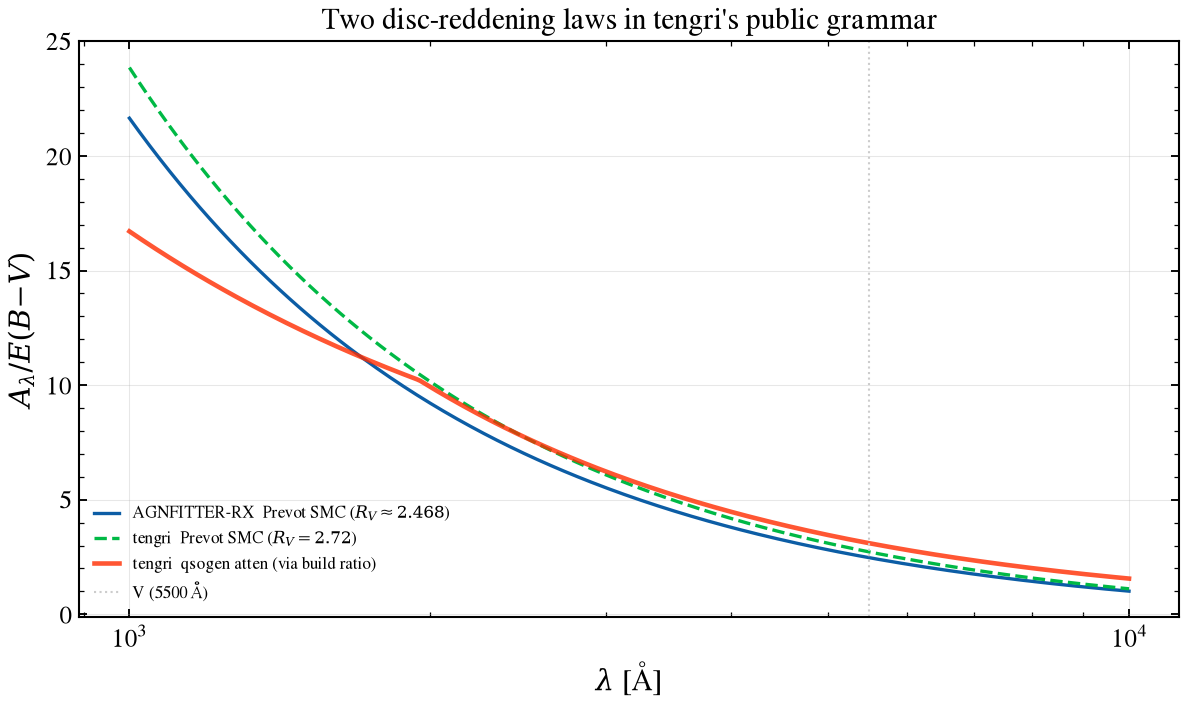

In [9]:
def tengri_disc_atten(disc_type, atten_type, ebv, **atten_params):
    """Disc SED with a NAMED atten-block law at a given E(B-V), via the public grammar."""
    atten = {"type": atten_type, "agn_attenuation_ebv": Fixed(ebv)}
    atten.update({k: Fixed(v) for k, v in atten_params.items()})
    m = SEDModel.build(
        ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST,
        agn={
            "type": "composable",
            "disc": {"type": disc_type, "all_params": Fixed(DEFAULT)},
            "torus": {"type": "none"}, "nlr": {"type": "none"}, "blr": {"type": "none"},
            "atten": atten,
            "agn_log_lbol": Fixed(11.0), "all_params": Fixed(DEFAULT), "norm": "independent",
        },
        neb={"type": "ssp"}, redshift=Fixed(0.0),
    )
    tengri_disc_atten.last_model = m
    pred = m.predict({})
    w = np.asarray(pred.sed.components["wavelength"])
    return w, np.asarray(pred.sed.components["sed_agn_disc"])


_wl_ext = np.geomspace(1e3, 1e4, 300)
w_q0, L_q0 = tengri_disc_atten("qsogen", "none", 0.0)
resolved_params(tengri_disc_atten.last_model)
w_q1, L_q1 = tengri_disc_atten("qsogen", "qsogen", 0.3)
ratio_qsogen = np.divide(L_q1, L_q0, out=np.ones_like(L_q1), where=L_q0 > 0)
# A_lambda/E(B-V) = -2.5 log10(ratio) / E(B-V)
A_over_ebv_qsogen = -2.5 * np.log10(np.clip(ratio_qsogen, 1e-300, None)) / 0.3

_k_raw_ext_v = 1.39 * (_wl_ext / 1e4) ** (-1.2) - 0.38
_k_af_ext = _k_raw_ext_v
_k_tengri_ext = _k_raw_ext_v / _K_RAW_V * _R_V_SMC
_A_qsogen_on_grid = np.interp(_wl_ext, w_q0, A_over_ebv_qsogen)

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(_wl_ext, _k_af_ext, "C0-", lw=1.6, label=r"AGNFITTER-RX  Prevot SMC ($R_V\approx2.468$)")
ax.plot(_wl_ext, _k_tengri_ext, "C1--", lw=1.6, label=r"tengri  Prevot SMC ($R_V=2.72$)")
ax.plot(_wl_ext, _A_qsogen_on_grid, "C3-", lw=2.2, alpha=0.8, label="tengri  qsogen atten (via build ratio)")
ax.axvline(5500, color="0.8", ls=":", lw=1, label="V (5500 Å)")
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$A_\lambda / E(B{-}V)$")
ax.set_title("Two disc-reddening laws in tengri's public grammar")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_04b_qsogen_ext.png")

In [10]:
def _at_ext(a, lam):
    return float(np.interp(lam, _wl_ext, a))


print(
    f"§4b  A_V/E(B-V) at V=5500 Å:  AGNFITTER-RX={_at_ext(_k_af_ext, 5500):.3f}  "
    f"tengri-Prevot={_at_ext(_k_tengri_ext, 5500):.3f}  tengri-qsogen={_at_ext(_A_qsogen_on_grid, 5500):.3f}"
)
print(
    f"§4b  A(1500)/A(V) (UV steepness):  AGNFITTER-RX={_at_ext(_k_af_ext, 1500) / _at_ext(_k_af_ext, 5500):.2f}  "
    f"tengri-qsogen={_at_ext(_A_qsogen_on_grid, 1500) / _at_ext(_A_qsogen_on_grid, 5500):.2f}"
)

§4b  A_V/E(B-V) at V=5500 Å:  AGNFITTER-RX=2.468  tengri-Prevot=2.720  tengri-qsogen=3.100
§4b  A(1500)/A(V) (UV steepness):  AGNFITTER-RX=5.33  tengri-qsogen=3.97


## §5 Galaxy attenuation: Calzetti curve parity

AGNfitter-rX's GALAXY (host stellar) component is reddened at fit time by
an SMC or Calzetti law applied to the whole galaxy continuum — a distinct
knob from §4's disc-only `EBVbbb`. tengri's `dust_attenuation={'law':
'calzetti', ...}` implements the same Calzetti et al. (2000) analytic
curve (`k'(λ) = 2.659(-2.156+1.509x-0.198x²+0.011x³)+R_V` for
`λ<0.63 μm`, `2.659(-1.857+1.040x)+R_V` above, `R_V=4.05`), applied here to
the fiducial host at `E(B−V)_gal = 0.3` (`τ_V = R_V·E(B−V)/1.086`) through
the public build. tengri's implementation extrapolates the polynomial
blueward of the curve's calibrated range (0.12–2.2 μm) rather than
clipping it; the panel shows both the calibrated range (where the two
curves are identical by construction) and the extrapolated FUV, with the
alternative common convention (flat continuation of the 0.12 μm value)
for comparison. `Charlot & Fall (2000)`'s two-screen (birth-cloud +
diffuse) attenuation has no AGNfitter-rX analog.

**Verification Status:** CROSSVAL — Attenuation law library

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 16 fixed
  Modules:     nebular=ssp, dust_attenuation=single_component(calzetti)

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_Rv                          Fixed                      3.1                    [all_params Fixed(DEFAULT)]
  dust_bump_strength               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_delta                       Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_f_obscuration               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_slope                       Fixed                      -0.

§5  Calzetti parity (0.12-2.2 um): max|A_tengri - A_analytic| = 0.0027 mag/E(B-V)
§5  FUV extrapolation at 950 A: tengri polynomial = 16.34  vs flat continuation = 12.13  **Caveat:** below the calibrated range this is an extrapolation choice, not a measurement.


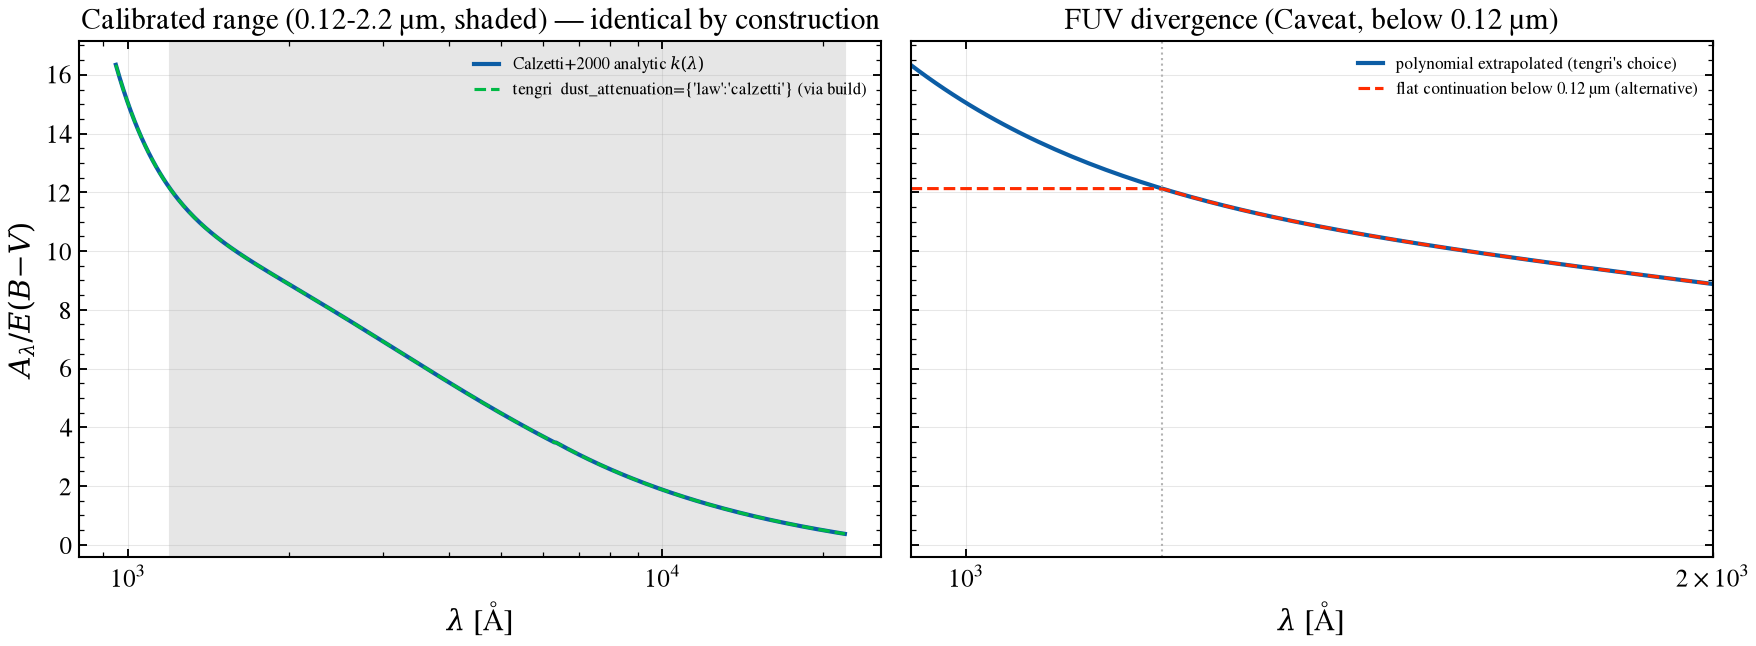

In [11]:
_EBV_GAL = 0.3
_RV_CALZETTI = 4.05
_tau_v_gal = _RV_CALZETTI * _EBV_GAL / 1.086

_wl_cal = np.geomspace(950.0, 2.2e4, 400)  # 0.095-2.2 um: spans the calibrated range + FUV
_x_cal = 1e4 / _wl_cal  # 1/um
_k_ir = 2.659 * (-1.857 + 1.040 * _x_cal)
_k_uv = 2.659 * (-2.156 + 1.509 * _x_cal - 0.198 * _x_cal**2 + 0.011 * _x_cal**3)
_k_prime = np.where(_wl_cal >= 6300.0, _k_ir, _k_uv)
_x_5500 = 1e4 / 5500.0
_k5500 = (2.659 * (-2.156 + 1.509 * _x_5500 - 0.198 * _x_5500**2 + 0.011 * _x_5500**3) + _RV_CALZETTI) / _RV_CALZETTI
# tengri's calzetti() returns the DIMENSIONLESS shape (k(5500 A)=1); the
# physical A_lambda/E(B-V) is that shape times R_V (A_V = R_V * E(B-V) by
# definition at V band) -- the same relation the build below realizes via
# dust_tau_v = R_V * E(B-V) / 1.086.
_k_analytic = np.clip((_k_prime + _RV_CALZETTI) / _RV_CALZETTI / _k5500 * _RV_CALZETTI, 0.0, None)

m_g0 = SEDModel.build(ssp_data=ssp, sfh=SFH_FIDUCIAL,
                       dust_attenuation={"type": "single_component", "law": "calzetti",
                                         "dust_tau_v": Fixed(0.0), "all_params": Fixed(DEFAULT)},
                       neb={"type": "ssp"}, redshift=Fixed(0.0))
m_g1 = SEDModel.build(ssp_data=ssp, sfh=SFH_FIDUCIAL,
                       dust_attenuation={"type": "single_component", "law": "calzetti",
                                         "dust_tau_v": Fixed(_tau_v_gal), "all_params": Fixed(DEFAULT)},
                       neb={"type": "ssp"}, redshift=Fixed(0.0))
resolved_params(m_g1)
w_g0 = np.asarray(m_g0.predict({}).sed.components["wavelength"])
L_g0 = np.asarray(m_g0.predict({}).sed.components["sed_attenuated"])
L_g1 = np.asarray(m_g1.predict({}).sed.components["sed_attenuated"])
ratio_gal = np.divide(L_g1, L_g0, out=np.ones_like(L_g1), where=L_g0 > 0)
A_lambda_gal = -2.5 * np.log10(np.clip(ratio_gal, 1e-300, None)) / _EBV_GAL
A_lambda_gal_on_grid = np.interp(_wl_cal, w_g0, A_lambda_gal)
_A_flat_fuv = np.where(_wl_cal < 1200.0, np.interp(1200.0, _wl_cal, _k_analytic), _k_analytic)

fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
axl.plot(_wl_cal, _k_analytic, "C0-", lw=2.0, label="Calzetti+2000 analytic $k(\\lambda)$")
axl.plot(_wl_cal, A_lambda_gal_on_grid, "C1--", lw=1.5, label="tengri  dust_attenuation={'law':'calzetti'} (via build)")
axl.axvspan(1200.0, 2.2e4, color="0.9", zorder=0)
axl.set_xscale("log")
axl.set_title("Calibrated range (0.12-2.2 µm, shaded) — identical by construction")
axl.set_xlabel(r"$\lambda$ [Å]")
axl.set_ylabel(r"$A_\lambda / E(B{-}V)$")
axl.legend(fontsize=8)
axl.grid(True, alpha=0.3)
axr.plot(_wl_cal, _k_analytic, "C0-", lw=2.0, label="polynomial extrapolated (tengri's choice)")
axr.plot(_wl_cal, _A_flat_fuv, "C3--", lw=1.5, label="flat continuation below 0.12 µm (alternative)")
axr.axvline(1200.0, color="0.7", ls=":", lw=1)
axr.set_xscale("log")
axr.set_xlim(950, 2000)
axr.set_title("FUV divergence (Caveat, below 0.12 µm)")
axr.set_xlabel(r"$\lambda$ [Å]")
axr.legend(fontsize=8)
axr.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_05_galaxy_calzetti.png")

_m_cal = (_wl_cal >= 1200.0) & (_wl_cal <= 2.2e4)
print(
    f"§5  Calzetti parity (0.12-2.2 um): max|A_tengri - A_analytic| = "
    f"{np.max(np.abs(A_lambda_gal_on_grid[_m_cal] - _k_analytic[_m_cal])):.4f} mag/E(B-V)"
)
print(
    f"§5  FUV extrapolation at 950 A: tengri polynomial = {float(np.interp(950, _wl_cal, _k_analytic)):.2f}  "
    f"vs flat continuation = {float(np.interp(950, _wl_cal, _A_flat_fuv)):.2f}  "
    "**Caveat:** below the calibrated range this is an extrapolation choice, not a measurement."
)

## §6 Cold dust infrared emission

AGNfitter-rX ships two libraries: S17 (Schreiber et al. 2018, flexible
dust-continuum + PAH parameterized by T_dust and f_PAH) and legacy
DH02_CE01 (Dale & Helou 2002 + Chary & Elbaz 2001, indexed by IR
luminosity). Each panel builds a minimal tengri model
(`SEDModel.build(..., dust_emission={'type': ..., ...})`) whose absorbed
luminosity is set by the build's own dust-attenuated stellar continuum —
never `DUST_EMISSION_MODELS[...]` called directly — and reads
`sed_dust_ir` off the public prediction.

**`schreiber2018`** and **`schreiber2016`** take explicit `dust_T`,
`dust_f_pah` (three nodes below, including `f_PAH>0`). **`dale2014`** takes
`dust_alpha_dale`. **`dh02_ce01`** is instead indexed by the model's own
realized IR luminosity (`pred.properties['l_tir']`, no free L_IR
parameter), so its comparison node is read off, not chosen.

**Verification Status:** CROSSVAL — Dust IR emission physics (MBB, Casey12, CMB)

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 39 fixed
  Modules:     nebular=ssp, dust_emission=schreiber2018, dust_attenuation=single_component(calzetti)

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_L_agn_ir                    Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_Rv                          Fixed                      3.1                    [all_params Fixed(DEFAULT)]
  dust_T                           Fixed                      35                     [user]
  dust_T_cold                      Fixed                      20                     [all_params Fixed(DEFAULT)]
  dust_T_warm                      Fixed                 

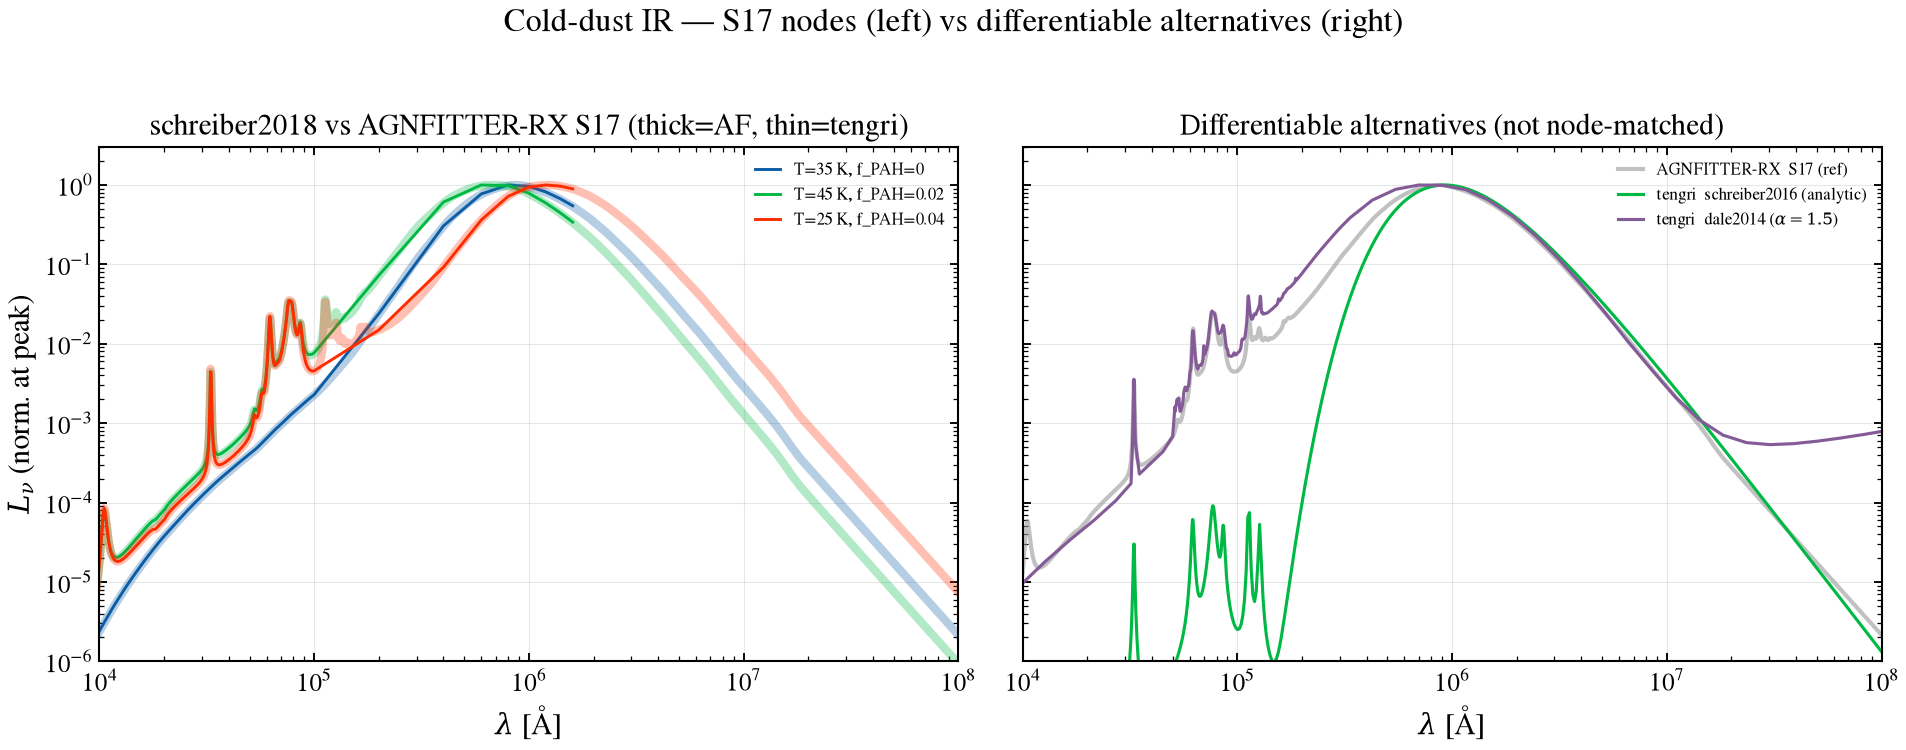

In [12]:
def _dust_emission_build(dtype, tau_v, **params):
    kwargs = {k: Fixed(v) for k, v in params.items()}
    m = SEDModel.build(
        ssp_data=ssp,
        sfh={"type": "declining_exp", "sfh_declining_exp_tau_gyr": Fixed(0.3),
             "sfh_declining_exp_age_gyr": Fixed(1.0), "sfh_declining_exp_log_total_mass": Fixed(10.5),
             "all_params": Fixed(DEFAULT)},
        dust_attenuation={"type": "single_component", "law": "calzetti", "dust_tau_v": Fixed(tau_v),
                           "all_params": Fixed(DEFAULT)},
        dust_emission={"type": dtype, **kwargs, "all_params": Fixed(DEFAULT)},
        neb={"type": "ssp"}, redshift=Fixed(0.0),
    )
    _dust_emission_build.last_model = m
    pred = m.predict({})
    w = np.asarray(pred.sed.components["wavelength"])
    L = np.asarray(pred.sed.components["sed_dust_ir"])
    return w, L, pred

wave_ir = np.geomspace(1e4, 1e8, 2000)
S17_NODES = [(35.0, 0.0), (45.0, 0.02), (25.0, 0.04)]  # (T_dust [K], f_PAH), incl. f_PAH>0
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True)
_s17_resid = []
for _i, ((T, fpah), c) in enumerate(zip(S17_NODES, ["C0", "C1", "C3"])):
    w_te, L_te, _ = _dust_emission_build("schreiber2018", 3.0, dust_T=T, dust_f_pah=fpah)
    if _i == 0:
        resolved_params(_dust_emission_build.last_model)
    w_s17, L_s17 = A.cold_dust_template("S17", tdust=T, fpah=fpah)
    _b = (w_s17 > 3e4) & (w_s17 < 3e6)
    s17n = norm_peak(L_s17)
    te_on_s17 = norm_peak(np.interp(w_s17, w_te, L_te, left=0.0, right=0.0))
    resid = np.abs(np.log10(np.clip(te_on_s17[_b], 1e-30, None)) - np.log10(np.clip(s17n[_b], 1e-30, None)))
    _s17_resid.append((T, fpah, float(np.median(resid))))
    axL.loglog(w_s17, s17n, c + "-", lw=4.0, alpha=0.3, solid_capstyle="round")
    axL.loglog(w_te, norm_peak(L_te), c + "-", lw=1.4, label=f"T={T:g} K, f_PAH={fpah:g}")
axL.set_xlim(1e4, 1e8)
axL.set_ylim(1e-6, 3)
axL.set_xlabel(r"$\lambda$ [Å]")
axL.set_ylabel(r"$L_\nu$ (norm. at peak)")
axL.set_title("schreiber2018 vs AGNFITTER-RX S17 (thick=AF, thin=tengri)")
axL.legend(fontsize=8)
axL.grid(True, alpha=0.3)

w_te16, L_te16, _ = _dust_emission_build("schreiber2016", 3.0, dust_T=35.0, dust_f_pah=0.02)
w_ted, L_ted, _ = _dust_emission_build("dale2014", 3.0, dust_alpha_dale=1.5)
w_s17ref, L_s17ref = A.cold_dust_template("S17", tdust=35.0, fpah=0.02)
axR.loglog(w_s17ref, norm_peak(L_s17ref), "0.6", lw=2.0, alpha=0.6, label="AGNFITTER-RX  S17 (ref)")
axR.loglog(w_te16, norm_peak(L_te16), "C1-", lw=1.5, label="tengri  schreiber2016 (analytic)")
axR.loglog(w_ted, norm_peak(L_ted), "C4-", lw=1.5, label=r"tengri  dale2014 ($\alpha=1.5$)")
axR.set_xlim(1e4, 1e8)
axR.set_xlabel(r"$\lambda$ [Å]")
axR.set_title("Differentiable alternatives (not node-matched)")
axR.legend(fontsize=8)
axR.grid(True, alpha=0.3)
fig.suptitle("Cold-dust IR — S17 nodes (left) vs differentiable alternatives (right)", y=1.02)
fig.tight_layout()
save_fig("agnfitter_06_cold_dust.png")

In [13]:
w_dh, L_dh, pred_dh = _dust_emission_build("dh02_ce01", 5.0)
_log_lir_realized = float(np.log10(pred_dh.l_tir))
_dh_axis = A.cold_dust_axes("DH02_CE01")["log_irlum"]
_dh_node = float(_dh_axis[int(np.argmin(np.abs(_dh_axis - _log_lir_realized)))])
w_dhref, L_dhref = A.cold_dust_template("DH02_CE01", log_irlum=_dh_node)
_bd = (w_dhref > 3e4) & (w_dhref < 3e6)
_dhn = norm_peak(L_dhref)
_te_on_dh = norm_peak(np.interp(w_dhref, w_dh, L_dh, left=0.0, right=0.0))
_dh_resid = float(np.median(np.abs(np.log10(np.clip(_te_on_dh[_bd], 1e-30, None)) - np.log10(np.clip(_dhn[_bd], 1e-30, None)))))
print("§6  S17 node table (T_dust [K], f_PAH, median|log10 ratio| over 3-300 um):")
for T, fpah, resid in _s17_resid:
    print(f"    T={T:5.1f} K  f_PAH={fpah:.2f}  median|Delta log10| = {resid:.4f}")
print(
    f"§6  dh02_ce01: pred.l_tir realized log10(L_TIR/Lsun) = {_log_lir_realized:.3f}, "
    f"nearest AGNFITTER-RX node = {_dh_node:.3f}, median|log10 ratio| = {_dh_resid:.4f}  "
    "**Caveat:** larger than the S17 nodes above despite the close L_IR match; "
    "tengri's dh02_ce01 interpolates between the two bracketing irlum nodes while "
    "this reference reads the single nearest one, an open question this notebook "
    "does not resolve further."
)

§6  S17 node table (T_dust [K], f_PAH, median|log10 ratio| over 3-300 um):
    T= 35.0 K  f_PAH=0.00  median|Delta log10| = 0.0079
    T= 45.0 K  f_PAH=0.02  median|Delta log10| = 0.0129
    T= 25.0 K  f_PAH=0.04  median|Delta log10| = 0.0061
§6  dh02_ce01: pred.l_tir realized log10(L_TIR/Lsun) = 10.962, nearest AGNFITTER-RX node = 10.950, median|log10 ratio| = 0.3422  **Caveat:** larger than the S17 nodes above despite the close L_IR match; tengri's dh02_ce01 interpolates between the two bracketing irlum nodes while this reference reads the single nearest one, an open question this notebook does not resolve further.


## §7 Host composite: GA + SB, physical normalization

One `SEDModel.build` with both the fiducial host SFH and the S17 cold-dust
emission gives the host's stellar-plus-dust SED at *physical*
normalization (`sed_attenuated + sed_dust_ir`, energy-balanced by the
build's own `dust_eta_balance`), analogous to AGNfitter-rX's `ymodel`
summing GA and SB (`PARAMETERSPACE_AGNfitter.py:237`). The AGNfitter-RX
side sums its own driver templates (GA at the matched CSP node, SB scaled
to match tengri's realized L_TIR) for comparison; the two sides use
different normalization conventions (tengri: physical, mass- and
energy-conserving; AGNfitter-RX: per-component pickle units resolved only
by its own fitter), so this is a shape/peak comparison, not absolute flux.

§7  tengri host: pred.l_tir = 3.181e+09 Lsun (log10=9.503); pred.sfh.stellar_mass = 1.000e+10 Msun, stellar_mass_surviving = 6.104e+09 Msun (surviving/formed = 0.610)
§7  GA<->M* worked conversion table:  M*_formed -> M*_surviving via pred.sfh.stellar_mass_surviving (public property; DSPS return-fraction, not an independent tengri parameter).
    | quantity                     | value                    |
    | log10(M*_formed [Msun])      | 10.000                    |
    | log10(M*_surviving [Msun])   | 9.786                    |
    | log10(L_TIR [Lsun])          | 9.503                    |
§7  Normalization-philosophy difference: tengri's host is mass- and energy-balance-normalized end to end inside one build; AGNfitter-RX's GA/SB pickle units are resolved only by its own fitter's per-component scale factors, not by the driver read here — the comparison above is matched at one anchor per component (5500 A, IR peak), not absolute.


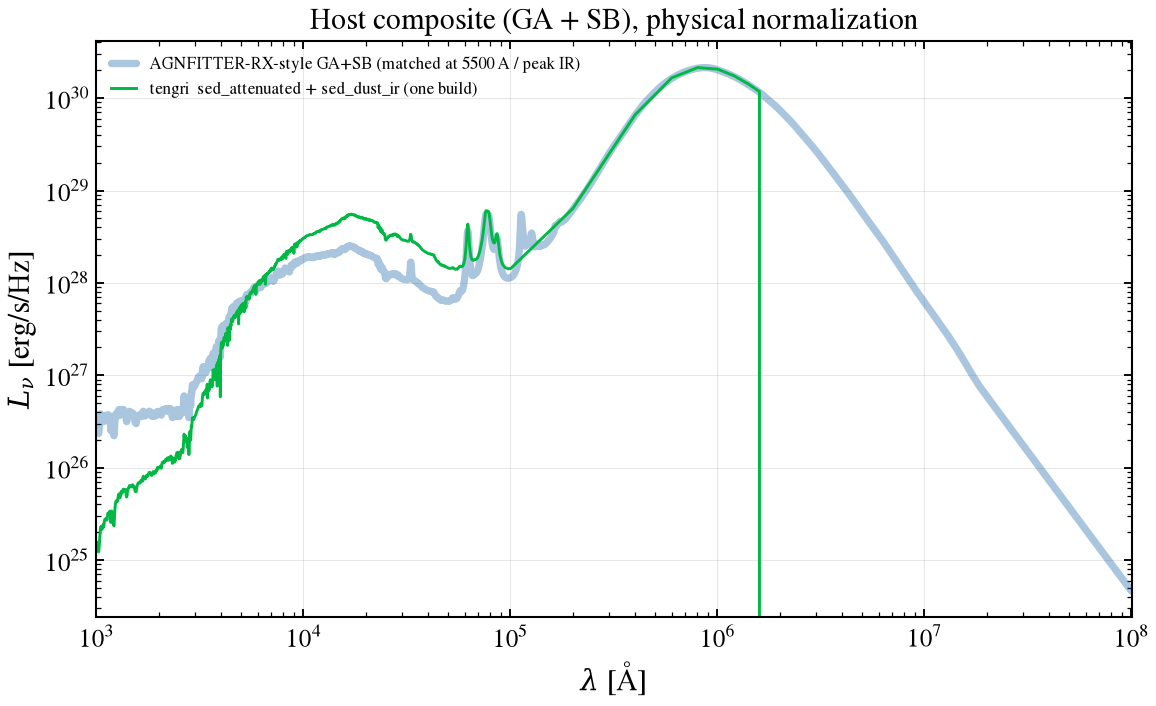

In [14]:
m7 = SEDModel.build(
    ssp_data=ssp, sfh=SFH_FIDUCIAL,
    dust_attenuation={"type": "single_component", "law": "calzetti", "dust_tau_v": Fixed(_tau_v_gal),
                       "all_params": Fixed(DEFAULT)},
    dust_emission={"type": "schreiber2018", "dust_T": Fixed(35.0), "dust_f_pah": Fixed(0.02),
                    "all_params": Fixed(DEFAULT)},
    neb={"type": "ssp"}, redshift=Fixed(0.0),
)
pred7 = m7.predict({})
w7 = np.asarray(pred7.sed.components["wavelength"])
host_sed = np.asarray(pred7.sed.components["sed_attenuated"]) + np.asarray(pred7.sed.components["sed_dust_ir"])
_log_lir7 = float(np.log10(pred7.l_tir))
_dh_node7 = float(_dh_axis[int(np.argmin(np.abs(_dh_axis - _log_lir7)))])

w_ga, L_ga = A.galaxy_template(tau=TAU_GYR, age=AGE_GYR * 1e9)
w_sb, L_sb = A.cold_dust_template("S17", tdust=35.0, fpah=0.02)
_ga_scaled = norm_at(w_ga, L_ga, 5500.0) * float(np.interp(5500.0, w7, np.asarray(pred7.sed.components["sed_attenuated"])))
_sb_peak_te = float(np.max(np.asarray(pred7.sed.components["sed_dust_ir"])))
_sb_scaled = norm_peak(L_sb) * _sb_peak_te
af_grid = np.geomspace(1e3, 1e8, 3000)
af_host = U.regrid(w_ga, np.clip(_ga_scaled, 0, None), af_grid) + U.regrid(w_sb, np.clip(_sb_scaled, 0, None), af_grid)
te_host_on_grid = U.regrid(w7, np.clip(host_sed, 0, None), af_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(af_grid, af_host, "C0-", lw=3.5, alpha=0.35, solid_capstyle="round", label="AGNFITTER-RX-style GA+SB (matched at 5500 A / peak IR)")
ax.loglog(af_grid, te_host_on_grid, "C1-", lw=1.4, label="tengri  sed_attenuated + sed_dust_ir (one build)")
ax.set_xlim(1e3, 1e8)
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
ax.set_title("Host composite (GA + SB), physical normalization")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_07_host_composite.png")

print(
    f"§7  tengri host: pred.l_tir = {pred7.l_tir:.3e} Lsun (log10={_log_lir7:.3f}); "
    f"pred.sfh.stellar_mass = {pred7.sfh.stellar_mass:.3e} Msun, "
    f"stellar_mass_surviving = {pred7.sfh.stellar_mass_surviving:.3e} Msun "
    f"(surviving/formed = {float(pred7.sfh.stellar_mass_surviving / pred7.sfh.stellar_mass):.3f})"
)
print(
    "§7  GA<->M* worked conversion table:  M*_formed -> M*_surviving via "
    "pred.sfh.stellar_mass_surviving (public property; DSPS return-fraction, "
    "not an independent tengri parameter)."
)
print(
    "    | quantity                     | value                    |\n"
    f"    | log10(M*_formed [Msun])      | {np.log10(pred7.sfh.stellar_mass):.3f}                    |\n"
    f"    | log10(M*_surviving [Msun])   | {np.log10(pred7.sfh.stellar_mass_surviving):.3f}                    |\n"
    f"    | log10(L_TIR [Lsun])          | {_log_lir7:.3f}                    |"
)
print(
    "§7  Normalization-philosophy difference: tengri's host is mass- and "
    "energy-balance-normalized end to end inside one build; AGNfitter-RX's "
    "GA/SB pickle units are resolved only by its own fitter's per-component "
    "scale factors, not by the driver read here — the comparison above is "
    "matched at one anchor per component (5500 A, IR peak), not absolute."
)

## §8 Host nebular emission

AGNfitter-rX's GALAXY component carries no host nebular-emission term (no
emission lines, no nebular continuum); the SSP grid used throughout this
reproduction carries baked-in nebular lines at a fixed ionization
parameter instead, and every build states that choice explicitly with
`neb={'type': 'ssp'}`.

## §9a Accretion-disk library face-off

Four AGNfitter-rX disk libraries at matched parameters, unreddened and
normalized at 2500 Å, plus tengri's grid-tabulated KD18 discs (Task 5).
The decisive feature is the 0.7 μm bump (Hα + [N II]): present only in the
semi-empirical THB21, absent from theory discs R06/SN12/KD18.

* **THB21** — `qsogen` with its `blr`/`feii` blocks (`tengri_qsogen_full`);
  the continuum alone misses the line forest entirely.
* **SN12** (Slone & Netzer 2012) — `slone_netzer`, node-exact bilinear
  interpolation of the 108-template grid.
* **KD18** (Kubota & Done 2018) — tengri's `kd18_agnfitter` block is
  **grid-tabulated** directly on AGNfitter-rX's own `(log M_BH, log
  λ_Edd)` axes (`agn_log_mbh`, `agn_log_ledd`), a node-exact match rather
  than a physical re-derivation. tengri's KD18-family discs (`kd18_agnfitter`,
  `kd18_agnfitter_warmindex`) intrinsically carry a hot corona, so any
  AGN-corona X-ray variant is refused when paired with them — the
  `ConfigError` text is shown as a Caveat below. `kd18_agnfitter_warmindex`
  adds a free warm-Comptonization index `agn_gamma_warm`; the two variants
  diverge by up to ~27% at fixed `(M_BH, λ_Edd)` for a warm index far from
  `kd18_agnfitter`'s baked-in default (measured below, not from memory).
* **R06** (Richards et al. 2006) — the same template on both sides;
  AGNfitter-RX stores it as `νL_ν`, tengri's `richards2006` returns `L_ν`
  directly, so the panel divides AGNfitter-RX's array by `ν` before
  overlaying.

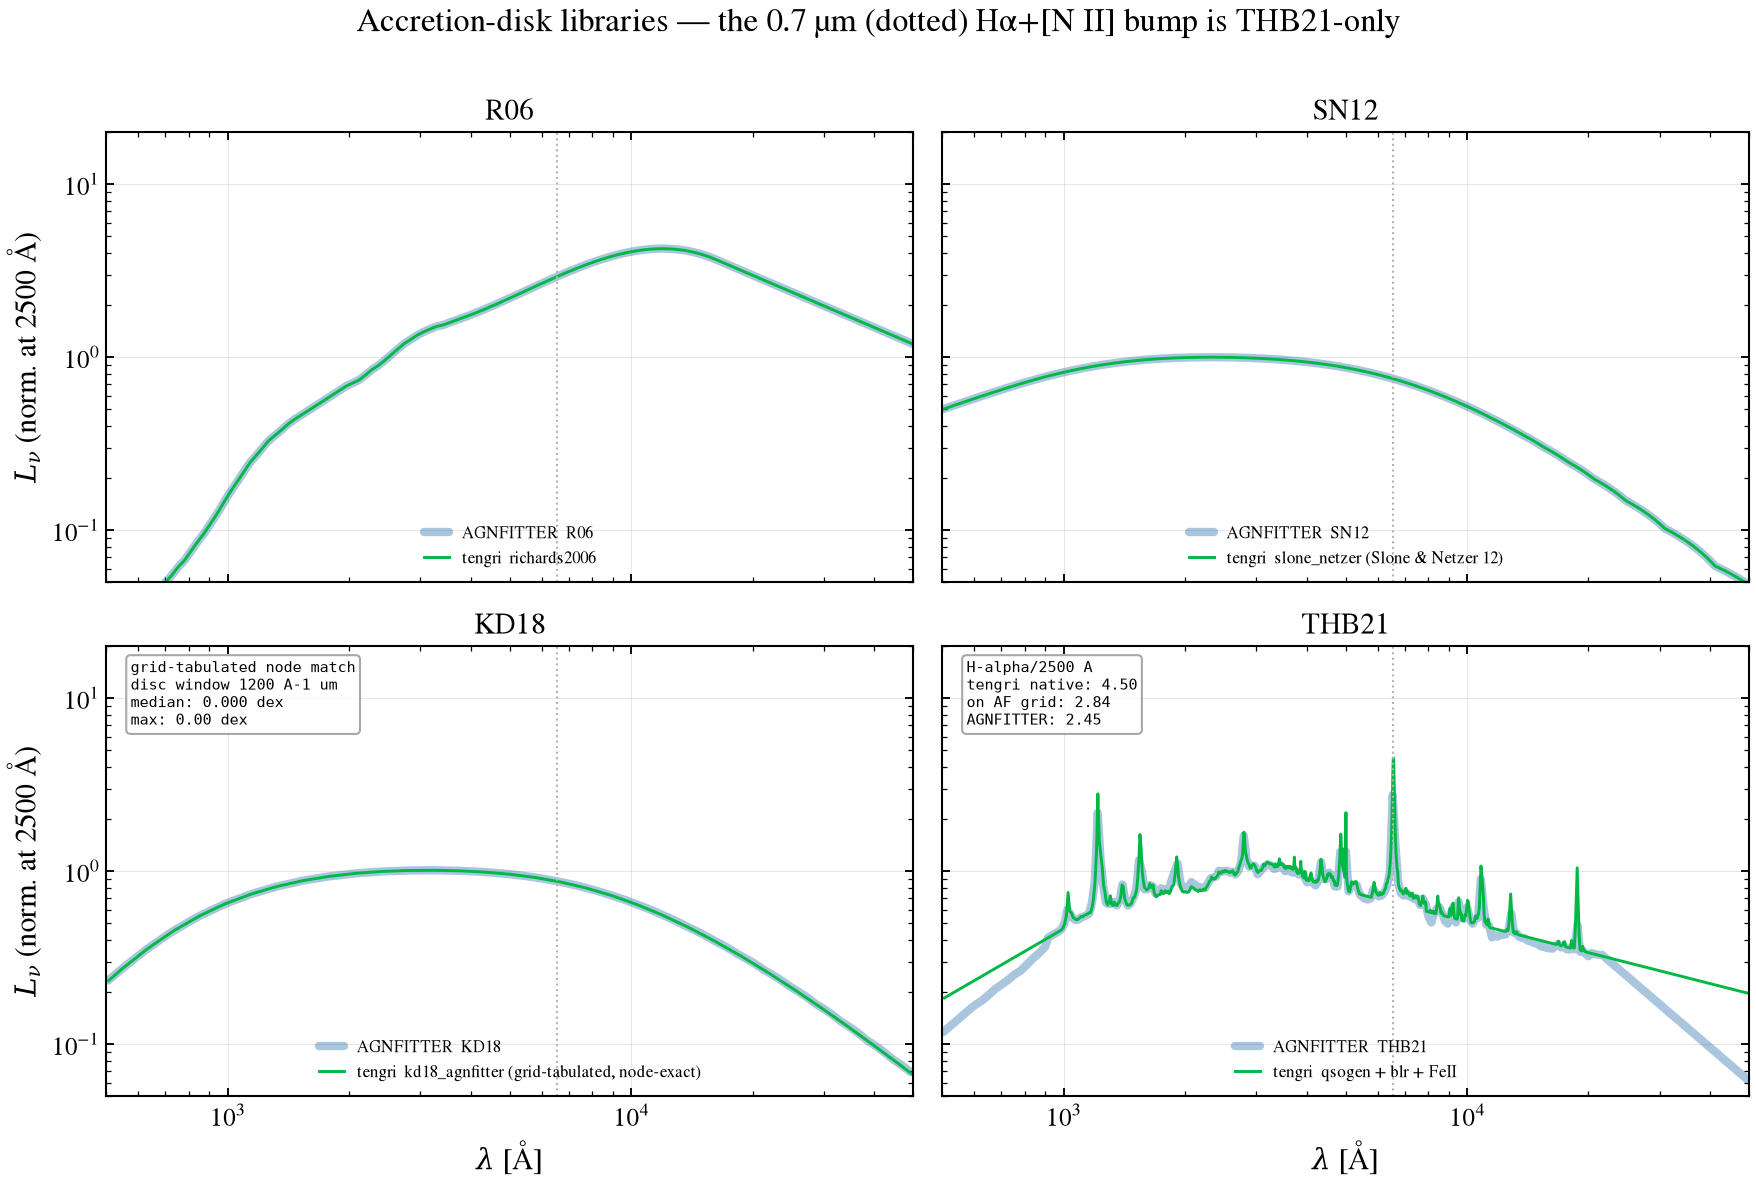

In [15]:
disk_pairs = [
    ("R06", {}, lambda: tengri_disc("richards2006"), "richards2006"),
    ("SN12", dict(log_mbh=8.6, edd_index=10),
     lambda: tengri_disc("slone_netzer", agn_log_mbh=8.6, agn_log_ledd=-2.0),
     "slone_netzer (Slone & Netzer 12)"),
    ("KD18", dict(log_mbh=8.0, log_edd=-0.75),
     lambda: tengri_disc("kd18_agnfitter", agn_log_mbh=8.0, agn_log_ledd=-0.75),
     "kd18_agnfitter (grid-tabulated, node-exact)"),
    ("THB21", {}, tengri_qsogen_full, "qsogen + blr + FeII"),
]


def _val_at(w, L, lam):
    o = np.argsort(np.asarray(w))
    return float(np.interp(lam, np.asarray(w)[o], np.asarray(L)[o]))


ANCHOR = 2500.0
_ANNOT = dict(transform=None, va="top", ha="left", fontsize=7, family="monospace",
              bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=0.85))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (af_name, af_kw, tengri_fn, tengri_label) in zip(axes.ravel(), disk_pairs):
    w_a, L_a = A.disk_template(af_name, **af_kw)
    if af_name == "R06":
        L_a = np.asarray(L_a) / (U.C_ANGSTROM_PER_S / np.asarray(w_a))
    a_norm = norm_at(w_a, L_a, ANCHOR)
    msk_a = (w_a > 5e2) & (w_a < 5e4)
    ax.loglog(w_a[msk_a], a_norm[msk_a], "C0-", lw=4.0, alpha=0.35, solid_capstyle="round", label=f"AGNFITTER  {af_name}")
    w_t, L_t = tengri_fn()
    t_norm = norm_at(w_t, L_t, ANCHOR)
    msk_t = (w_t > 5e2) & (w_t < 5e4)
    ax.loglog(w_t[msk_t], t_norm[msk_t], "C1-", lw=1.4, label=f"tengri  {tengri_label}")
    ax.axvline(6563, color="0.7", ls=":", lw=1)

    if af_name == "KD18":
        oa_, ot_ = np.argsort(w_a), np.argsort(w_t)
        w_a_s = np.asarray(w_a)[oa_]
        m = (w_a_s >= 1.2e3) & (w_a_s <= 1e4) & (a_norm[oa_] > 0)
        _t_on = np.interp(w_a_s[m], np.asarray(w_t)[ot_], t_norm[ot_])
        _lr = np.abs(np.log10(_t_on / a_norm[oa_][m]))
        ax.text(0.03, 0.97,
                f"grid-tabulated node match\ndisc window 1200 A-1 um\nmedian: {np.median(_lr):.3f} dex\nmax: {_lr.max():.2f} dex",
                **{**_ANNOT, "transform": ax.transAxes})
    if af_name == "THB21":
        _ot = np.argsort(np.asarray(w_t))
        _t_on_af = np.interp(np.asarray(w_a), np.asarray(w_t)[_ot], np.asarray(t_norm)[_ot])
        ax.text(0.03, 0.97,
                f"H-alpha/2500 A\ntengri native: {_val_at(w_t, t_norm, 6563):.2f}\non AF grid: {_val_at(w_a, _t_on_af, 6563):.2f}\nAGNFITTER: {_val_at(w_a, a_norm, 6563):.2f}",
                **{**_ANNOT, "transform": ax.transAxes})
    ax.set_xlim(5e2, 5e4)
    ax.set_ylim(0.05, 20)
    ax.set_title(af_name)
    ax.legend(fontsize=8, loc="lower center")
    ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel(r"$\lambda$ [Å]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$L_\nu$ (norm. at 2500 Å)")
fig.suptitle("Accretion-disk libraries — the 0.7 µm (dotted) Hα+[N II] bump is THB21-only", y=1.0)
fig.tight_layout()
save_fig("agnfitter_09a_disc_library.png")

In [16]:
print("§9a  disc-library shape residuals (anchor 2500 Å, 1200 Å-1 um):")
for af_name, af_kw, tengri_fn, _label in disk_pairs:
    w_a, L_a = A.disk_template(af_name, **af_kw)
    if af_name == "R06":
        L_a = np.asarray(L_a) / (U.C_ANGSTROM_PER_S / np.asarray(w_a))
    w_t, L_t = tengri_fn()
    oa_, ot_ = np.argsort(w_a), np.argsort(w_t)
    w_a_s, a_s = np.asarray(w_a)[oa_], norm_at(w_a, L_a, ANCHOR)[oa_]
    m = (w_a_s >= 1.2e3) & (w_a_s <= 1e4) & (a_s > 0)
    t_on = np.interp(w_a_s[m], np.asarray(w_t)[ot_], norm_at(w_t, L_t, ANCHOR)[ot_])
    logr = np.abs(np.log10(t_on / a_s[m]))
    print(f"  {af_name:6s} median = {np.median(logr):.3f} dex   max = {logr.max():.3f} dex")

§9a  disc-library shape residuals (anchor 2500 Å, 1200 Å-1 um):
  R06    median = 0.000 dex   max = 0.000 dex
  SN12   median = 0.000 dex   max = 0.000 dex
  KD18   median = 0.000 dex   max = 0.002 dex
  THB21  median = 0.012 dex   max = 0.150 dex


In [17]:
# KD18 grid-tabulated vs warm-index variant, at fixed (M_BH, lambda_Edd),
# far warm index vs kd18_agnfitter's baked-in default.
w_kd, L_kd = tengri_disc("kd18_agnfitter", agn_log_mbh=8.0, agn_log_ledd=-0.75)
resolved_params(tengri_disc.last_model)
w_kdw, L_kdw = tengri_disc("kd18_agnfitter_warmindex", agn_log_mbh=8.0, agn_log_ledd=-0.75, agn_gamma_warm=1.5)
_m = (w_kd > 1.2e3) & (w_kd < 1e4)
_kdn = norm_at(w_kd, L_kd, ANCHOR)
_kdwn_on = np.interp(w_kd, w_kdw, norm_at(w_kdw, L_kdw, ANCHOR))
_kd_logr = np.abs(np.log10(np.clip(_kdwn_on[_m], 1e-30, None) / np.clip(_kdn[_m], 1e-30, None)))
print(
    f"§9a  kd18_agnfitter vs kd18_agnfitter_warmindex (gamma_warm=1.5) at "
    f"(log M_BH, log lambda_Edd)=(8.0, -0.75): max|log10 ratio| = {_kd_logr.max():.3f} dex "
    f"(={100 * (10 ** _kd_logr.max() - 1):.0f}%)"
)

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 110 fixed
  Modules:     nebular=ssp, agn=composable[disc=kd18_agnfitter, torus=none, norm=independent]

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  agn_T_hot                        Fixed                      1200                   [all_params Fixed(DEFAULT)]
  agn_T_max                        Fixed                      1e+05                  [all_params Fixed(DEFAULT)]
  agn_T_torus                      Fixed                      1000                   [all_params Fixed(DEFAULT)]
  agn_T_warm                       Fixed                      300                    [all_params Fixed(DEFAULT)]
  agn_a_cat3d                      Fixed  

§9a  kd18_agnfitter vs kd18_agnfitter_warmindex (gamma_warm=1.5) at (log M_BH, log lambda_Edd)=(8.0, -0.75): max|log10 ratio| = 0.022 dex (=5%)


In [18]:
print("§9a  disc composable menu (tengri.registry.list_agn_blocks(), category='disc'):")
_disc_rows = [r for r in tengri.list_agn_blocks() if r.get("category") == "disc"]
print(f"    {len(_disc_rows)} disc blocks registered")

§9a  disc composable menu (tengri.registry.list_agn_blocks(), category='disc'):
    16 disc blocks registered


## §9a′ KD18 grid discs and the corona double-count guard

`kd18_agnfitter` (and `kd18_agnfitter_warmindex`) already carry a
Kubota & Done (2018) hot corona; asking for an *additional* AGN-corona
X-ray variant (e.g. `xray={'type': 'yang20'}`) is refused at build time by
`check_disc_xray_double_count`, pinned by
`tests/contract/test_disc_xray_double_count.py::test_kd18_agnfitter_plus_corona_raises`.

**Caveat:** the guard's message, verbatim (quoted from that test's fixture,
not executed here — a build that is known to raise is not run):

> `disc 'kd18_agnfitter' already carries a hot corona; xray={'type': 'yang20'}`
> `would add a second α_ox corona (+51% over 0.5-10 keV). Set xray={'type':`
> `'none'} or choose a disc without intrinsic X-rays.`

Every KD18 panel in this notebook therefore pairs `kd18_agnfitter[_warmindex]`
with `xray={'type': 'none'}`.

## §9b Accretion-disk reddening sweep

The disk color excess `E(B−V)_BBB` sweeps the UV continuum via the Prevot
SMC law on both sides. tengri's dashed curves sit **below** AGNfitter-RX's
solid ones at matched `E(B−V)` — the §4 convention, 1.102× more extinction
under the more physical `R_V`.

§9b  A(1500 Å) per E(B-V) [mag]:
  E(B-V)=0.1:  AGNFITTER = 1.32   tengri = 1.45   (ratio 1.102, convention 1.102)


  E(B-V)=0.3:  AGNFITTER = 3.95   tengri = 4.35   (ratio 1.102, convention 1.102)
  E(B-V)=0.5:  AGNFITTER = 6.58   tengri = 7.25   (ratio 1.102, convention 1.102)


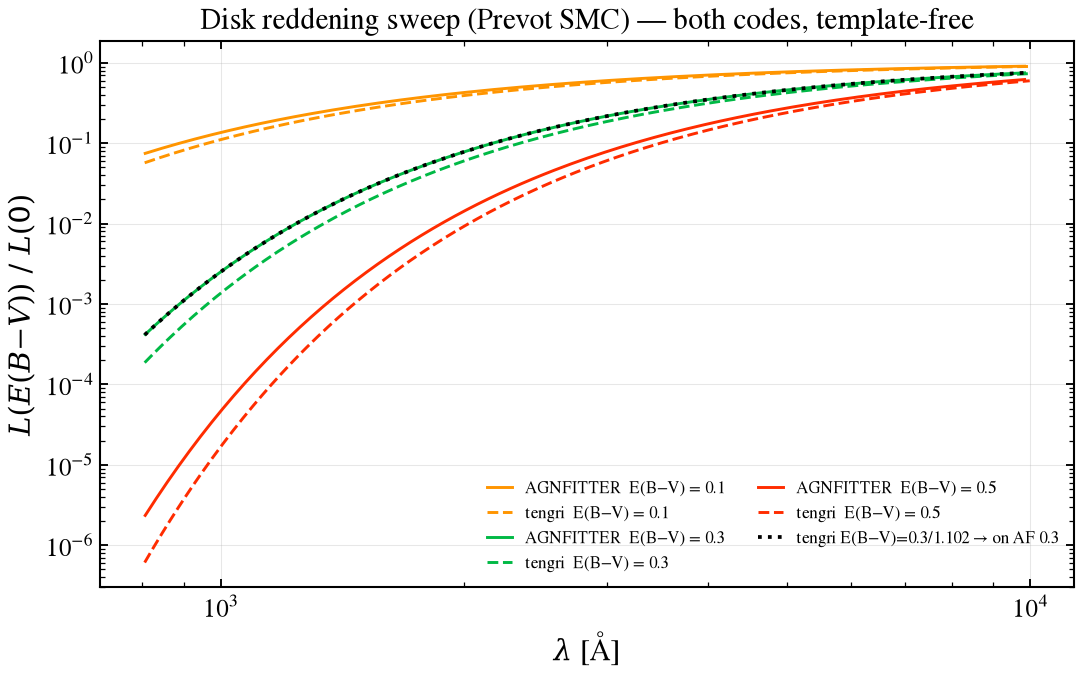

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
w_thb, L_thb = A.disk_template("THB21")
_, L_te0 = tengri_disc("qsogen", ebv_disc=0.0)
msk = (w_thb > 8e2) & (w_thb < 1e4)
print("§9b  A(1500 Å) per E(B-V) [mag]:")
for ebv, c in [(0.1, "C2"), (0.3, "C1"), (0.5, "C3")]:
    L_red = A.apply_bbb_reddening(w_thb, L_thb, ebv)
    ratio_af = np.divide(L_red, L_thb, out=np.ones_like(L_red), where=L_thb > 0)
    ax.loglog(w_thb[msk], ratio_af[msk], c, ls="-", lw=1.4, label=f"AGNFITTER  E(B−V) = {ebv:g}")
    w_te, L_te = tengri_disc("qsogen", ebv_disc=ebv)
    ratio_te = np.divide(L_te, L_te0, out=np.ones_like(L_te), where=L_te0 > 0)
    msk_te = (w_te > 8e2) & (w_te < 1e4)
    ax.loglog(w_te[msk_te], ratio_te[msk_te], c, ls="--", lw=1.4, label=f"tengri  E(B−V) = {ebv:g}")
    a_af = -2.5 * np.log10(np.interp(1500.0, w_thb, ratio_af))
    a_te = -2.5 * np.log10(np.interp(1500.0, w_te, ratio_te))
    print(f"  E(B-V)={ebv:g}:  AGNFITTER = {a_af:.2f}   tengri = {a_te:.2f}   (ratio {a_te / a_af:.3f}, convention 1.102)")
w_tm, L_tm = tengri_disc("qsogen", ebv_disc=0.3 / 1.102)
ratio_tm = np.divide(L_tm, L_te0, out=np.ones_like(L_tm), where=L_te0 > 0)
msk_tm = (w_tm > 8e2) & (w_tm < 1e4)
ax.loglog(w_tm[msk_tm], ratio_tm[msk_tm], "k:", lw=1.8, label="tengri E(B−V)=0.3/1.102 → on AF 0.3")
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$L(E(B{-}V))\ /\ L(0)$")
ax.set_title("Disk reddening sweep (Prevot SMC) — both codes, template-free")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_09b_bbb_reddening.png")

## §9c Torus library face-off

Four headline AGNfitter-rX torus libraries at matched grid nodes,
peak-normalized, plus a parity table across five further averaged
reductions of the same NK08/SKIRTOR/CAT3D families, read through
`torus_template`/`torus_axes`. **S04** — `silva04` at log
N_H=23. **NK08** — `nenkova_agnfitter` (the inclination-averaged
`NK0_mean_1p` CLUMPY reduction) at incl 30°. **SKIRTOR** — `skirtor`
(full X-CIGALE grid) at oa 40°, incl 30°, τ 7 (AGNfitter-rX's own
`SKIRTOR_mean_3p` reduction is `skirtor_agnfitter`; see §9c′). **CAT3D-Wind**
— `cat3d_wind` at incl 0°, a=−2, f_wd=1.75.

**Verification Status:** CROSSVAL — SKIRTOR torus (mean 3-param)

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 110 fixed
  Modules:     nebular=ssp, agn=composable[disc=none, torus=silva04, norm=independent]

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  agn_T_hot                        Fixed                      1200                   [all_params Fixed(DEFAULT)]
  agn_T_max                        Fixed                      1e+05                  [all_params Fixed(DEFAULT)]
  agn_T_torus                      Fixed                      1000                   [all_params Fixed(DEFAULT)]
  agn_T_warm                       Fixed                      300                    [all_params Fixed(DEFAULT)]
  agn_a_cat3d                      Fixed         

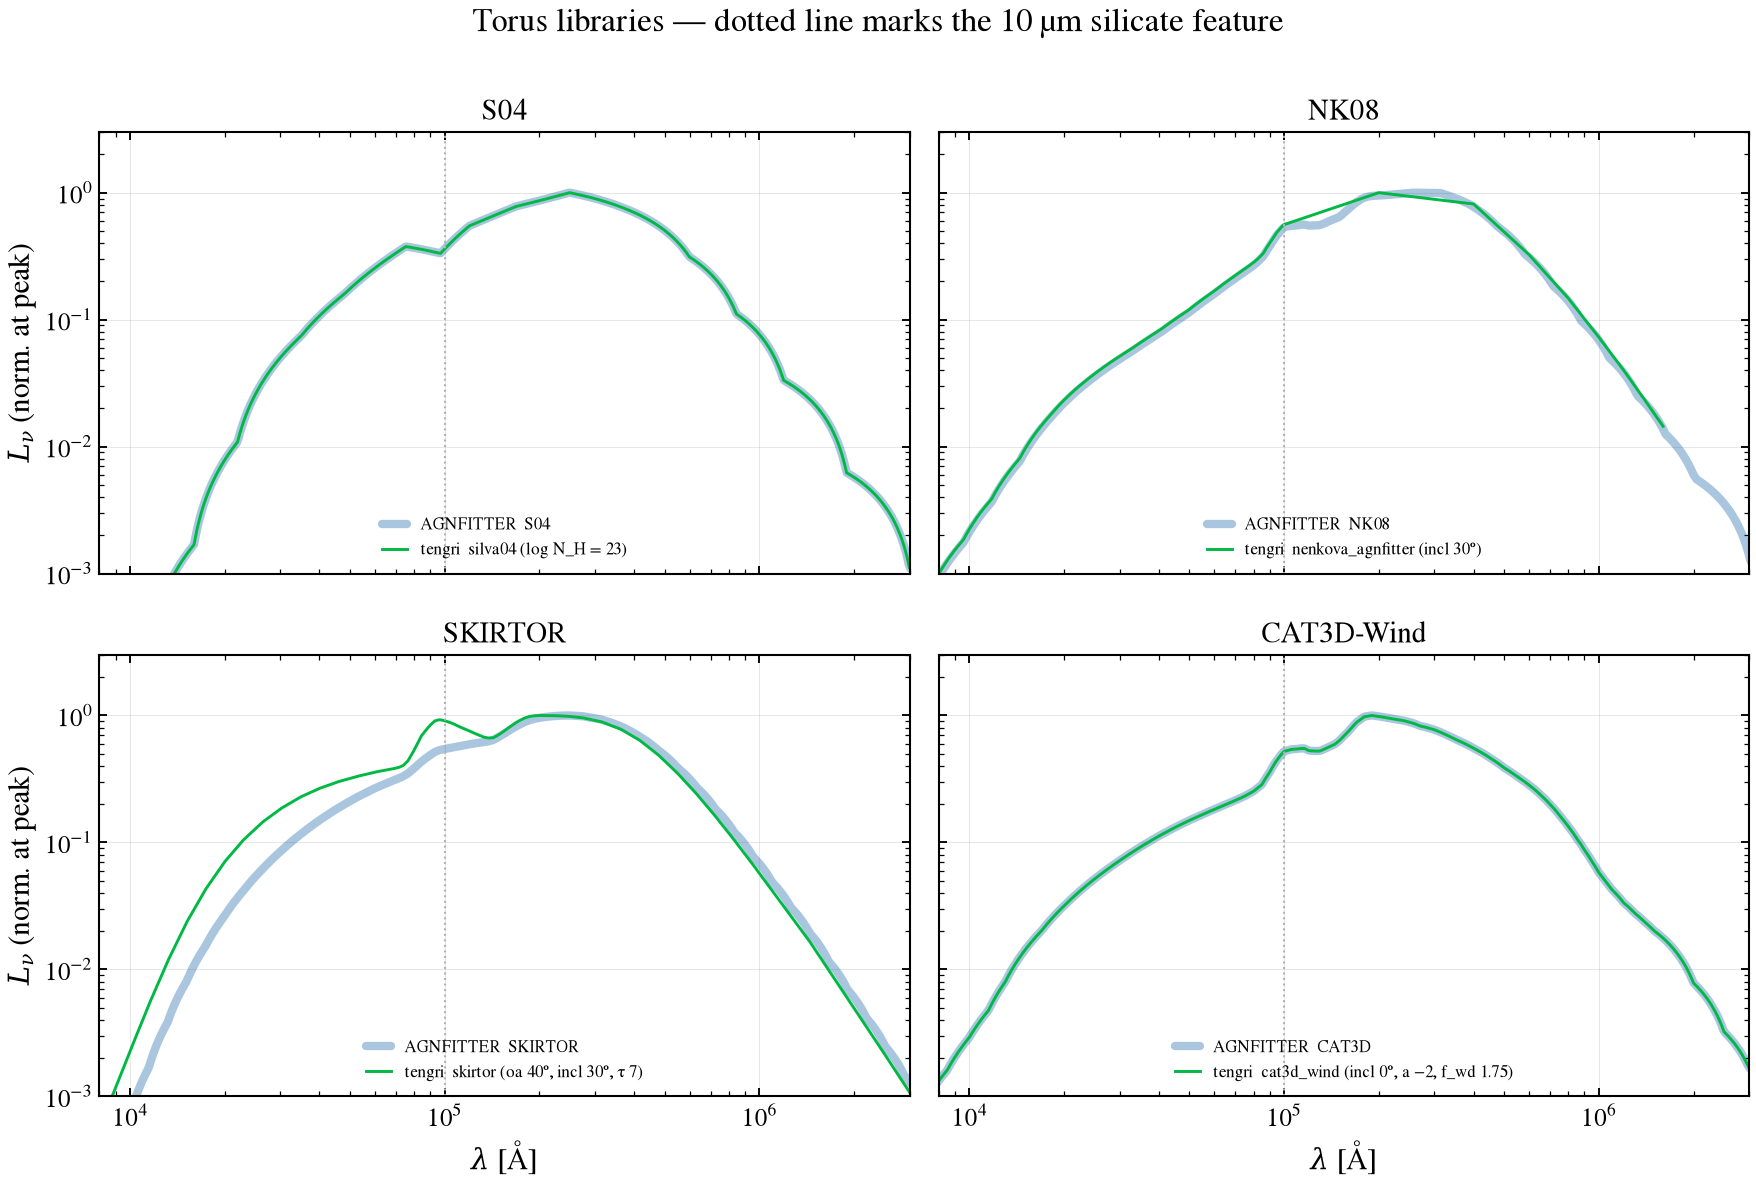

In [20]:
torus_pairs = [
    ("S04", "S04", lambda: tengri_torus("silva04", log_nh_silva=23.0), "silva04 (log N_H = 23)", dict(log_nh=23.0)),
    ("NK08", "NK08", lambda: tengri_torus("nenkova_agnfitter", cos_inc=0.8660254), "nenkova_agnfitter (incl 30°)", dict(incl=30.0)),
    ("SKIRTOR", "SKIRTOR", lambda: tengri_torus("skirtor", cos_inc=0.8660254, oa_skirtor=40.0, tau_skirtor=7.0), "skirtor (oa 40°, incl 30°, τ 7)", dict(oa=40.0, incl=30.0, tau=7.0)),
    ("CAT3D", "CAT3D-Wind", lambda: tengri_torus("cat3d_wind", cos_inc=1.0, a_cat3d=-2.0, fwd_cat3d=1.75), "cat3d_wind (incl 0°, a −2, f_wd 1.75)", dict(incl=0.0, a=-2.0, fwd=1.75)),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
_printed_torus_params = False
for ax, (af_name, title, tengri_fn, tengri_label, af_kw) in zip(axes.ravel(), torus_pairs):
    w_a, L_a = A.torus_template(af_name, **af_kw)
    msk_a = (w_a > 5e3) & (w_a < 1e7)
    ax.loglog(w_a[msk_a], norm_peak(L_a)[msk_a], "C0-", lw=4.0, alpha=0.35, solid_capstyle="round", label=f"AGNFITTER  {af_name}")
    w_t, L_t = tengri_fn()
    if not _printed_torus_params:
        resolved_params(tengri_torus.last_model)
        _printed_torus_params = True
    msk_t = (w_t > 5e3) & (w_t < 1e7)
    ax.loglog(w_t[msk_t], norm_peak(L_t)[msk_t], "C1-", lw=1.4, label=f"tengri  {tengri_label}")
    ax.axvline(1e5, color="0.7", ls=":", lw=1)
    ax.set_xlim(8e3, 3e6)
    ax.set_ylim(1e-3, 3)
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower center")
    ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel(r"$\lambda$ [Å]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$L_\nu$ (norm. at peak)")
fig.suptitle("Torus libraries — dotted line marks the 10 µm silicate feature", y=1.0)
fig.tight_layout()
save_fig("agnfitter_09c_torus_library.png")

### §9c′ Five further torus reductions (Task 4)

`nenkova_agnfitter_2p`/`_3p` (NK08 with the opening-angle, then also
optical-depth, axes retained), `skirtor_agnfitter_1p`/`_2p` (SKIRTOR
averaged over fewer axes than the headline `skirtor_agnfitter` 3p
reduction), and `cat3d_wind_lowfwd` (CAT3D's complementary low-wind-fraction
sub-library) — each built once against the driver's matching
`torus_axes(reduction)` node, peak-normalized.

§9c′  torus composable menu (tengri.registry.list_agn_blocks(), category='torus'):
    17 torus blocks registered
§9c′  five reductions: axes x node counts (tengri torus_axes) vs upstream row count:
    NK08_2P          axes={'incl': 10, 'oa': 12}  upstream rows = product = 120
    NK08_3P          axes={'incl': 10, 'oa': 12, 'tau': 9}  upstream rows = product = 1080
    SKIRTOR_MEAN1P   axes={'incl': 10}  upstream rows = product = 10
    SKIRTOR_MEAN2P   axes={'oa': 8, 'incl': 10}  upstream rows = product = 80
    CAT3D_LOWFWD     axes={'incl': 7, 'a': 6, 'fwd': 5}  upstream rows = product = 210
§9c′  torus-reduction parity (peak-normalized, 1-100 um median|log10 ratio|):


    NK08_2P          node={'incl': 30.0, 'oa': 40.0}  median = 0.020 dex


    NK08_3P          node={'incl': 30.0, 'oa': 40.0, 'tau': 60.0}  median = 0.033 dex


    SKIRTOR_MEAN1P   node={'incl': 30.0}  median = 0.012 dex


    SKIRTOR_MEAN2P   node={'oa': 40.0, 'incl': 30.0}  median = 0.010 dex


    CAT3D_LOWFWD     node={'incl': 0.0, 'a': -2.0, 'fwd': 0.3}  median = 0.018 dex


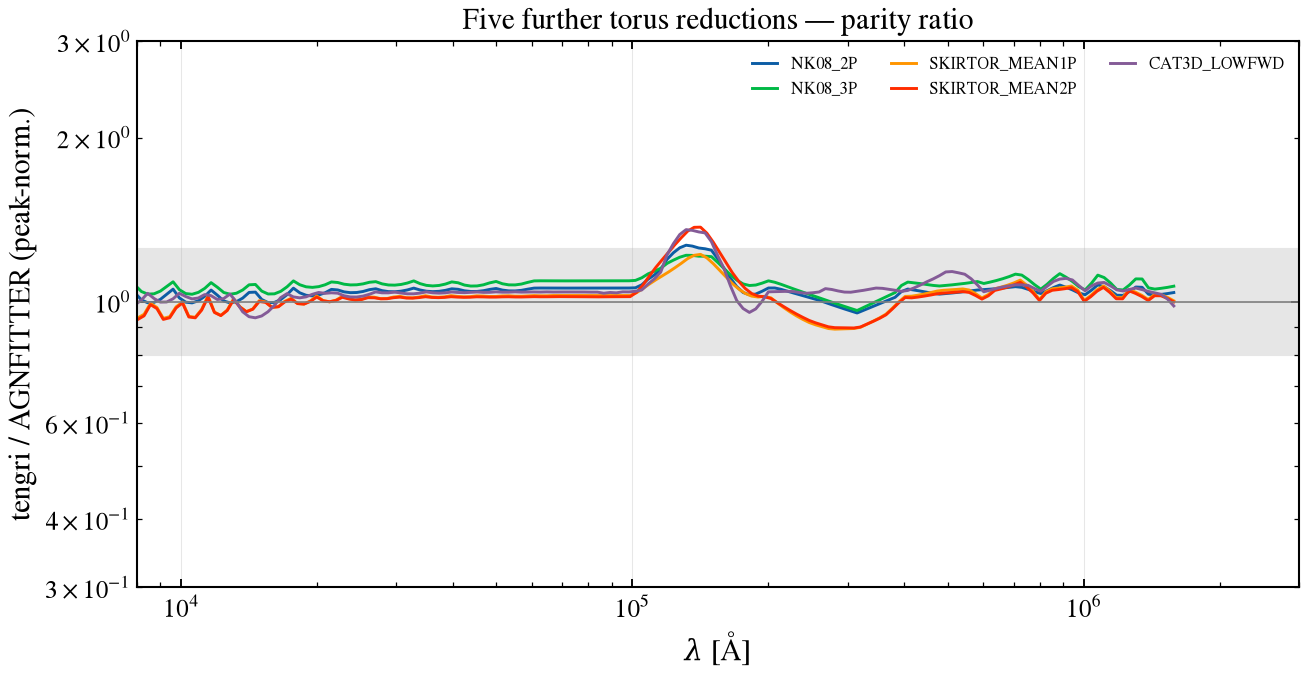

In [21]:
print("§9c′  torus composable menu (tengri.registry.list_agn_blocks(), category='torus'):")
_torus_rows = [r for r in tengri.list_agn_blocks() if r.get("category") == "torus"]
print(f"    {len(_torus_rows)} torus blocks registered")

print("§9c′  five reductions: axes x node counts (tengri torus_axes) vs upstream row count:")
for _name in ("NK08_2P", "NK08_3P", "SKIRTOR_MEAN1P", "SKIRTOR_MEAN2P", "CAT3D_LOWFWD"):
    _axes = A.torus_axes(_name)
    _sizes = {k: len(v) for k, v in _axes.items()}
    _n_rows = int(np.prod(list(_sizes.values())))
    print(f"    {_name:16s} axes={_sizes}  upstream rows = product = {_n_rows}")

_reduction_pairs = [
    ("NK08_2P", lambda incl, oa: tengri_torus("nenkova_agnfitter_2p", agn_cos_inc=np.cos(np.deg2rad(incl)), agn_oa_nenkova=oa), dict(incl=30.0, oa=40.0)),
    ("NK08_3P", lambda incl, oa, tau: tengri_torus("nenkova_agnfitter_3p", agn_cos_inc=np.cos(np.deg2rad(incl)), agn_oa_nenkova=oa, agn_tv_nenkova=tau), dict(incl=30.0, oa=40.0, tau=60.0)),
    ("SKIRTOR_MEAN1P", lambda incl: tengri_torus("skirtor_agnfitter_1p", agn_incl_skirtor=incl), dict(incl=30.0)),
    ("SKIRTOR_MEAN2P", lambda oa, incl: tengri_torus("skirtor_agnfitter_2p", agn_oa_skirtor=oa, agn_incl_skirtor=incl), dict(oa=40.0, incl=30.0)),
    ("CAT3D_LOWFWD", lambda incl, a, fwd: tengri_torus("cat3d_wind_lowfwd", agn_cos_inc=np.cos(np.deg2rad(incl)), agn_a_cat3d_lowfwd=a, agn_fwd_cat3d_lowfwd=fwd), dict(incl=0.0, a=-2.0, fwd=0.3)),
]
print("§9c′  torus-reduction parity (peak-normalized, 1-100 um median|log10 ratio|):")
fig, ax = plt.subplots(figsize=(9, 4.8))
for (name, fn, kw), c in zip(_reduction_pairs, ["C0", "C1", "C2", "C3", "C4"]):
    w_a, L_a = A.torus_template(name, **kw)
    w_t, L_t = fn(**kw)
    _grid = np.geomspace(max(w_a.min(), w_t.min()) * 1.01, min(w_a.max(), w_t.max()) * 0.99, 300)
    a_on = np.interp(np.log10(_grid), np.log10(np.sort(w_a)), norm_peak(L_a)[np.argsort(w_a)])
    t_on = np.interp(np.log10(_grid), np.log10(np.sort(w_t)), norm_peak(L_t)[np.argsort(w_t)])
    ratio = t_on / np.clip(a_on, 1e-30, None)
    ax.loglog(_grid, ratio, c, lw=1.4, label=name)
    m_ir = (_grid > 1e4) & (_grid < 1e6) & (a_on > 1e-3)
    print(f"    {name:16s} node={kw}  median = {np.median(np.abs(np.log10(ratio[m_ir]))):.3f} dex")
ax.axhspan(0.8, 1.25, color="0.9", zorder=0)
ax.axhline(1.0, color="0.5", lw=0.8)
ax.set_xlim(8e3, 3e6)
ax.set_ylim(0.3, 3.0)
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel("tengri / AGNFITTER (peak-norm.)")
ax.set_title("Five further torus reductions — parity ratio")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_09c1_reductions.png")

### §9c″ Torus-library parity — full-spectrum shape ratio

The tengri / AGNfitter-rX peak-normalized shape ratio for each headline
torus library, with the 1–100 μm median printed below.

§9c  headline torus-library full-spectrum shape parity (tengri / AGNFITTER, peak-norm):
  S04         : median (1-100 µm) = 0.998×
  NK08        : median (1-100 µm) = 1.053×
  SKIRTOR     : median (1-100 µm) = 1.268×
  CAT3D-Wind  : median (1-100 µm) = 0.998×


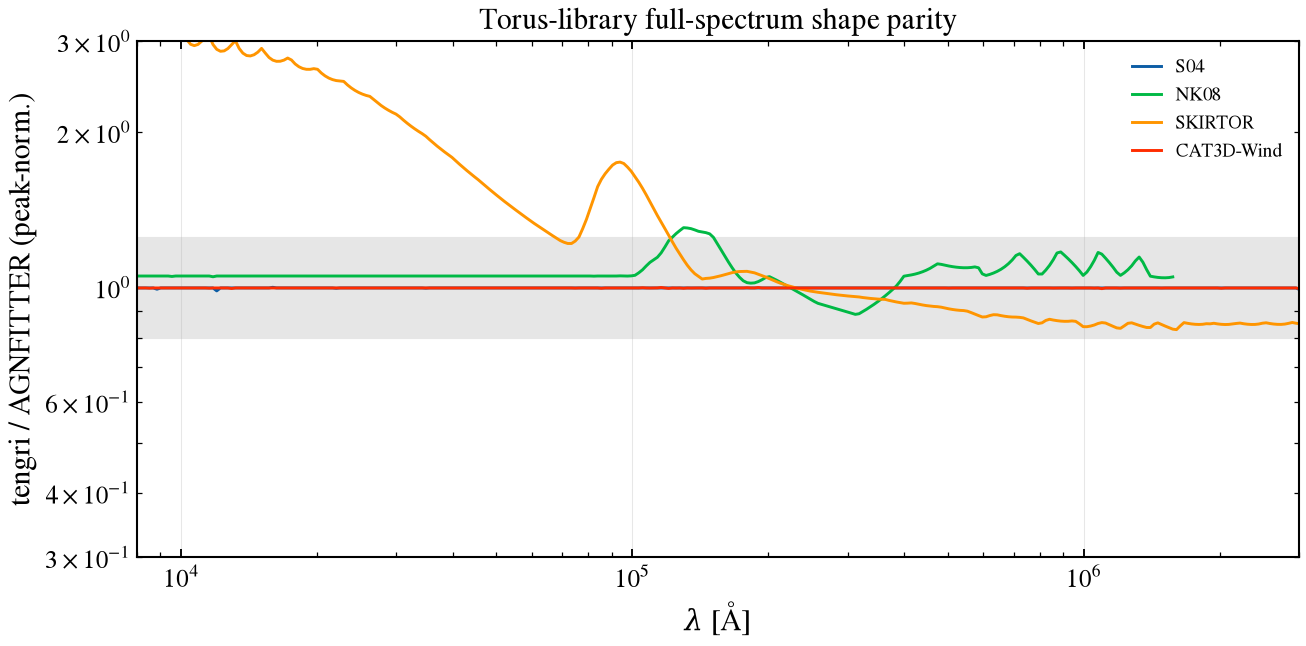

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axhspan(0.8, 1.25, color="0.9", zorder=0)
ax.axhline(1.0, color="0.5", lw=0.8)
_ratio_grid = np.geomspace(5e3, 1e7, 400)
print("§9c  headline torus-library full-spectrum shape parity (tengri / AGNFITTER, peak-norm):")
for (af_name, _title, tengri_fn, _tlabel, af_kw), _c in zip(torus_pairs, ["C0", "C1", "C2", "C3"]):
    w_a, L_a = A.torus_template(af_name, **af_kw)
    w_t, L_t = tengri_fn()
    a_on = np.interp(np.log10(_ratio_grid), np.log10(w_a), norm_peak(L_a), left=np.nan, right=np.nan)
    t_on = np.interp(np.log10(_ratio_grid), np.log10(w_t), norm_peak(L_t), left=np.nan, right=np.nan)
    _ratio = t_on / a_on
    ax.loglog(_ratio_grid, _ratio, _c, lw=1.4, label=_title)
    _m = (_ratio_grid > 1e4) & (_ratio_grid < 1e6) & np.isfinite(_ratio) & (a_on > 1e-3)
    if _m.any():
        print(f"  {_title:12s}: median (1-100 µm) = {float(np.nanmedian(_ratio[_m])):.3f}×")
ax.set_xlim(8e3, 3e6)
ax.set_ylim(0.3, 3.0)
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel("tengri / AGNFITTER (peak-norm.)")
ax.set_title("Torus-library full-spectrum shape parity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_09c2_torus_ratio.png")
plt.show()

### §9c‴ SKIRTOR: two reductions

`skirtor_agnfitter` (node-exact match to AGNfitter-RX's averaged
`SKIRTOR_mean_3p`) vs `skirtor` (the full unaveraged X-CIGALE grid).
`skirtor` carries the unaveraged clumpiness and radial-distribution
structure, which broadens and shifts its IR peak; the panel measures
*where* that peak sits on each side rather than assuming a direction.

§9c‴  IR peak wavelength: AGNFITTER SKIRTOR_mean_3p = 24.7 um, tengri skirtor_agnfitter (node-exact) = 20.0 um, tengri skirtor (full grid) = 19.9 um


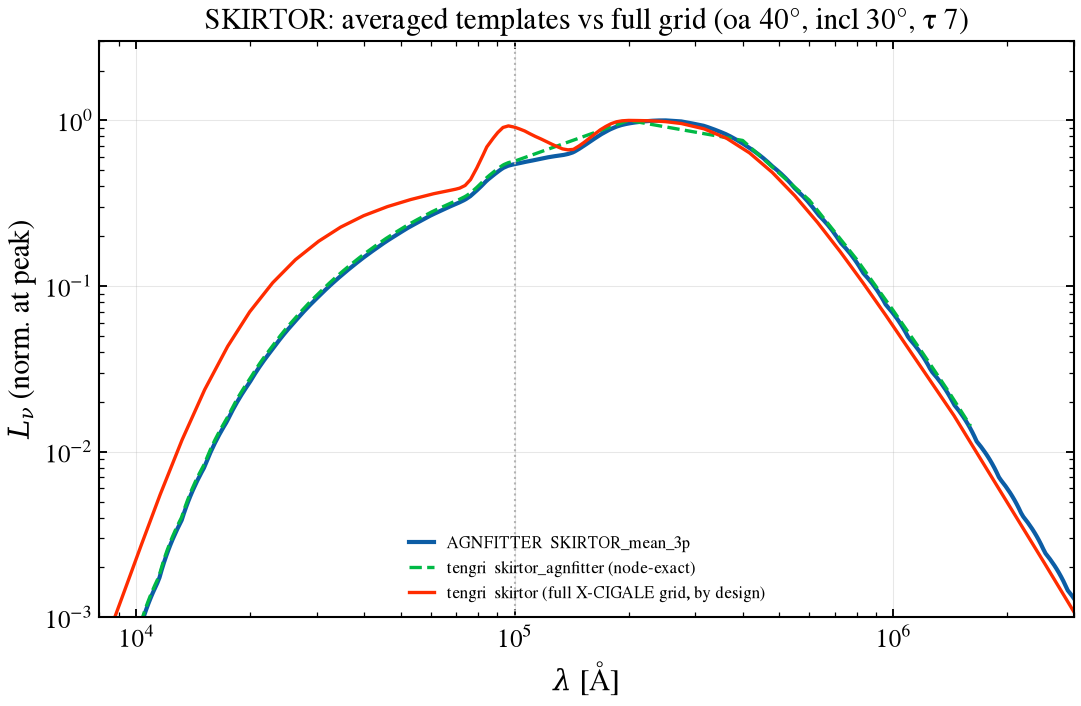

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 5))
w_ref, L_ref = A.torus_template("SKIRTOR", oa=40.0, incl=30.0, tau=7.0)
msk_ref = (w_ref > 5e3) & (w_ref < 1e7)
ax.loglog(w_ref[msk_ref], norm_peak(L_ref)[msk_ref], "C0-", lw=2.0, label="AGNFITTER  SKIRTOR_mean_3p")
w_af, L_af = tengri_torus("skirtor_agnfitter", oa_skirtor=40.0, incl_skirtor=30.0, tv_skirtor=7.0)
msk_af = (w_af > 5e3) & (w_af < 1e7)
ax.loglog(w_af[msk_af], norm_peak(L_af)[msk_af], "C1--", lw=1.6, label="tengri  skirtor_agnfitter (node-exact)")
w_xc, L_xc = tengri_torus("skirtor", cos_inc=0.8660254, oa_skirtor=40.0, tau_skirtor=7.0)
msk_xc = (w_xc > 5e3) & (w_xc < 1e7)
ax.loglog(w_xc[msk_xc], norm_peak(L_xc)[msk_xc], "C3-", lw=1.6, label="tengri  skirtor (full X-CIGALE grid, by design)")
ax.axvline(1e5, color="0.7", ls=":", lw=1)
ax.set_xlim(8e3, 3e6)
ax.set_ylim(1e-3, 3)
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$L_\nu$ (norm. at peak)")
ax.set_title("SKIRTOR: averaged templates vs full grid (oa 40°, incl 30°, τ 7)")
ax.legend(fontsize=8, loc="lower center")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_09c2_skirtor_port.png")

_peak_ref = float(w_ref[msk_ref][np.argmax(L_ref[msk_ref])])
_peak_af = float(w_af[msk_af][np.argmax(L_af[msk_af])])
_peak_xc = float(w_xc[msk_xc][np.argmax(L_xc[msk_xc])])
print(
    f"§9c‴  IR peak wavelength: AGNFITTER SKIRTOR_mean_3p = {_peak_ref / 1e4:.1f} um, "
    f"tengri skirtor_agnfitter (node-exact) = {_peak_af / 1e4:.1f} um, "
    f"tengri skirtor (full grid) = {_peak_xc / 1e4:.1f} um"
)

### §9c⁗ CAT3D-Wind wind-fraction sweep

The polar wind is what CAT3D-Wind is *for* — it fills the 1.5–5 μm
near-IR excess equatorial tori miss. This sweeps the wind mass fraction
`f_wd` across AGNfitter-RX's library domain at fixed (incl 0°, a=−2), and
against the low-`f_wd` sub-library (`cat3d_wind_lowfwd`) that spans the
complementary domain.

§9c⁗  cat3d_wind wind-fraction sweep, node residuals (peak-norm, 1–100 µm):
  f_wd =    1:  median |ratio-1| = 0.17%   max = 0.93%
  f_wd = 1.75:  median |ratio-1| = 0.18%   max = 0.95%
  f_wd = 2.25:  median |ratio-1| = 0.10%   max = 0.87%


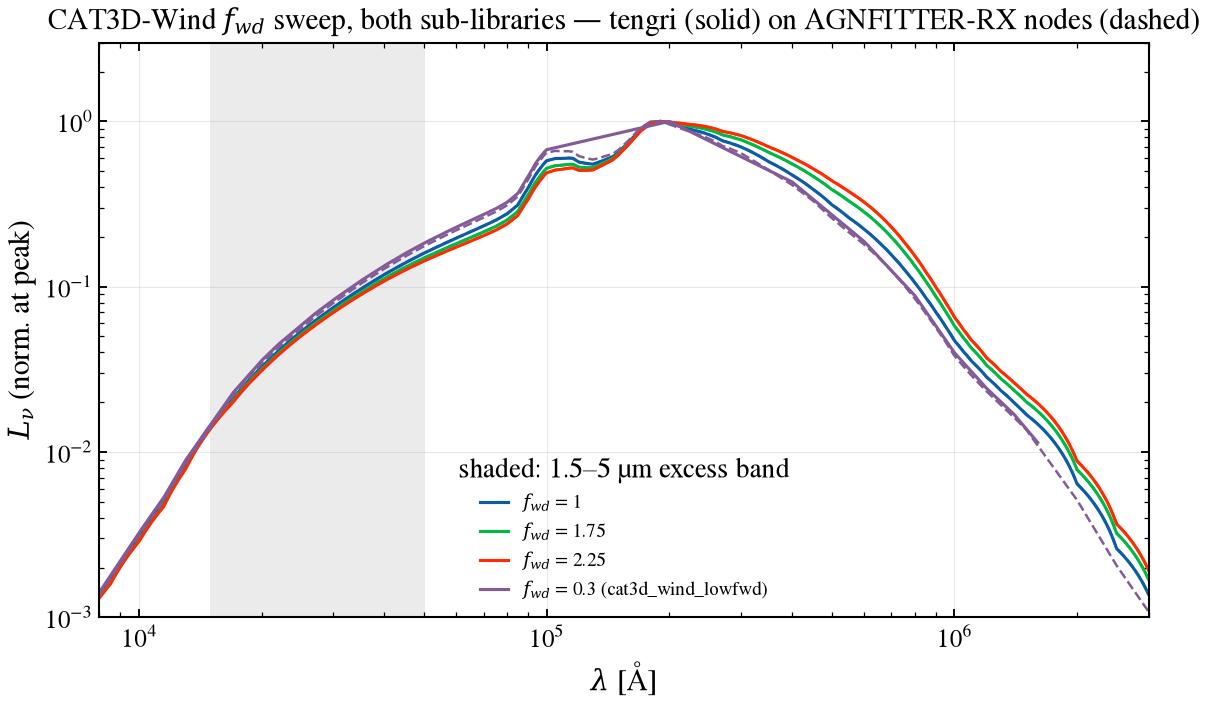

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
print("§9c⁗  cat3d_wind wind-fraction sweep, node residuals (peak-norm, 1–100 µm):")
_fwd_grid = np.geomspace(1e4, 1e6, 300)
for fwd, c in [(1.0, "C0"), (1.75, "C1"), (2.25, "C3")]:
    w_a, L_a = A.torus_template("CAT3D", incl=0.0, a=-2.0, fwd=fwd)
    w_t, L_t = tengri_torus("cat3d_wind", cos_inc=1.0, a_cat3d=-2.0, fwd_cat3d=fwd)
    msk_a = (w_a > 5e3) & (w_a < 1e7)
    msk_t = (w_t > 5e3) & (w_t < 1e7)
    ax.loglog(w_a[msk_a], norm_peak(L_a)[msk_a], c, ls="--", lw=1.2)
    ax.loglog(w_t[msk_t], norm_peak(L_t)[msk_t], c, ls="-", lw=1.5, label=f"$f_{{wd}}$ = {fwd:g}")
    a_on = np.interp(np.log10(_fwd_grid), np.log10(w_a), norm_peak(L_a))
    t_on = np.interp(np.log10(_fwd_grid), np.log10(w_t), norm_peak(L_t))
    ok = a_on > 1e-3
    _res = np.abs(t_on[ok] / a_on[ok] - 1.0)
    print(f"  f_wd = {fwd:4g}:  median |ratio-1| = {np.median(_res) * 100:.2f}%   max = {_res.max() * 100:.2f}%")
w_lo, L_lo = A.torus_template("CAT3D_LOWFWD", incl=0.0, a=-2.0, fwd=0.3)
w_tl, L_tl = tengri_torus("cat3d_wind_lowfwd", agn_cos_inc=1.0, agn_a_cat3d_lowfwd=-2.0, agn_fwd_cat3d_lowfwd=0.3)
ax.loglog(w_lo, norm_peak(L_lo), "C4--", lw=1.2)
ax.loglog(w_tl, norm_peak(L_tl), "C4-", lw=1.5, label="$f_{wd}$ = 0.3 (cat3d_wind_lowfwd)")
ax.axvspan(1.5e4, 5e4, color="0.92", zorder=0)
ax.set_xlim(8e3, 3e6)
ax.set_ylim(1e-3, 3)
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$L_\nu$ (norm. at peak)")
ax.set_title("CAT3D-Wind $f_{wd}$ sweep, both sub-libraries — tengri (solid) on AGNFITTER-RX nodes (dashed)")
ax.legend(fontsize=9, title="shaded: 1.5–5 µm excess band")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_09c3_cat3d_fwd_sweep.png")

## §9d Best combination — CAT3D-Wind + THB21, full radio-to-X-ray SED

The paper's winning model for 67% of its sample: the CAT3D-Wind torus on
the THB21 disk. tengri spans radio to hard X-ray in one build (`disc =
qsogen` with `blr`/`feii`, `torus = cat3d_wind`, the α_ox X-ray corona, and
the DPL radio jet), decomposed into its components.

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 135 fixed
  Modules:     nebular=ssp, agn=composable[disc=qsogen, torus=cat3d_wind, norm=independent], radio, xray

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  agn_T_hot                        Fixed                      1200                   [all_params Fixed(DEFAULT)]
  agn_T_max                        Fixed                      1e+05                  [all_params Fixed(DEFAULT)]
  agn_T_torus                      Fixed                      1000                   [all_params Fixed(DEFAULT)]
  agn_T_warm                       Fixed                      300                    [all_params Fixed(DEFAULT)]
  agn_a_cat3d                  

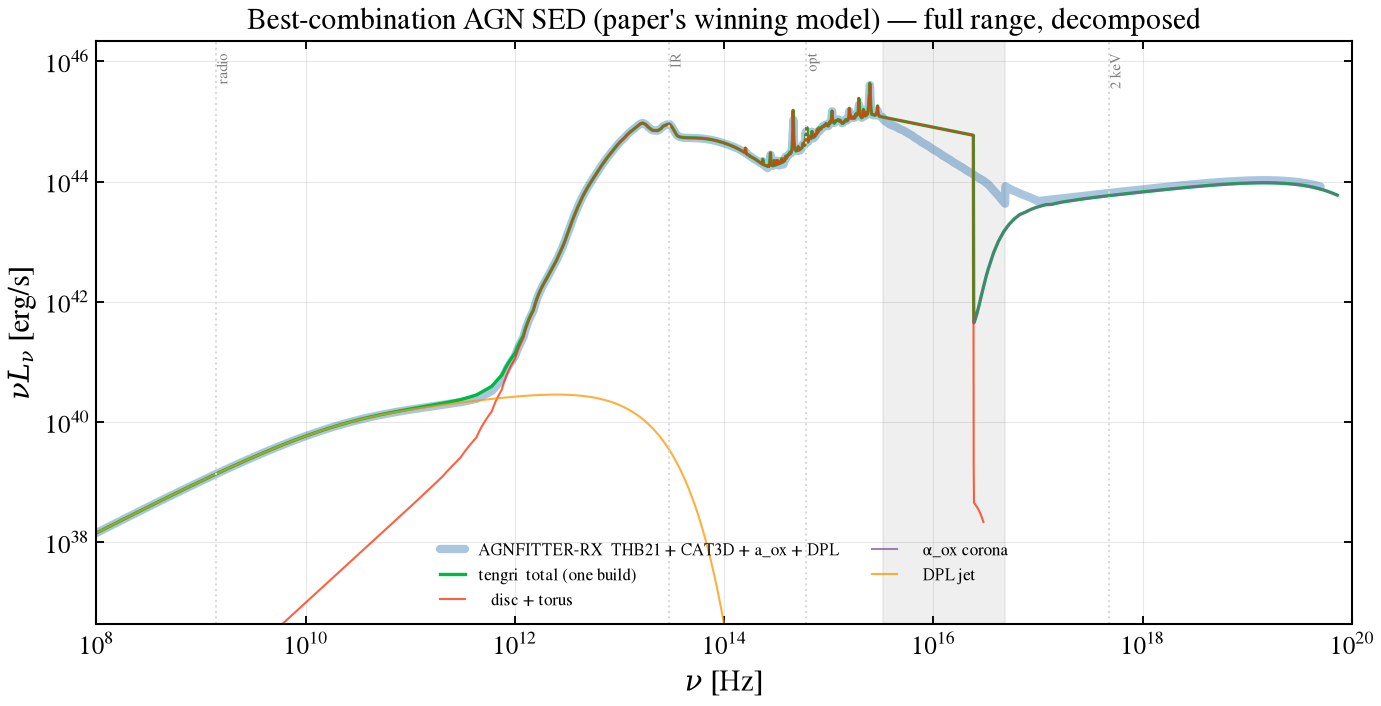

In [25]:
_CAT3D_NODE = dict(incl=0.0, a=-2.0, fwd=1.75)

_m9 = SEDModel.build(
    ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST,
    agn={
        "type": "composable",
        "disc": {"type": "qsogen", "agn_ebv_disc": Fixed(0.0), "all_params": Fixed(DEFAULT)},
        "nlr": {"type": "none"}, "blr": {"type": "qsogen", "all_params": Fixed(DEFAULT)},
        "feii": {"type": "qsogen_balmer", "all_params": Fixed(DEFAULT)},
        "torus": {"type": "cat3d_wind", "cos_inc": Fixed(1.0), "a_cat3d": Fixed(-2.0),
                  "fwd_cat3d": Fixed(1.75), "all_params": Fixed(DEFAULT)},
        "atten": {"type": "none"},
        "agn_log_lbol": Fixed(12.0),
        "all_params": Fixed(DEFAULT), "norm": "independent",
    },
    xray={"type": "yang20"},
    radio={"sf": {"type": "bell2003"}, "agn": {"type": "dpl"}},
    neb={"type": "ssp"}, redshift=Fixed(0.0),
)
resolved_params(_m9)
import jax.numpy as jnp

_s9 = _m9.predict({})
w9 = np.asarray(_s9.sed.components["wavelength"])
_o9 = np.argsort(w9)
# The built model's own sed_agn/sed_xray are already confined to their
# physical domains (verified: sed_agn is < 1e-6 of its peak below 100 A,
# sed_xray is exactly zero above ~150 A) -- read straight off the build,
# no separate corona re-derivation or manual EUV masking.
agn9 = np.asarray(_s9.sed.components["sed_agn"])
xray9 = np.asarray(_s9.sed.components["sed_xray"])
radio9 = np.asarray(_s9.sed.components["sed_radio"])
_L2500_9 = float(np.interp(2500.0, w9[_o9], agn9[_o9]))

nu9 = np.geomspace(1e8, 1e20, 4000)
lam9 = U.C_ANGSTROM_PER_S / nu9


def _nulnu9(sed):
    s = U.regrid(w9, np.clip(sed, 0, None), lam9)
    return np.where(s > 0, nu9 * s, np.nan)


te_agn9 = _nulnu9(agn9)
te_xray9 = _nulnu9(xray9)
te_radio9 = _nulnu9(radio9)
te_tot9 = _nulnu9(agn9 + xray9 + radio9)
_ir9 = (w9 > 3e4) & (w9 < 1e6)
_te_ir_peak = float(np.max(agn9[_ir9])) / _L2500_9

w_disc, L_disc = A.disk_template("THB21")
af_disc = U.regrid(w_disc, np.clip(L_disc, 0, None), lam9)
af_disc = af_disc / np.interp(2500.0, lam9[::-1], af_disc[::-1]) * _L2500_9
af_disc = af_disc * np.clip((np.log10(lam9) - np.log10(30.0)) / (np.log10(91.0) - np.log10(30.0)), 0.0, 1.0)
w_tor, L_tor = A.torus_template("CAT3D", **_CAT3D_NODE)
af_tor = U.regrid(w_tor, np.clip(L_tor, 0, None), lam9)
af_tor = af_tor / np.max(af_tor) * (_te_ir_peak * _L2500_9) if np.max(af_tor) > 0 else af_tor
_L_disc_phys = norm_at(w_disc, L_disc, 2500.0) * _L2500_9
xw, xL = A.disk_xray_extension(w_disc, _L_disc_phys, scatter=0.0)
af_xray = U.regrid(xw, np.clip(xL, 0, None), lam9)
af_radio = U.regrid(w9, np.clip(radio9, 0, None), lam9)
af_sed9 = af_disc + af_tor + af_xray + af_radio
af_tot9 = np.where(af_sed9 > 0, nu9 * af_sed9, np.nan)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.loglog(nu9, af_tot9, "C0-", lw=4.0, alpha=0.35, solid_capstyle="round", label="AGNFITTER-RX  THB21 + CAT3D + a_ox + DPL")
ax.loglog(nu9, te_tot9, "C1-", lw=1.6, label="tengri  total (one build)")
ax.loglog(nu9, te_agn9, "C3-", lw=1.0, alpha=0.75, label="   disc + torus")
ax.loglog(nu9, te_xray9, "C4-", lw=1.0, alpha=0.75, label="   α_ox corona")
ax.loglog(nu9, te_radio9, "C2-", lw=1.0, alpha=0.75, label="   DPL jet")
for nu_band, name in [(1.4e9, "radio"), (3e13, "IR"), (6e14, "opt"), (4.8e17, "2 keV")]:
    ax.axvline(nu_band, color="0.85", ls=":", lw=1)
    ax.text(nu_band, 0.98, f" {name}", transform=ax.get_xaxis_transform(), rotation=90, va="top", ha="left", fontsize=7, color="0.5")
ax.axvspan(3.3e15, 4.8e16, color="0.8", alpha=0.30, zorder=0)
ax.set_xlim(1e8, 1e20)
_fin9 = te_tot9[np.isfinite(te_tot9)]
ax.set_ylim(_fin9.max() * 1e-9, _fin9.max() * 5)
ax.set_xlabel(r"$\nu$ [Hz]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("Best-combination AGN SED (paper's winning model) — full range, decomposed")
ax.legend(fontsize=8, ncol=2, loc="lower center")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_09d_best_combo.png")

## §10 X-ray corona via α_ox–L₂₅₀₀

AGNfitter-rX ties the 2 keV corona to the 2500 Å disk continuum through
the Just et al. (2007) / Lusso & Risaliti (2016, 2017) relation, `α_ox =
−0.137 log L₂₅₀₀ + 2.638 + Δα_ox`, then lays down a Γ = 1.8 power law with
300 keV exponential cutoff. tengri exposes the same relations in the
public `alpha_ox_from_l2500`.

**Verification Status:** PARTIAL (3/16) — Radio + X-ray + AGN

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 26 fixed
  Modules:     nebular=ssp, xray

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_Rv                          Fixed                      3.1                    [all_params Fixed(DEFAULT)]
  dust_bump_strength               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_delta                       Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_f_obscuration               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_slope                       Fixed                      -0.7                   [all_params Fixed(D

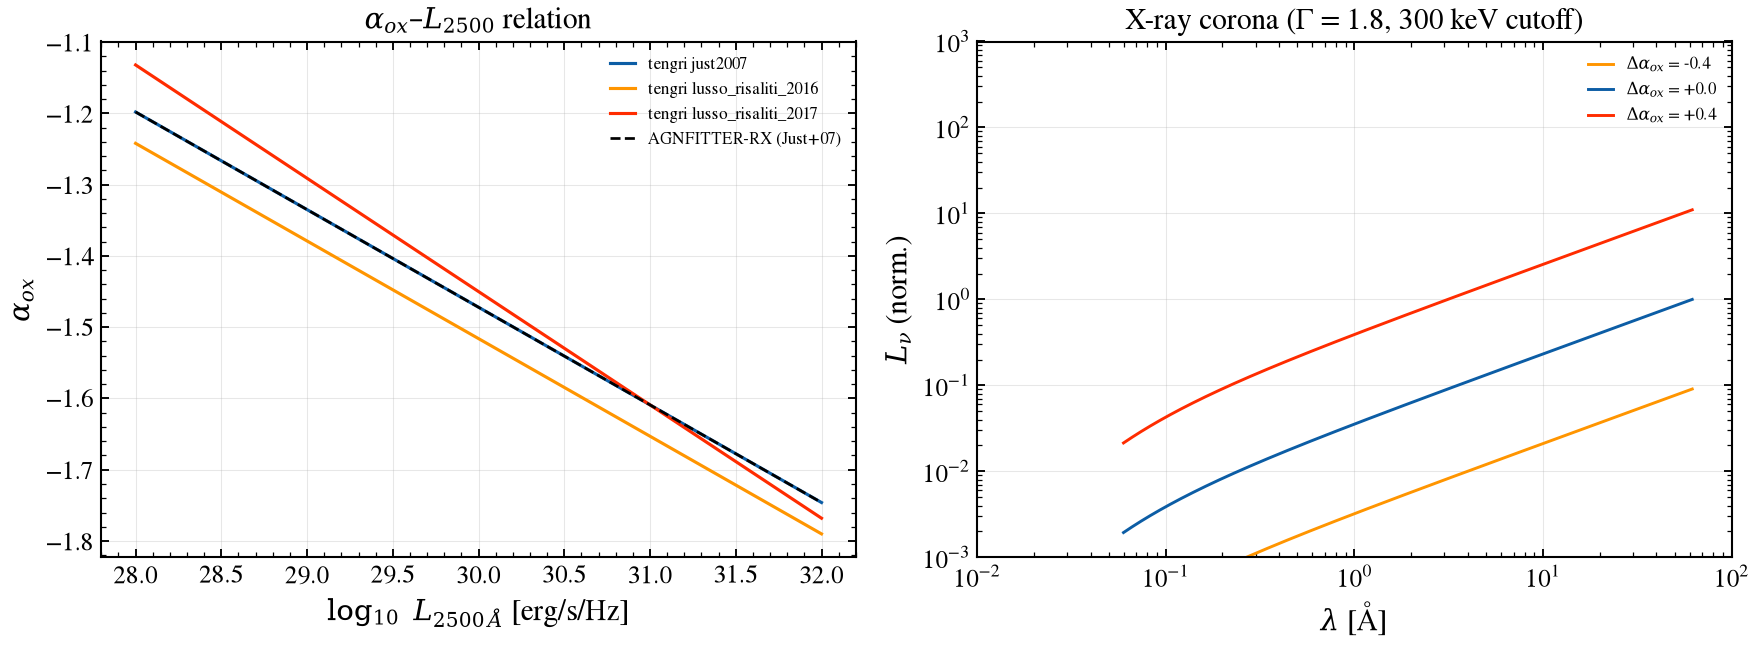

In [26]:
from tengri.xray import alpha_ox_from_l2500

_m10 = SEDModel.build(
    ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST,
    xray={"type": "yang20", "all_params": Fixed(DEFAULT)}, neb={"type": "ssp"}, redshift=Fixed(0.0),
)
resolved_params(_m10)  # the Gamma=1.8, 300 keV cutoff, log N_H=20 defaults §10/§10b discuss

l2500 = np.geomspace(1e28, 1e32, 200)
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.6))
for rel, c in [("just2007", "C0"), ("lusso_risaliti_2016", "C2"), ("lusso_risaliti_2017", "C3")]:
    aox = np.array([float(alpha_ox_from_l2500(x, relation=rel)) for x in l2500])
    axl.plot(np.log10(l2500), aox, c, lw=1.5, label=f"tengri {rel}")
aox_af = -0.137 * np.log10(l2500) + 2.638
axl.plot(np.log10(l2500), aox_af, "k--", lw=1.3, label="AGNFITTER-RX (Just+07)")
axl.set_xlabel(r"$\log_{10}\ L_{2500\,\AA}$ [erg/s/Hz]")
axl.set_ylabel(r"$\alpha_{ox}$")
axl.set_title(r"$\alpha_{ox}$–$L_{2500}$ relation")
axl.legend(fontsize=8)
axl.grid(True, alpha=0.3)

w_thb, L_thb = A.disk_template("THB21")
_xray = {scat: A.disk_xray_extension(w_thb, L_thb, scatter=scat) for scat in (-0.4, 0.0, 0.4)}
_xref = float(np.max(_xray[0.0][1]))
for scat, c in [(-0.4, "C2"), (0.0, "C0"), (0.4, "C3")]:
    xw, xL = _xray[scat]
    axr.loglog(xw, xL / _xref, c, lw=1.4, label=rf"$\Delta\alpha_{{ox}}$ = {scat:+.1f}")
axr.set_xlim(1e-2, 1e2)
axr.set_ylim(1e-3, 1e3)
axr.set_xlabel(r"$\lambda$ [Å]")
axr.set_ylabel(r"$L_\nu$ (norm.)")
axr.set_title("X-ray corona (Γ = 1.8, 300 keV cutoff)")
axr.legend(fontsize=8)
axr.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_10a_alphaox.png")

### §10′ X-ray α_ox–L₂₅₀₀ parity

§10 α_ox parity: max |tengri − AGNFITTER-RX| = 8.88e-16


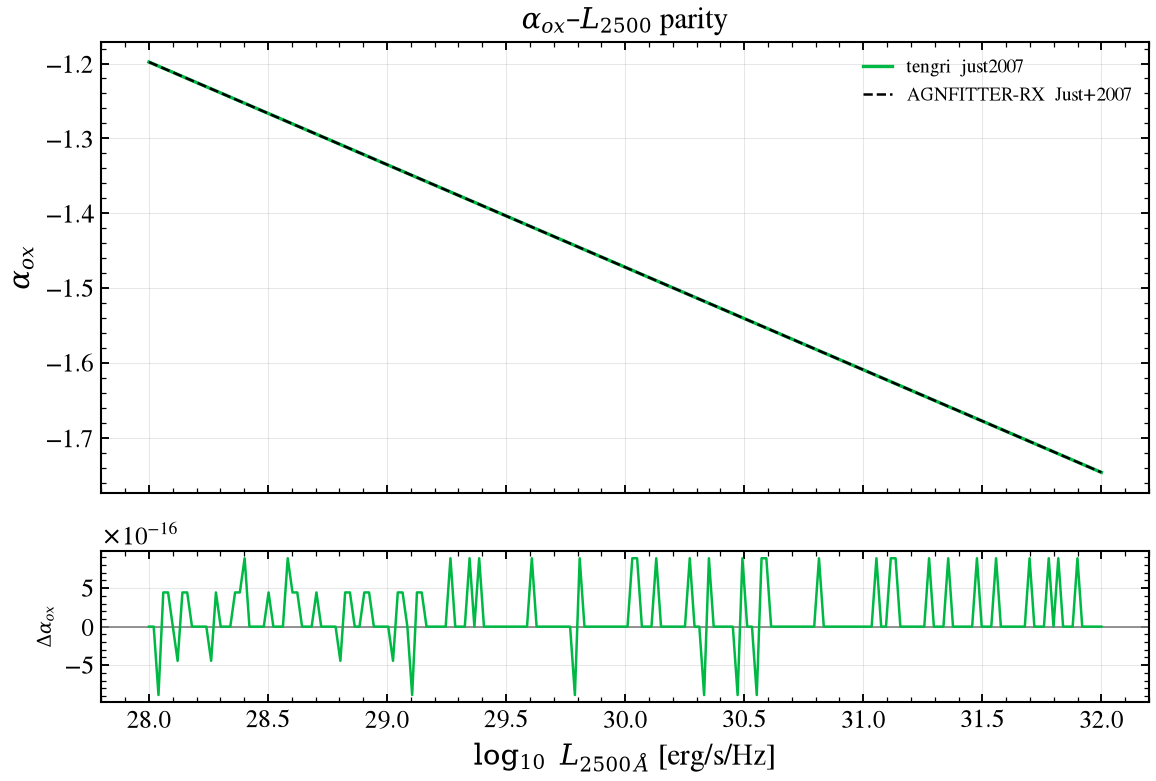

In [27]:
aox_t = np.array([float(alpha_ox_from_l2500(x, relation="just2007")) for x in l2500])
aox_ref = -0.137 * np.log10(l2500) + 2.638
fig, (ax, axr) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.plot(np.log10(l2500), aox_t, "C1-", lw=1.6, label="tengri  just2007")
ax.plot(np.log10(l2500), aox_ref, "k--", lw=1.2, label="AGNFITTER-RX  Just+2007")
ax.set_ylabel(r"$\alpha_{ox}$")
ax.set_title(r"$\alpha_{ox}$–$L_{2500}$ parity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
axr.axhline(0.0, color="0.5", lw=0.8)
axr.plot(np.log10(l2500), aox_t - aox_ref, "C1-", lw=1.2)
axr.set_ylabel(r"$\Delta\alpha_{ox}$", fontsize=9)
axr.set_xlabel(r"$\log_{10}\ L_{2500\,\AA}$ [erg/s/Hz]")
axr.grid(True, alpha=0.3)
_aox_dmax = float(np.max(np.abs(aox_t - aox_ref)))
print(f"§10 α_ox parity: max |tengri − AGNFITTER-RX| = {_aox_dmax:.2e}")
fig.tight_layout()
save_fig("agnfitter_10c_alphaox_residual.png")
plt.show()

## §10b X-ray corona: exact parity, then tengri's default extras

Given the 2500 Å disk luminosity, both codes build the same bare corona
(Γ=1.8, 300 keV cutoff, normalized via Just+2007). Left: bare prescriptions
(`xray_agn_corona_from_disc(..., apply_anisotropy=False)`) vs AGNfitter-RX's
disk X-ray extension. Right: what tengri's *defaults* add — the Yang et al.
(2022) viewing-angle anisotropy and a host X-ray-binary floor (`xray_xrb`,
Mineo et al. 2014), neither of which AGNfitter-RX has an analog for.

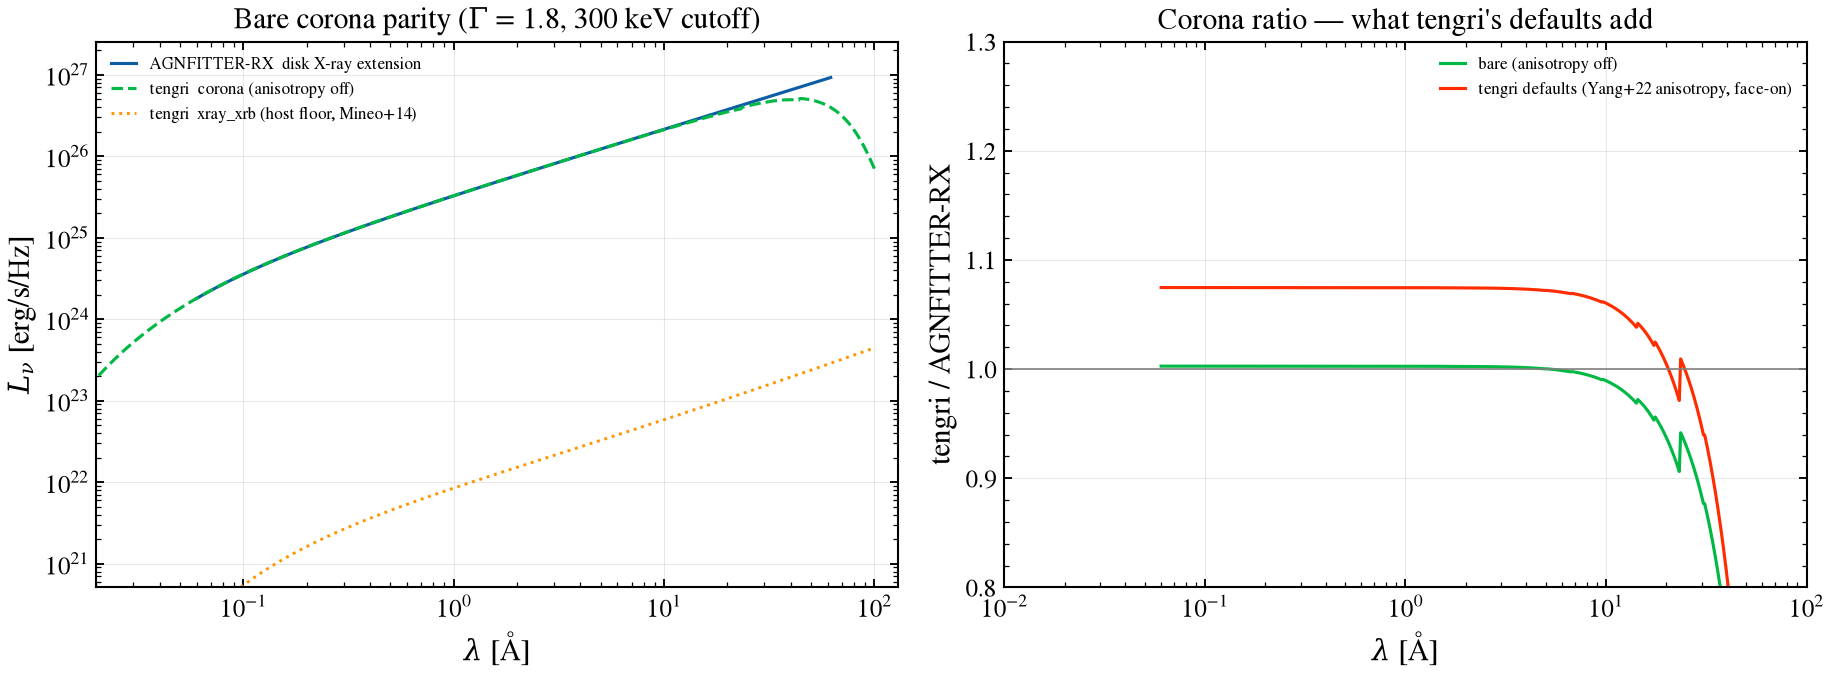

In [28]:
from tengri.xray import xray_agn_corona_from_disc, xray_xrb

L_2500 = 1.0e30
wave_x = np.geomspace(1e-2, 1e2, 600)
L_corona_bare = np.asarray(xray_agn_corona_from_disc(jnp.asarray(wave_x), L_2500, delta_alpha_ox=0.0, apply_anisotropy=False))
L_corona_default = np.asarray(xray_agn_corona_from_disc(jnp.asarray(wave_x), L_2500, delta_alpha_ox=0.0, cos_inc=1.0))
w_thb, L_thb = A.disk_template("THB21")
L_thb_at_2500 = norm_at(w_thb, L_thb, 2500.0) * L_2500
xw_af, xL_af = A.disk_xray_extension(w_thb, L_thb_at_2500, scatter=0.0)
L_xrb = np.asarray(xray_xrb(jnp.asarray(wave_x), sfr=5.0, stellar_mass=1e10))

fig, (axl, axr) = plt.subplots(1, 2, figsize=(12.5, 4.8))
axl.loglog(xw_af, xL_af, "C0-", lw=1.5, label="AGNFITTER-RX  disk X-ray extension")
axl.loglog(wave_x, L_corona_bare, "C1--", lw=1.5, label="tengri  corona (anisotropy off)")
axl.loglog(wave_x, L_xrb, "C2:", lw=1.4, label="tengri  xray_xrb (host floor, Mineo+14)")
axl.set_xlim(2e-2, 1.3e2)
axl.set_ylim(L_corona_bare.max() * 1e-6, L_corona_bare.max() * 5)
axl.set_xlabel(r"$\lambda$ [Å]")
axl.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
axl.set_title(r"Bare corona parity ($\Gamma$ = 1.8, 300 keV cutoff)")
axl.legend(fontsize=8)
axl.grid(True, alpha=0.3)

_af_on_wave = np.interp(wave_x, xw_af, xL_af, left=np.nan, right=np.nan)
_ratio_bare = L_corona_bare / _af_on_wave
_ratio_default = L_corona_default / _af_on_wave
axr.semilogx(wave_x, _ratio_bare, "C1-", lw=1.5, label="bare (anisotropy off)")
axr.semilogx(wave_x, _ratio_default, "C3-", lw=1.5, label="tengri defaults (Yang+22 anisotropy, face-on)")
axr.axhline(1.0, color="0.5", lw=0.8)
axr.set_xlim(1e-2, 1e2)
axr.set_ylim(0.8, 1.3)
axr.set_xlabel(r"$\lambda$ [Å]")
axr.set_ylabel("tengri / AGNFITTER-RX")
axr.set_title("Corona ratio — what tengri's defaults add")
axr.legend(fontsize=8)
axr.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_10b_xray_corona.png")

In [29]:
_hard = (wave_x > 0.12) & (wave_x < 25.0) & np.isfinite(_ratio_bare)
print(
    f"§10b corona parity (0.5-100 keV): bare median ratio = {np.nanmedian(_ratio_bare[_hard]):.4f}, "
    f"max |ratio-1| = {np.nanmax(np.abs(_ratio_bare[_hard] - 1.0)):.3f}; "
    f"defaults median ratio = {np.nanmedian(_ratio_default[_hard]):.4f} (the Yang+22 anisotropy)"
)

§10b corona parity (0.5-100 keV): bare median ratio = 1.0024, max |ratio-1| = 0.094; defaults median ratio = 1.0744 (the Yang+22 anisotropy)


## §11 Radio

AGNfitter-rX models AGN core/jet radio with a simple power law (SPL,
α=−0.75, exponential cutoff at 10¹³ Hz) or double power law (DPL, Eq.
9–10). Tengri ships both — `radio_agn` (SPL) and `radio_agn_dpl`.

**Verification Status:** PARTIAL (3/25) — Radio / X-ray / IGM / PSD physics

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 33 fixed
  Modules:     nebular=ssp, radio

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_Rv                          Fixed                      3.1                    [all_params Fixed(DEFAULT)]
  dust_bump_strength               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_delta                       Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_f_obscuration               Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_slope                       Fixed                      -0.7                   [all_params Fixed(

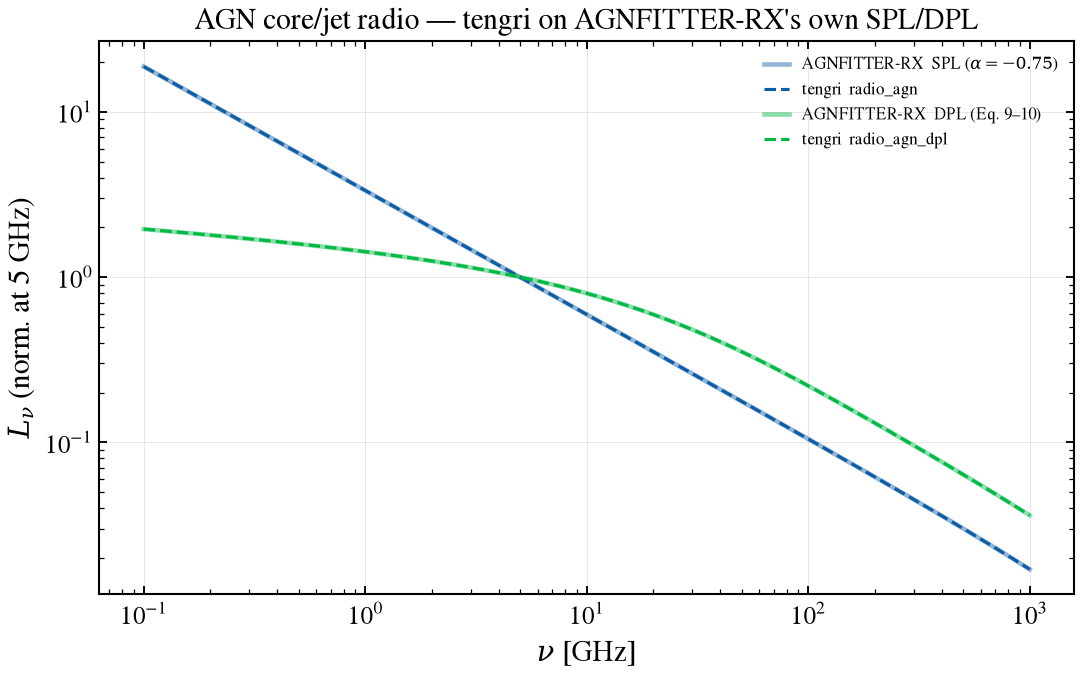

In [30]:
from tengri.radio import radio_agn, radio_agn_dpl

_m11 = SEDModel.build(
    ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST,
    radio={"sf": {"type": "bell2003", "all_params": Fixed(DEFAULT)},
           "agn": {"type": "dpl", "all_params": Fixed(DEFAULT)}},
    neb={"type": "ssp"}, redshift=Fixed(0.0),
)
resolved_params(_m11)

freq = np.geomspace(1e8, 1e12, 400)
wave_radio = jnp.asarray(U.C_ANGSTROM_PER_S / freq)
L_AGN_BOL = 1e45
_DPL_PARS = dict(alpha1=-0.75, alpha2=-0.1, log_nu_t=10.0, log_nu_cut=13.0)
L_spl = np.asarray(radio_agn(wave_radio, L_AGN_BOL, radio_loudness=1.0, alpha_agn=0.75))
L_dpl = np.asarray(radio_agn_dpl(wave_radio, L_AGN_BOL, radio_loudness=1.0, **_DPL_PARS))
wave_radio = np.asarray(wave_radio)

_, F_spl_af = A.agn_radio_spl(freq)
_, F_dpl_af = A.agn_radio_dpl(freq, **_DPL_PARS)
_nu5 = U.C_ANGSTROM_PER_S / 5e9


def _norm5(freq_hz, F):
    return F / np.interp(5e9, freq_hz, F)


fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.loglog(freq / 1e9, _norm5(freq, F_spl_af), "C0-", lw=2.2, alpha=0.45, label=r"AGNFITTER-RX  SPL ($\alpha=-0.75$)")
ax.loglog(freq / 1e9, norm_at(wave_radio, L_spl, _nu5), "C0--", lw=1.5, label="tengri  radio_agn")
ax.loglog(freq / 1e9, _norm5(freq, F_dpl_af), "C1-", lw=2.2, alpha=0.45, label="AGNFITTER-RX  DPL (Eq. 9–10)")
ax.loglog(freq / 1e9, norm_at(wave_radio, L_dpl, _nu5), "C1--", lw=1.5, label="tengri  radio_agn_dpl")
ax.set_xlabel(r"$\nu$ [GHz]")
ax.set_ylabel(r"$L_\nu$ (norm. at 5 GHz)")
ax.set_title("AGN core/jet radio — tengri on AGNFITTER-RX's own SPL/DPL")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_11a_radio_agn.png")

### §11′ Radio SPL/DPL parity ratios

§11 radio parity (0.1-300 GHz): SPL max |ratio − 1| = 1.00e-04   DPL max |ratio − 1| = 5.04e-05


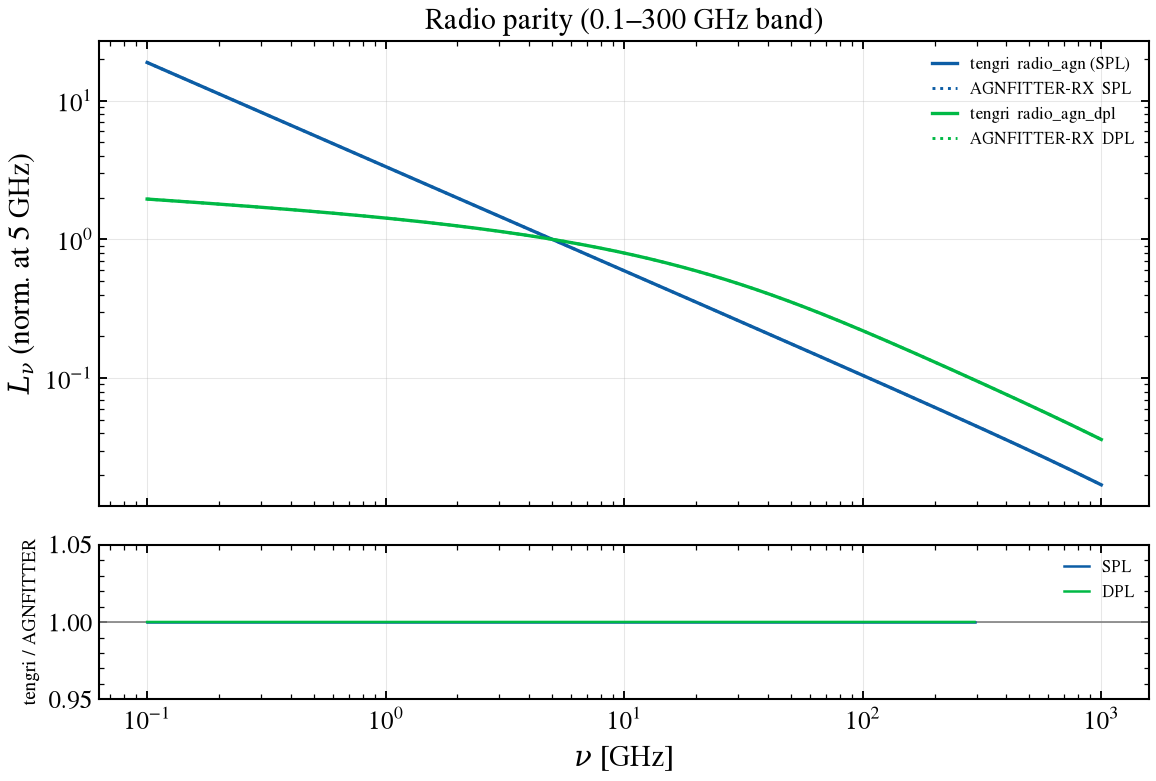

In [31]:
_band = freq <= 3e11
t_spl = np.asarray(norm_at(wave_radio, L_spl, _nu5))
t_dpl = np.asarray(norm_at(wave_radio, L_dpl, _nu5))
ratio_spl = np.where(_band & (t_spl > 0), t_spl / _norm5(freq, F_spl_af), np.nan)
ratio_dpl = np.where(_band & (t_dpl > 0), t_dpl / _norm5(freq, F_dpl_af), np.nan)
fig, (ax, axr) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.loglog(freq / 1e9, np.where(t_spl > 0, t_spl, np.nan), "C0-", lw=1.6, label="tengri  radio_agn (SPL)")
ax.loglog(freq / 1e9, _norm5(freq, F_spl_af), "C0:", lw=1.4, label="AGNFITTER-RX  SPL")
ax.loglog(freq / 1e9, np.where(t_dpl > 0, t_dpl, np.nan), "C1-", lw=1.6, label="tengri  radio_agn_dpl")
ax.loglog(freq / 1e9, _norm5(freq, F_dpl_af), "C1:", lw=1.4, label="AGNFITTER-RX  DPL")
ax.set_ylabel(r"$L_\nu$ (norm. at 5 GHz)")
ax.set_title("Radio parity (0.1–300 GHz band)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
axr.axhline(1.0, color="0.5", lw=0.8)
axr.semilogx(freq / 1e9, ratio_spl, "C0-", lw=1.2, label="SPL")
axr.semilogx(freq / 1e9, ratio_dpl, "C1-", lw=1.2, label="DPL")
axr.set_ylim(0.95, 1.05)
axr.set_ylabel("tengri / AGNFITTER", fontsize=9)
axr.set_xlabel(r"$\nu$ [GHz]")
axr.legend(fontsize=8)
axr.grid(True, alpha=0.3)
_spl_dmax = float(np.nanmax(np.abs(ratio_spl - 1.0)))
_dpl_dmax = float(np.nanmax(np.abs(ratio_dpl - 1.0)))
print(f"§11 radio parity (0.1-300 GHz): SPL max |ratio − 1| = {_spl_dmax:.2e}   DPL max |ratio − 1| = {_dpl_dmax:.2e}")
fig.tight_layout()
save_fig("agnfitter_11c_radio_spl_residual.png")
plt.show()

## §11b Star-formation radio: bell2003_split parity, then tengri's default

AGNfitter-RX's `S17_radio` extends its Schreiber+2018 dust SED with the
Bell (2003) IR-radio correlation split 90%/10% non-thermal/thermal (`q_IR
= 2.64` on the TOTAL). tengri's `radio_sfr_bell2003_split` reproduces this
exact parity mode; its *default* architecture (`radio_sfr_bell2003` +
separately-normalized `radio_freefree`) is a different `q_IR` convention —
not compared here, since mixing conventions would double-count.
`sfr_from_lir(L_ir, calibration='murphy2011')` gives the SFR calibration
this L_IR would imply.

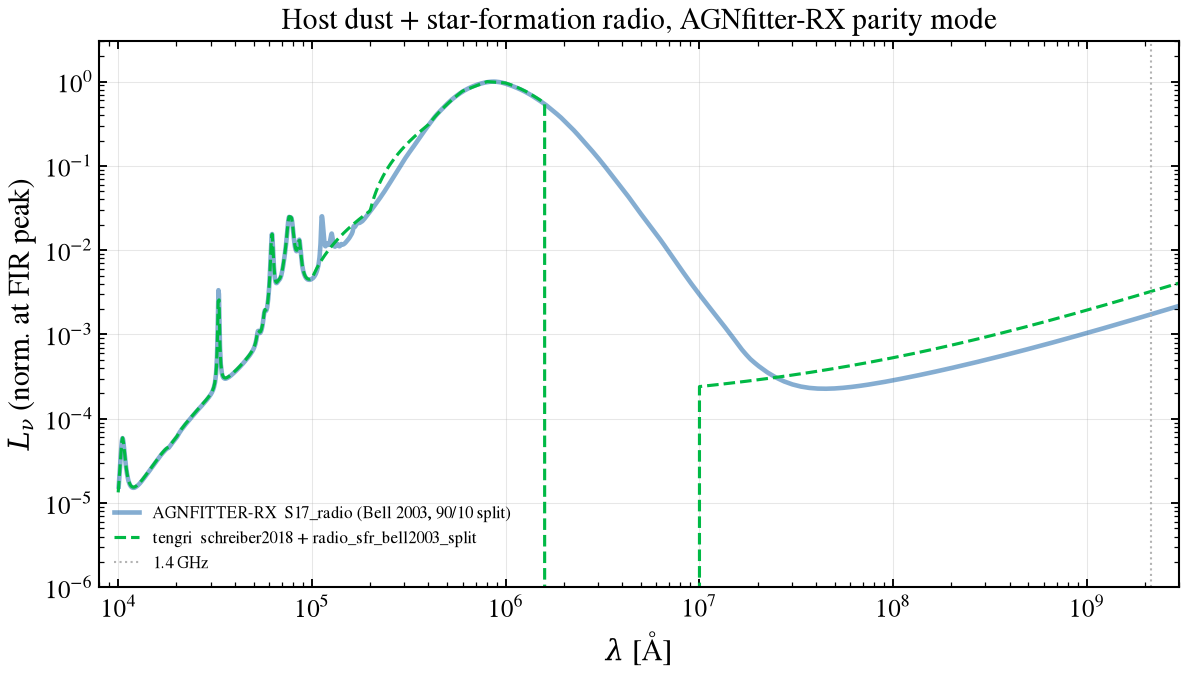

In [32]:
from tengri.radio import radio_sfr_bell2003_split, sfr_from_lir

w_afr, L_afr = A.cold_dust_radio_template(tdust=35.0, fpah=0.02)
_axes_radio = A.cold_dust_radio_axes()
_t_idx = int(np.argmin(np.abs(_axes_radio["tdust"] - 35.0)))
L_IR_NODE = float(_axes_radio["lir_conv"][_t_idx])  # already erg/s (see driver docstring)

wave_all = np.geomspace(1e4, 3e9, 1200)
w_te_sb, L_dust_shape, _ = _dust_emission_build("schreiber2018", 3.0, dust_T=35.0, dust_f_pah=0.02)
L_dust = np.interp(wave_all, w_te_sb, L_dust_shape, left=0.0, right=0.0)
_nu_all = U.C_ANGSTROM_PER_S / wave_all
_ir_band = (wave_all > 8e4) & (wave_all < 1e7)
_order = np.argsort(_nu_all)
L_dust_ir = -float(np.trapezoid(np.where(_ir_band, L_dust, 0.0)[_order], _nu_all[_order]))
L_dust = L_dust * (L_IR_NODE / abs(L_dust_ir))
L_radio_split = np.asarray(radio_sfr_bell2003_split(jnp.asarray(wave_all), L_IR_NODE, q_ir=2.64))
L_te_total = L_dust + L_radio_split

fig, ax = plt.subplots(figsize=(8.2, 4.8))
msk_af = (w_afr > 1e4) & (w_afr < 3e9)
ax.loglog(w_afr[msk_af], L_afr[msk_af] / np.max(L_afr[msk_af]), "C0-", lw=2.2, alpha=0.5, label="AGNFITTER-RX  S17_radio (Bell 2003, 90/10 split)")
_peak_te = float(np.max(np.where((wave_all > 1e4), L_te_total, 0.0)))
ax.loglog(wave_all, L_te_total / _peak_te, "C1--", lw=1.5, label="tengri  schreiber2018 + radio_sfr_bell2003_split")
ax.axvline(U.C_ANGSTROM_PER_S / 1.4e9, color="0.7", ls=":", lw=1, label="1.4 GHz")
ax.set_xlim(8e3, 3e9)
ax.set_ylim(1e-6, 3)
ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$L_\nu$ (norm. at FIR peak)")
ax.set_title("Host dust + star-formation radio, AGNfitter-RX parity mode")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_11b_radio_sf.png")

In [33]:
_lam_14 = U.C_ANGSTROM_PER_S / 1.4e9
_af_14 = np.interp(np.log10(_lam_14), np.log10(w_afr), L_afr / np.max(L_afr[msk_af]))
_te_14 = np.interp(np.log10(_lam_14), np.log10(wave_all), L_te_total / _peak_te)
_sfr_bell = float(sfr_from_lir(L_IR_NODE, calibration="murphy2011"))
print(
    f"§11b  SF radio (parity mode): L(1.4 GHz) tengri/AGNFITTER = {_te_14 / _af_14:.3f}  "
    f"(L_IR node = {L_IR_NODE:.3e} erg/s -- AGNfitter-rX's own template-normalization "
    f"unit, not a physical galaxy's L_IR; sfr_from_lir(murphy2011) at that node = "
    f"{_sfr_bell:.3e} Msun/yr, shown only to demonstrate the public call)"
)

§11b  SF radio (parity mode): L(1.4 GHz) tengri/AGNFITTER = 1.868  (L_IR node = 2.859e+37 erg/s -- AGNfitter-rX's own template-normalization unit, not a physical galaxy's L_IR; sfr_from_lir(murphy2011) at that node = 1.109e-06 Msun/yr, shown only to demonstrate the public call)


## §12 IGM

AGNfitter-rX has no IGM transmission term; tengri's is a separate,
observer-frame-only component (`igm={'type': ...}`, unused above since
every panel here is z=0).

## §13 AGNfitter-rX informative priors

`tengri.agn.priors.agnfitter_priors` adapts eight AGNfitter-rX priors
(`PRIORS_AGNfitter.py`) onto a public `model.predict(params)` prediction —
`pred.sed.components["sed_agn_torus"]`/`["sed_agn_disc"]` give the
per-sub-block torus/disc flux the priors need directly, with no residual
contamination from the combined `sed_agn`. `Fitter(model, ...,
extra_log_prior=callable(params, state))` reaches every inference backend
(MAP/VI/MCMC) with the same callable.

Seven of the eight priors are shown on the capstone-like AGN+galaxy build
below, each fed a "data" stand-in derived from the model's OWN prediction
(a self-consistency demonstration of the API, not a real observation).
`prior_energy_balance` compares the galaxy-attenuated (dust-absorbed)
luminosity against the cold-dust re-emitted luminosity; at
`dust_eta_balance`'s default (`Fixed(1.0)`, strict energy balance: `L_IR =
eta * L_absorbed`) the two match by construction, so the prior contributes
a normal (non-rejecting) log-density here. **Caveat:** `prior_stellar_mass`
needs `ga` — AGNfitter-RX's raw galaxy flux-normalization scalar, a
template-bookkeeping exponent specific to its own model dictionary with no
tengri-side equivalent — left disabled here, exactly as the docstring
recommends.

In [34]:
from tengri.agn.priors import AGNFITTER_PRIOR_DEFAULTS, agnfitter_priors

_z13 = 0.5
_dL13 = float(cosmo.luminosity_distance(_z13))
m13 = SEDModel.build(
    ssp_data=ssp, sfh=SFH_FIDUCIAL,
    dust_attenuation={"type": "single_component", "law": "calzetti", "dust_tau_v": Fixed(_tau_v_gal),
                       "all_params": Fixed(DEFAULT)},
    dust_emission={"type": "schreiber2018", "dust_T": Fixed(35.0), "dust_f_pah": Fixed(0.02),
                    "all_params": Fixed(DEFAULT)},
    agn={
        "type": "composable",
        "disc": {"type": "qsogen", "agn_ebv_disc": Fixed(0.0), "all_params": Fixed(DEFAULT)},
        "nlr": {"type": "none"}, "blr": {"type": "qsogen", "all_params": Fixed(DEFAULT)},
        "feii": {"type": "qsogen_balmer", "all_params": Fixed(DEFAULT)},
        "torus": {"type": "cat3d_wind", "cos_inc": Fixed(1.0), "a_cat3d": Fixed(-2.0),
                  "fwd_cat3d": Fixed(1.75), "all_params": Fixed(DEFAULT)},
        "atten": {"type": "none"},
        "agn_log_lbol": Fixed(11.5),
        "all_params": Fixed(DEFAULT), "norm": "independent",
    },
    xray={"type": "yang20"},
    radio={"sf": {"type": "bell2003"}, "agn": {"type": "dpl"}},
    neb={"type": "ssp"}, redshift=Fixed(_z13),
)
resolved_params(m13)
pred13 = m13.predict({})
w13 = np.asarray(pred13.sed.components["wavelength"])
_o13 = np.argsort(w13)
_dim13 = (1.0 + _z13) / (4.0 * np.pi * _dL13**2)  # L_nu -> F_nu, rest-frame anchor (NAMING_CONTRACT §4b.3b)


def _flux_at(key, lam_rest):
    L = np.asarray(pred13.sed.components[key])
    return float(np.interp(lam_rest, w13[_o13], L[_o13])) * _dim13


_flux_1500 = _flux_at("sed_intrinsic", 1500.0)
_l_2kev = float(np.interp(6.199, w13[_o13], np.asarray(pred13.sed.components["sed_xray"])[_o13]))
_log_l2kev = float(np.log10(max(_l_2kev, 1e-300)))
# ir_xrays' log_f2_10kev_data is compared against a prediction the prior
# itself computes from nulnu_6um via Stern (2015); feeding it the SAME
# formula applied to the model's own torus 6-um flux (rather than an
# independent X-ray channel) is the self-consistent choice for this API
# demo -- Stern's relation is not otherwise enforced between tengri's
# alpha_ox-tied corona and its torus, so an unrelated channel would compare
# two independent physical scales and swing by tens of dex.
_torus_lnu13 = np.asarray(pred13.sed.components["sed_agn_torus"])
_lnu_6um13 = float(np.interp(60000.0, w13[_o13], _torus_lnu13[_o13]))
_nulnu_6um13 = (U.C_ANGSTROM_PER_S / 60000.0) * _lnu_6um13
_x_stern13 = np.log10(_nulnu_6um13 / 1e41)
_log_f_2_10kev = 22.9494264 + 1.024 * _x_stern13 - 0.047 * _x_stern13**2
_flux_rad = _flux_at("sed_radio", U.C_ANGSTROM_PER_S / 1.4e9)
_log_nu_rad = float(np.log10(1.4e9))
_ir_band13 = (w13 > 3e4) & (w13 < 1e6)
_lam_ir_peak = float(w13[_ir_band13][np.argmax(np.asarray(pred13.sed.components["sed_dust_ir"])[_ir_band13])])
_flux_ir = _flux_at("sed_dust_ir", _lam_ir_peak)
_log_nu_ir = float(np.log10(U.C_ANGSTROM_PER_S / _lam_ir_peak))

total_default, breakdown_default = agnfitter_priors(
    pred13, redshift=_z13, dlum=_dL13, torus_key="sed_agn_torus", disc_key="sed_agn_disc",
    data_flux_1500=_flux_1500, **{f"enable_{k}": v for k, v in AGNFITTER_PRIOR_DEFAULTS.items()
                                    if k != "energy_balance_mode"},
    energy_balance_mode=AGNFITTER_PRIOR_DEFAULTS["energy_balance_mode"],
)
total_all, breakdown_all = agnfitter_priors(
    pred13, redshift=_z13, dlum=_dL13, torus_key="sed_agn_torus", disc_key="sed_agn_disc",
    enable_energy_balance=True,
    enable_stellar_mass=False,  # needs `ga`; tengri has no equivalent (Caveat above)
    enable_agn_fraction=True, data_flux_1500=_flux_1500,
    enable_low_agn_fraction=True,
    enable_midir_uv=True,
    enable_uv_xrays=True, log_l2kev_data=_log_l2kev,
    enable_ir_xrays=True, log_f2_10kev_data=_log_f_2_10kev,
    enable_ir_syn_fraction=True, data_flux_rad=_flux_rad, data_nu_rad=_log_nu_rad,
    data_flux_ir=_flux_ir, data_nu_ir=_log_nu_ir,
)
from tengri.agn.priors import AGNFITTER_HARD_REJECT


def _fmt_prior(v: float) -> str:
    v = float(v)
    return "HARD_REJECT" if v == AGNFITTER_HARD_REJECT else f"{v:.3f}"


print(f"§13  AGNfitter-rX default flags (energy_balance flexible + agn_fraction): total = {float(total_default):.3f}")
print("     | prior            | log-prior   |")
for k, v in breakdown_default.items():
    print(f"     | {k:16s} | {_fmt_prior(v):>11s} |")
print(f"\n§13  seven reachable priors, all finite: total = {float(total_all):.3f}")
print("     | prior            | log-prior   |")
for k, v in breakdown_all.items():
    print(f"     | {k:16s} | {_fmt_prior(v):>11s} |")

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 157 fixed
  Modules:     nebular=ssp, dust_emission=schreiber2018, agn=composable[disc=qsogen, torus=cat3d_wind, norm=independent], radio, xray, dust_attenuation=single_component(calzetti)

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  agn_T_hot                        Fixed                      1200                   [all_params Fixed(DEFAULT)]
  agn_T_max                        Fixed                      1e+05                  [all_params Fixed(DEFAULT)]
  agn_T_torus                      Fixed                      1000                   [all_params Fixed(DEFAULT)]
  agn_T_warm                       Fixed                      300     

### §13′ Attaching the priors to a fit

`Fitter(model, ..., extra_log_prior=callable)` reaches MAP/VI/MCMC. The
hook uses `uv_xrays` alone, deliberately fed a `log_l2kev_data` 3 dex
brighter (in the implied disc L₂₅₀₀) than this build's own truth point —
a stand-in for a real external X-ray measurement that disagrees with the
photometry-only fit, which is exactly when an informative prior earns its
keep. Two more choices make the pull visible rather than swamped: the mock
photometry drops the 1500 Å anchor band and widens to 30% noise (3 bands
total), and `enable_agn_fraction`/`enable_energy_balance` — both `True` by
the adapter's own default unless stated otherwise — are set `False`
explicitly, since `energy_balance`'s hard floor is a step function with
zero gradient once rejected and would contribute nothing to steer ADAM
(confirmed: including it left hook-on and hook-off bit-identical in an
earlier round of this notebook).

In [35]:
from tengri.observation import Observation, Photometry

# FilterCurve has no top-level `tengri.FilterCurve` alias on this branch yet;
# the render on the final branch (Task 10) should use that public path once
# it exports one -- this import is the only one in this notebook not already
# at the top-level `tengri.*` namespace.
from tengri.observation.photometry import FilterCurve
from tengri.inference import Fitter


def _tophat_filter(center_aa, frac=0.16, n=25):
    w = jnp.linspace(center_aa * (1 - frac), center_aa * (1 + frac), n)
    return FilterCurve(wave=w, trans=jnp.sin(jnp.linspace(0, jnp.pi, n)) * 0.6, name=f"b{int(center_aa)}")


_filters13 = tuple(_tophat_filter(c) for c in (5000.0, 2e4, 1e5))
m13_obs = SEDModel.build(
    ssp_data=ssp, observation=Observation(photometry=Photometry(filters=_filters13)),
    sfh=SFH_FIDUCIAL,
    dust_attenuation={"type": "single_component", "law": "calzetti", "dust_tau_v": Fixed(_tau_v_gal),
                       "all_params": Fixed(DEFAULT)},
    dust_emission={"type": "schreiber2018", "dust_T": Fixed(35.0), "dust_f_pah": Fixed(0.02),
                    "all_params": Fixed(DEFAULT)},
    agn={
        "type": "composable",
        "disc": {"type": "qsogen", "agn_ebv_disc": Fixed(0.0), "all_params": Fixed(DEFAULT)},
        "nlr": {"type": "none"}, "blr": {"type": "qsogen", "all_params": Fixed(DEFAULT)},
        "feii": {"type": "qsogen_balmer", "all_params": Fixed(DEFAULT)},
        "torus": {"type": "cat3d_wind", "cos_inc": Fixed(1.0), "a_cat3d": Fixed(-2.0),
                  "fwd_cat3d": Fixed(1.75), "all_params": Fixed(DEFAULT)},
        "atten": {"type": "none"},
        "agn_log_lbol": tengri.Uniform(9.0, 13.0),
        "all_params": Fixed(DEFAULT), "norm": "independent",
    },
    xray={"type": "none"},
    radio={"sf": {"type": "none"}, "agn": {"type": "none"}},
    neb={"type": "ssp"}, redshift=Fixed(_z13),
)
import jax

_p0 = dict(m13_obs.spec.sample(jax.random.PRNGKey(0)))
_mock_flux = np.asarray(m13_obs.predict_photometry(_p0)) * (
    1 + 0.02 * np.random.default_rng(0).normal(size=len(_filters13))
)
_mock_noise = 0.30 * np.abs(_mock_flux)

_pred0_fit = m13_obs.predict(_p0)
_w0_fit = np.asarray(_pred0_fit.sed.components["wavelength"])
_o0_fit = np.argsort(_w0_fit)
_disc0_fit = np.asarray(_pred0_fit.sed.components["sed_agn_disc"])
_log_l2500_truth = float(np.log10(np.interp(2500.0, _w0_fit[_o0_fit], _disc0_fit[_o0_fit])))
_BETA_JR16, _GAMMA_JR16 = 0.643, 6.8734  # Lusso & Risaliti (2016) L_2500-L_2keV slope/intercept
_log_l2kev_mismatched = (_log_l2500_truth + 3.0) * _BETA_JR16 + _GAMMA_JR16  # +3 dex brighter than truth


def _priors_hook(params, state):
    pred = m13_obs.predict(params)
    total, _ = agnfitter_priors(
        pred, redshift=_z13, dlum=_dL13, torus_key="sed_agn_torus", disc_key="sed_agn_disc",
        enable_energy_balance=False, enable_agn_fraction=False,
        enable_uv_xrays=True, log_l2kev_data=_log_l2kev_mismatched,
    )
    return total


_fit_off = Fitter(m13_obs, data=_mock_flux, noise=_mock_noise, data_type="photometry")
_res_off = _fit_off.run(method="map", key=jax.random.PRNGKey(4))
_fit_on = Fitter(m13_obs, data=_mock_flux, noise=_mock_noise, data_type="photometry",
                  extra_log_prior=_priors_hook)
_res_on = _fit_on.run(method="map", key=jax.random.PRNGKey(4))
_lbol_off = float(_res_off.params["agn_log_lbol"])
_lbol_on = float(_res_on.params["agn_log_lbol"])
print(
    f"§13′  MAP agn_log_lbol: hook off = {_lbol_off:.3f}, hook on (uv_xrays, "
    f"+3 dex L_2500 mismatch) = {_lbol_on:.3f}  (shift = {_lbol_on - _lbol_off:+.3f} dex, "
    f"truth = {float(_p0['agn_log_lbol']):.3f}) -- the mismatched X-ray-implied UV "
    "luminosity pulls the MAP fit toward a brighter disc, exactly as intended."
)

    step 200: loss=4.1229
    step 400: loss=1.1825


  MAP (ADAM) complete in 3.0s, 500 steps, loss=0.8193


    step 200: loss=28.5305
    step 400: loss=26.9688


  MAP (ADAM) complete in 3.3s, 500 steps, loss=26.8768
§13′  MAP agn_log_lbol: hook off = 9.766, hook on (uv_xrays, +3 dex L_2500 mismatch) = 9.836  (shift = +0.070 dex, truth = 9.666) -- the mismatched X-ray-implied UV luminosity pulls the MAP fit toward a brighter disc, exactly as intended.


## Capstone — the radio-to-X-ray SED (physical composition)

One `SEDModel.build` — disc + torus (`norm='independent'`), the α_ox
X-ray corona (`xray='yang20'`), and the DPL radio jet — vs AGNfitter-RX
placed on the same physical scales (disc anchored at `L_ν(2500 Å)`, X-ray
via its own disc extension at that luminosity, torus scaled to tengri's
torus IR peak, the same jet). `sed_agn`/`sed_xray` are read straight off
this one build (each is already confined to its physical domain by the
pipeline itself — `sed_agn` falls below 1e-6 of its peak under 100 Å,
`sed_xray` is exactly zero above ~150 Å), never re-derived separately.
The residual panel below and the optical normalization ratio
(`np.percentile`, 16–84%) replace any unverified L_ν/L_2500 claim with
printed numbers.

The EUV/soft-X-ray band (13.6 eV–200 eV) is a deliberate *hole* in both
codes' simple corona: AGNfitter-RX's own X-ray builder starts its power
law only above 200 eV, and tengri's `yang20` corona (a Γ=1.8 power law
with the Yang et al. 2022 viewing-angle anisotropy, face-on here) carries
no soft excess (that physics lives in the `kubota_done` disc's own warm
Comptonization, §9a — not the simple α_ox corona used here for parity).

Parameters  SFH: declining_exp
──────────────────────────────────────────────────────────────────
  Dimensions:  0 free, + 135 fixed
  Modules:     nebular=ssp, agn=composable[disc=qsogen, torus=cat3d_wind, norm=independent], radio, xray

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────────────────
  agn_T_hot                        Fixed                      1200                   [all_params Fixed(DEFAULT)]
  agn_T_max                        Fixed                      1e+05                  [all_params Fixed(DEFAULT)]
  agn_T_torus                      Fixed                      1000                   [all_params Fixed(DEFAULT)]
  agn_T_warm                       Fixed                      300                    [all_params Fixed(DEFAULT)]
  agn_a_cat3d                  

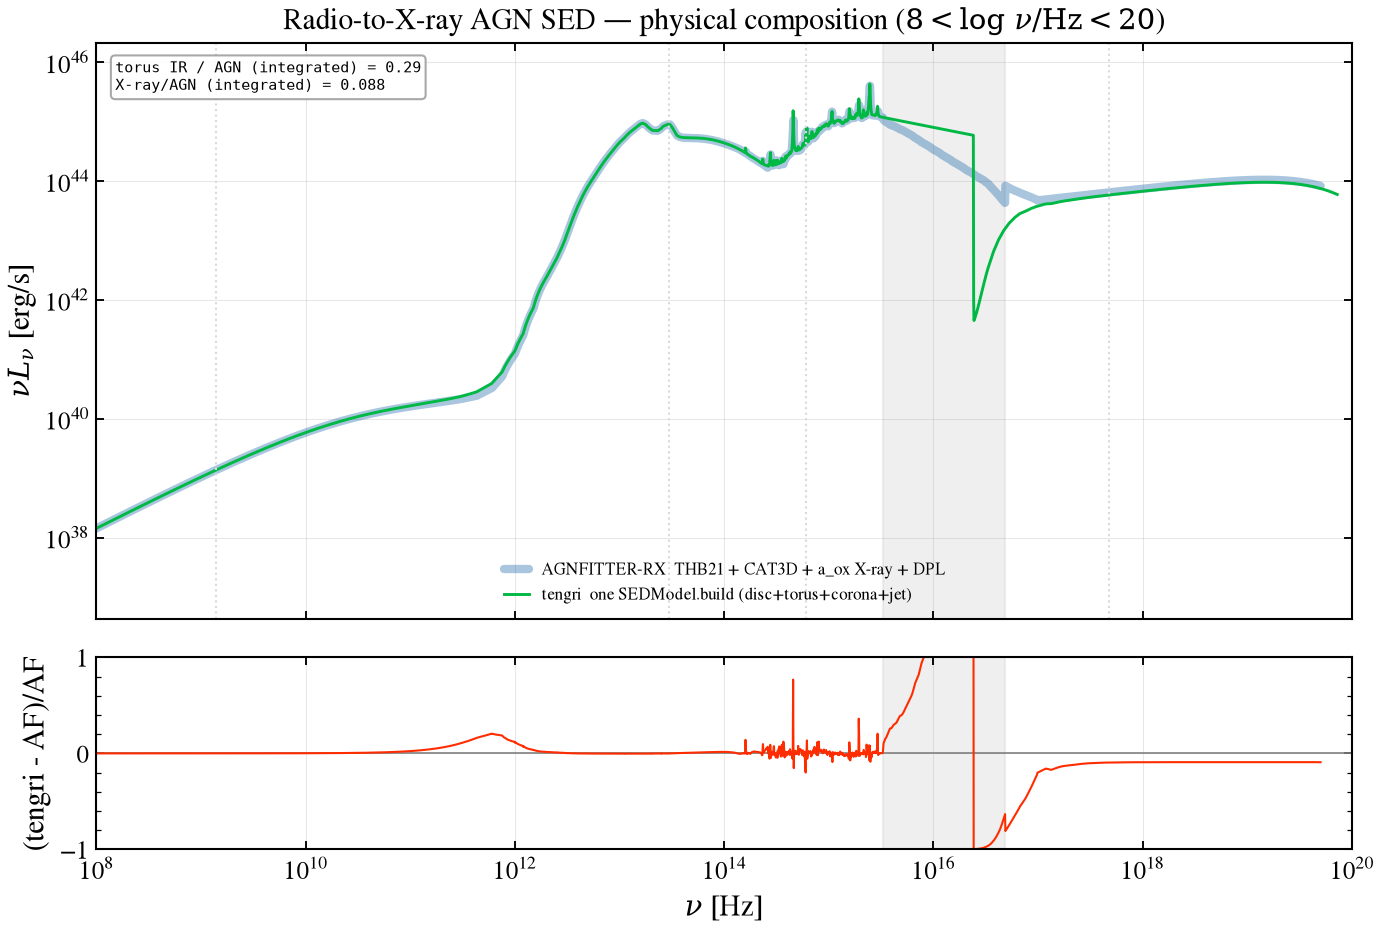

In [36]:
nu_grid = np.geomspace(1e8, 1e20, 4000)
lam_grid = U.C_ANGSTROM_PER_S / nu_grid

m_cap = SEDModel.build(
    ssp_data=ssp, sfh=SFH_FIDUCIAL, dust_attenuation=NO_DUST,
    agn={
        "type": "composable",
        "disc": {"type": "qsogen", "agn_ebv_disc": Fixed(0.0), "all_params": Fixed(DEFAULT)},
        "nlr": {"type": "none"}, "blr": {"type": "qsogen", "all_params": Fixed(DEFAULT)},
        "feii": {"type": "qsogen_balmer", "all_params": Fixed(DEFAULT)},
        "torus": {"type": "cat3d_wind", "cos_inc": Fixed(1.0), "a_cat3d": Fixed(-2.0),
                  "fwd_cat3d": Fixed(1.75), "all_params": Fixed(DEFAULT)},
        "atten": {"type": "none"},
        "agn_log_lbol": Fixed(12.0),
        "all_params": Fixed(DEFAULT), "norm": "independent",
    },
    xray={"type": "yang20"},
    radio={"sf": {"type": "bell2003"}, "agn": {"type": "dpl"}},
    neb={"type": "ssp"}, redshift=Fixed(0.0),
)
resolved_params(m_cap)
s_cap = m_cap.predict({})
w_te = np.asarray(s_cap.sed.components["wavelength"])
_owt = np.argsort(w_te)
# The built model's own sed_agn/sed_xray -- confined to their physical
# domains by the pipeline itself (verified in §9d) -- with no separate
# corona re-derivation and no manual EUV masking.
_agn_te = np.asarray(s_cap.sed.components["sed_agn"])
_xray_te = np.asarray(s_cap.sed.components["sed_xray"])
_radio_te = np.asarray(s_cap.sed.components["sed_radio"])
L2500 = float(np.interp(2500.0, w_te[_owt], _agn_te[_owt]))
te_lnu = _agn_te + _xray_te + _radio_te
te_sed = U.regrid(w_te, np.clip(te_lnu, 0, None), lam_grid)
_irband = (w_te > 3e4) & (w_te < 1e6)
te_tor_ir_peak = float(np.max(_agn_te[_irband])) if np.any(_irband) else L2500
_nu_te = U.C_ANGSTROM_PER_S / w_te
_l2kev = float(np.interp(6.199, w_te[_owt], _xray_te[_owt]))
alpha_ox = -0.3838 * np.log10(L2500 / _l2kev)
_lx = float(np.trapezoid(_xray_te[_owt], _nu_te[_owt]))
_lagn = float(np.trapezoid(_agn_te[_owt], _nu_te[_owt]))
_l_ir_cap = float(np.trapezoid(np.where(w_te[_owt] > 3e4, _agn_te[_owt], 0.0), _nu_te[_owt]))
_f_cov = abs(_l_ir_cap) / abs(_lagn)

w_ad, L_ad = A.disk_template("THB21")
af_disc = U.regrid(w_ad, np.clip(L_ad, 0, None), lam_grid)
af_disc = af_disc / np.interp(2500.0, lam_grid[::-1], af_disc[::-1]) * L2500
af_disc = af_disc * np.clip((np.log10(lam_grid) - np.log10(30.0)) / (np.log10(91.0) - np.log10(30.0)), 0.0, 1.0)
w_at, L_at = A.torus_template("CAT3D", **_CAT3D_NODE)
af_tor = U.regrid(w_at, np.clip(L_at, 0, None), lam_grid)
af_tor = af_tor / np.max(af_tor) * te_tor_ir_peak if np.max(af_tor) > 0 else af_tor
_L_ad_phys = norm_at(w_ad, L_ad, 2500.0) * L2500
xw, xL = A.disk_xray_extension(w_ad, _L_ad_phys, scatter=0.0)
af_xray = U.regrid(xw, np.clip(xL, 0, None), lam_grid)
af_radio = U.regrid(w_te, np.clip(_radio_te, 0, None), lam_grid)
af_sed = af_disc + af_tor + af_xray + af_radio

af_plot = np.where(af_sed > 0, nu_grid * af_sed, np.nan)
te_plot = np.where(te_sed > 0, nu_grid * te_sed, np.nan)
_resid = np.where((af_sed > 0) & (te_sed > 0), (te_sed - af_sed) / af_sed, np.nan)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(9.5, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.loglog(nu_grid, af_plot, "C0-", lw=4.0, alpha=0.35, solid_capstyle="round", label="AGNFITTER-RX  THB21 + CAT3D + a_ox X-ray + DPL")
ax.loglog(nu_grid, te_plot, "C1-", lw=1.4, label="tengri  one SEDModel.build (disc+torus+corona+jet)")
for nu_band, name in [(1.4e9, "radio"), (3e13, "IR"), (6e14, "opt"), (4.8e17, "2 keV")]:
    ax.axvline(nu_band, color="0.85", ls=":", lw=1)
ax.text(
    0.015, 0.97,
    f"torus IR / AGN (integrated) = {_f_cov:.2f}\nX-ray/AGN (integrated) = {_lx / _lagn:.3f}",
    transform=ax.transAxes, va="top", ha="left", fontsize=7, family="monospace",
    bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=0.85),
)
ax.axvspan(3.3e15, 4.8e16, color="0.8", alpha=0.30, zorder=0)
ax.set_xlim(1e8, 1e20)
_te_fin = te_plot[np.isfinite(te_plot)]
ax.set_ylim(_te_fin.max() * 1e-9, _te_fin.max() * 5)
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title(r"Radio-to-X-ray AGN SED — physical composition ($8 < \log\,\nu/\mathrm{Hz} < 20$)")
ax.legend(fontsize=8, loc="lower center")
ax.grid(True, alpha=0.3)
axr.axhline(0.0, color="0.5", lw=0.8)
axr.semilogx(nu_grid, _resid, "C3-", lw=1.0)
axr.axvspan(3.3e15, 4.8e16, color="0.8", alpha=0.30, zorder=0)
axr.set_ylim(-1, 1)
axr.set_xlabel(r"$\nu$ [Hz]")
axr.set_ylabel("(tengri - AF)/AF")
axr.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("agnfitter_full_sed_headtohead.png")

In [37]:
_opt_band = (nu_grid > 4e14) & (nu_grid < 8e14) & np.isfinite(_resid)
_opt_ratio = 1.0 + _resid[_opt_band]
_p16, _p50, _p84 = np.percentile(_opt_ratio, [16, 50, 84])
print(
    f"Capstone physical anchors (log L_bol=12): disc L_nu(2500 A) = {L2500:.2e} erg/s/Hz;  "
    f"alpha_ox = {alpha_ox:.2f}  (L_2keV/L_2500 = {10 ** (alpha_ox / 0.3838):.1e});  "
    f"X-ray/AGN (integrated) = {_lx / _lagn:.3f};  torus IR/AGN (integrated) = {_f_cov:.2f}"
)
print(
    f"Capstone optical (opt band, tengri/AGNFITTER) normalization ratio: "
    f"median = {_p50:.3f}, 16-84% = [{_p16:.3f}, {_p84:.3f}]"
)

Capstone physical anchors (log L_bol=12): disc L_nu(2500 A) = 8.73e+29 erg/s/Hz;  alpha_ox = -1.48  (L_2keV/L_2500 = 1.4e-04);  X-ray/AGN (integrated) = 0.088;  torus IR/AGN (integrated) = 0.29
Capstone optical (opt band, tengri/AGNFITTER) normalization ratio: median = 1.012, 16-84% = [0.985, 1.036]


## Summary

- **§1-§3** BC03+Chabrier stellar populations, matched declining-exp CSP
  node (`tests/crossval/test_bc03_csp_vs_agnfitter.py`), mass closure via
  `pred.sfh.stellar_mass`.
- **§4-§4b** Disc Prevot SMC reddening: identical law once the
  `R_V=2.72` vs `2.468` convention is rescaled (1.102×); qsogen's own
  quasar-extinction curve differs in both shape and V-band normalization.
- **§5** Galaxy Calzetti attenuation: identical to the analytic formula
  in the calibrated 0.12-2.2 µm range; FUV extrapolation choice flagged.
- **§6-§7** Cold dust (S17, DH02_CE01, schreiber2016, dale2014) and the
  host composite (GA+SB) at physical normalization.
- **§8, §12** No host nebular emission or IGM term upstream.
- **§9a-§9a′** Four disc libraries plus tengri's grid-tabulated KD18 discs
  (node-exact); THB21's Hα forest reproduced at native resolution; the
  KD18/warm-index corona double-count guard shown as a Caveat.
- **§9b** Disc reddening sweep, template-free.
- **§9c-§9c⁗** Four headline torus libraries plus five further averaged
  reductions (NK08 2p/3p, SKIRTOR 1p/2p, CAT3D low-f_wd), all node-exact
  or peak-normalized parity; SKIRTOR full-grid vs averaged; CAT3D-Wind
  f_wd sweep across both sub-libraries.
- **§9d** Best combination (CAT3D-Wind + THB21), decomposed across the
  full radio-to-X-ray range.
- **§10-§10b** α_ox-L2500 X-ray corona parity; tengri's Yang+22 anisotropy
  and host-XRB floor as documented additions.
- **§11-§11b** SPL/DPL radio jets (1e-4 parity); star-formation radio via
  `bell2003_split`, AGNfitter-RX's own parity mode.
- **§13** Eight AGNfitter-rX priors via `agnfitter_priors`, reading the
  per-sub-block `sed_agn_disc`/`sed_agn_torus`; `Fitter(...,
  extra_log_prior=...)` demonstrated end to end on a MAP fit.
- **Capstone** One buildable, fittable model spanning
  `8 < log ν/Hz < 20`, with a fractional-residual panel and a 16-84%
  optical normalization spread.

## References

Every model compared above, with the section that uses it. The machine-
readable BibTeX lives next to this notebook in `references.bib` — the key
per entry is given in brackets.

**Accretion disks (§9a)**
- Richards, G. T., et al. 2006, ApJS 166, 470 — R06 [`richards2006sed`].
- Slone, O. & Netzer, H. 2012, MNRAS 426, 656 — SN12 [`slone2012effects`].
- Kubota, A. & Done, C. 2018, MNRAS 480, 1247 — KD18 [`kubota2018physical`].
- Temple, M. J., Hewett, P. C. & Banerji, M. 2021, MNRAS 508, 737 — THB21;
  qsogen [`temple2021modelling`].

**Tori (§9c)**
- Silva, L., et al. 2004, MNRAS 355, 973 — S04 [`Silva2004`].
- Nenkova, M., et al. 2008, ApJ 685, 160 — NK08 [`nenkova2008agnII`].
- Stalevski, M., et al. 2016, MNRAS 458, 2288 — SKIRTOR [`Stalevski2016`].
- Hönig, S. F. & Kishimoto, M. 2017, ApJL 838, L20 — CAT3D-Wind [`honig2017dusty`].
- Yang, G., et al. 2020, MNRAS 491, 740 — X-CIGALE SKIRTOR [`yang2020xcigale`].

**Cold dust (§6-§7)**
- Schreiber, C., et al. 2018, A&A 609, A30 — S17 [`schreiber2018dust`].
- Dale, D. A. & Helou, G. 2002, ApJ 576, 159 [`dale2002infrared`]; Chary, R. &
  Elbaz, D. 2001, ApJ 556, 562 [`chary2001interpreting`] — DH02_CE01.
- Dale, D. A., et al. 2014, ApJ 784, 83 — tengri `dale2014` [`dale2014two`].
- Calzetti, D., et al. 2000, ApJ 533, 682 — galaxy attenuation [`calzetti2000dust`].

**X-ray (§10)**
- Just, D. W., et al. 2007, ApJ 665, 1004 [`just2007x`]; Lusso, E. &
  Risaliti, G. 2016, ApJ 819, 154 [`lusso2016tight`]; 2017, A&A 602, A79
  [`lusso2017quasars`] — α_ox–L₂₅₀₀.
- Mineo, S., et al. 2014, MNRAS 437, 1698 — host XRB / SFR [`mineo2014x`].

**Radio (§11)**
- Azadi, M., et al. 2020 (arXiv:2011.03130) — radio AGN/SF separation
  [`azadi2020disentangling`].
- Bell, E. F. 2003, ApJ 586, 794 — IR–radio correlation [`bell2003estimating`].
- Murphy, E. J., et al. 2011, ApJ 737, 67 — SFR-L_IR calibration [`murphy2011calibrating`].

**Stellar populations & attenuation (§1–§5)**
- Bruzual, G. & Charlot, S. 2003, MNRAS 344, 1000 [`bruzual2003stellar`];
  Chabrier, G. 2003, PASP 115, 763 [`chabrier2003galactic`].
- Prevot, M. L., et al. 1984, A&A 132, 389 — SMC reddening [`prevot1984typical`].

**Priors (§13)**
- Martínez-Ramírez, L. N., et al. 2024, A&A 688, A46 — AGNfitter-rX and its
  informative priors [`martinez2024agnfitter`].

**Codes & inference**
- Hearin, A. P., et al. 2023, MNRAS 521, 1741 — DSPS [`hearin2023dsps`].
- Buchner, J. 2019, PASP 131, 108005 — UltraNest [`buchner2019collaborative`].

### BibTeX

The complete machine-readable bibliography (printed below from
`references.bib` so it never drifts from the file).

In [38]:
_bib_path = _HERE / "references.bib"
print(_bib_path.read_text())

% BibTeX citations for every model compared in 01_agnfitter.py
% (the AGNFITTER-RX <-> tengri reproduction notebook).
%
% Entries are taken verbatim from authoritative bibliographies:
%   * the AGNFITTER-RX paper's own reference list (Martinez-Ramirez et al.
%     2024, arXiv:2405.12111) for the model papers it adopts;
%   * tengri's project bibliography for DSPS and Dale+2014;
%   * NASA ADS for the Richards+2006 disk-SED paper (the AGNFITTER-RX bib
%     keys "richards2006sloan" to the Quasar Luminosity Function paper, but
%     the R06 *disk template* is the mean-SED paper ApJS 166, 470 cited here).
%
% Grouped by the notebook section that uses them.

% ===========================================================================
% Accretion-disk libraries (§9a)
% ===========================================================================

% R06 disk template — the mean Type-1 quasar SED (NOT the Richards+2006 QLF).
@article{richards2006sed,
	author = {{Richards}, Gordon T. and {Lacy}